# TTA-UC現象のGKSL-Lindblad量子ダイナミクス：包括的比較

このノートブックでは、TTA-UC（Triplet-Triplet Annihilation Upconversion）現象の
GKSL-Lindblad量子ダイナミクスシミュレーションを複数のシナリオで実行し、結果を比較します。

## シナリオ一覧

| シナリオ | 手法 | ボソン | シミュレーション方式 | シミュレータ |
|----------|------|--------|---------------------|------------|
| 1 | 古典ODE (RK45) | なし | 密度行列ODE | ClassicalGKSLSimulator |
| 2 | 古典ODE (BDF) | あり | 密度行列ODE | ClassicalGKSLBosonSimulator |
| 3 | Qubit Stinespring+Trotter | なし | **密度行列（Statevector）** | QubitGKSLSimulator |
| 3b | Qubit Stinespring+Trotter | なし | **ショットベース** | QubitGKSLShotSimulator |
| 3c | Qubit Stinespring+Trotter | なし | **ショットベース+ノイズ** | QubitGKSLNoisyShotSimulator |
| 4 | Qubit Stinespring+Trotter | あり | 密度行列（Statevector） | QubitGKSLBosonSimulator |
| 5 | Qudit Stinespring+Trotter | なし | **密度行列（Statevector）** | QuditGKSLSimulator |
| 5b | Qudit Stinespring+Trotter | なし | **ショットベース** | QuditGKSLShotSimulator |
| 5c | Qudit Stinespring+Trotter | なし | **ショットベース+ノイズ** | QuditGKSLNoisyShotSimulator |
| 6 | Qudit Stinespring+Trotter | あり | 密度行列（Statevector） | QuditGKSLBosonSimulator |

## GKSL-Lindblad方程式

$$\frac{d\hat{\rho}}{dt} = -\frac{i}{\hbar}[\hat{H}, \hat{\rho}] + \sum_\alpha \left( \hat{L}_\alpha \hat{\rho} \hat{L}_\alpha^\dagger - \frac{1}{2}\{\hat{L}_\alpha^\dagger \hat{L}_\alpha, \hat{\rho}\}\right)$$

## 1. 共通パラメータの設定

In [1]:
import sys
import os
import numpy as np

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from gksl_physical_parameters import GKSLPhysicalParameters

# Non-boson parameters (4 molecules, d=3, dim=81)
params = GKSLPhysicalParameters(
    E_T=1.5,    # Triplet energy (eV)
    E_S=3.0,    # Singlet energy (eV)
    V=0.1,      # Transfer coupling (eV)
    gamma_TTA=0.05,   # TTA rate
    Gamma_fl=0.01,    # Fluorescence rate
    Gamma_ph=1e-6,    # Phosphorescence rate
    k_IC=0.005,       # Internal conversion rate
    k_ISC_ST=0.003,   # Intersystem crossing S->T
    k_ISC_TS=1e-5,    # Intersystem crossing T->S
)

# Boson parameters (2 molecules for tractable computation)
params_boson = GKSLPhysicalParameters(
    N_molecules=2, with_boson=True, n_max=1,
    omega_ph=0.15, g_eph=0.02,
)

# Simulation settings
t_max = 100.0
n_steps = 100

# For quantum simulators (Stinespring+Trotter),
# more steps are needed for accuracy but increase computation time.
# Adjust n_steps_quantum as needed.
n_steps_quantum = 100

print(f'Hilbert space dim (non-boson): {params.get_hilbert_space_dim()}')
print(f'Hilbert space dim (boson, N=2, n_max=1): {params_boson.get_hilbert_space_dim()}')
print(f'Validation: {params.validate()}')

Hilbert space dim (non-boson): 81
Hilbert space dim (boson, N=2, n_max=1): 36
Validation: []


## 2. シナリオ1: 古典GKSL（ボソン無し）

scipy.integrate.solve_ivp (RK45) による直接密度行列ODE積分。
81×81次元の密度行列を直接積分します。

Elapsed time: 22.14s
Final populations: N_S0=3.2762, N_T1=0.4184, N_S1=0.3054
Trace conservation: max|Tr-1| = 5.33e-15


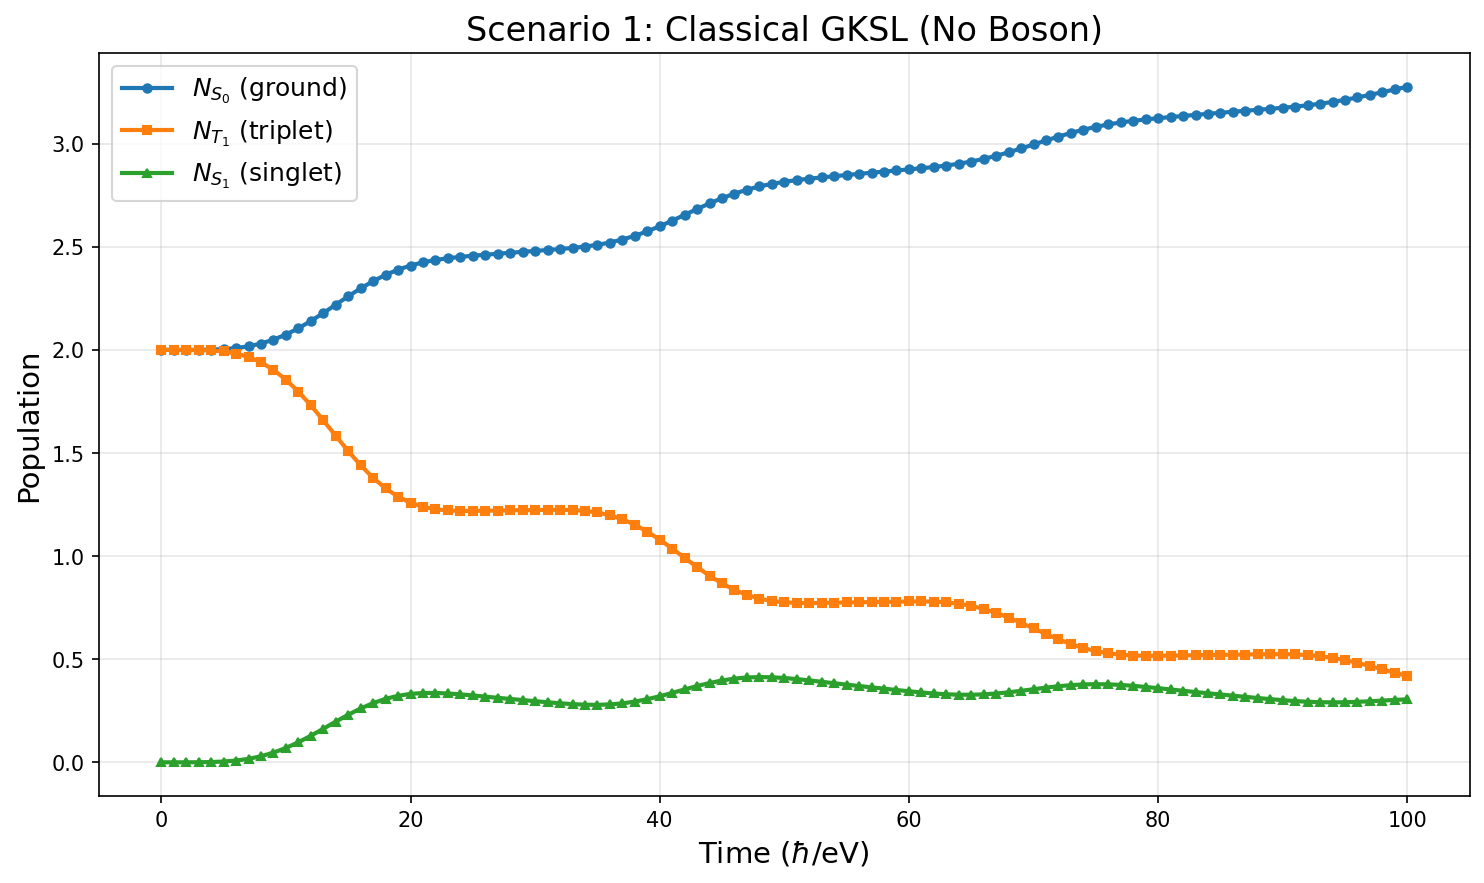

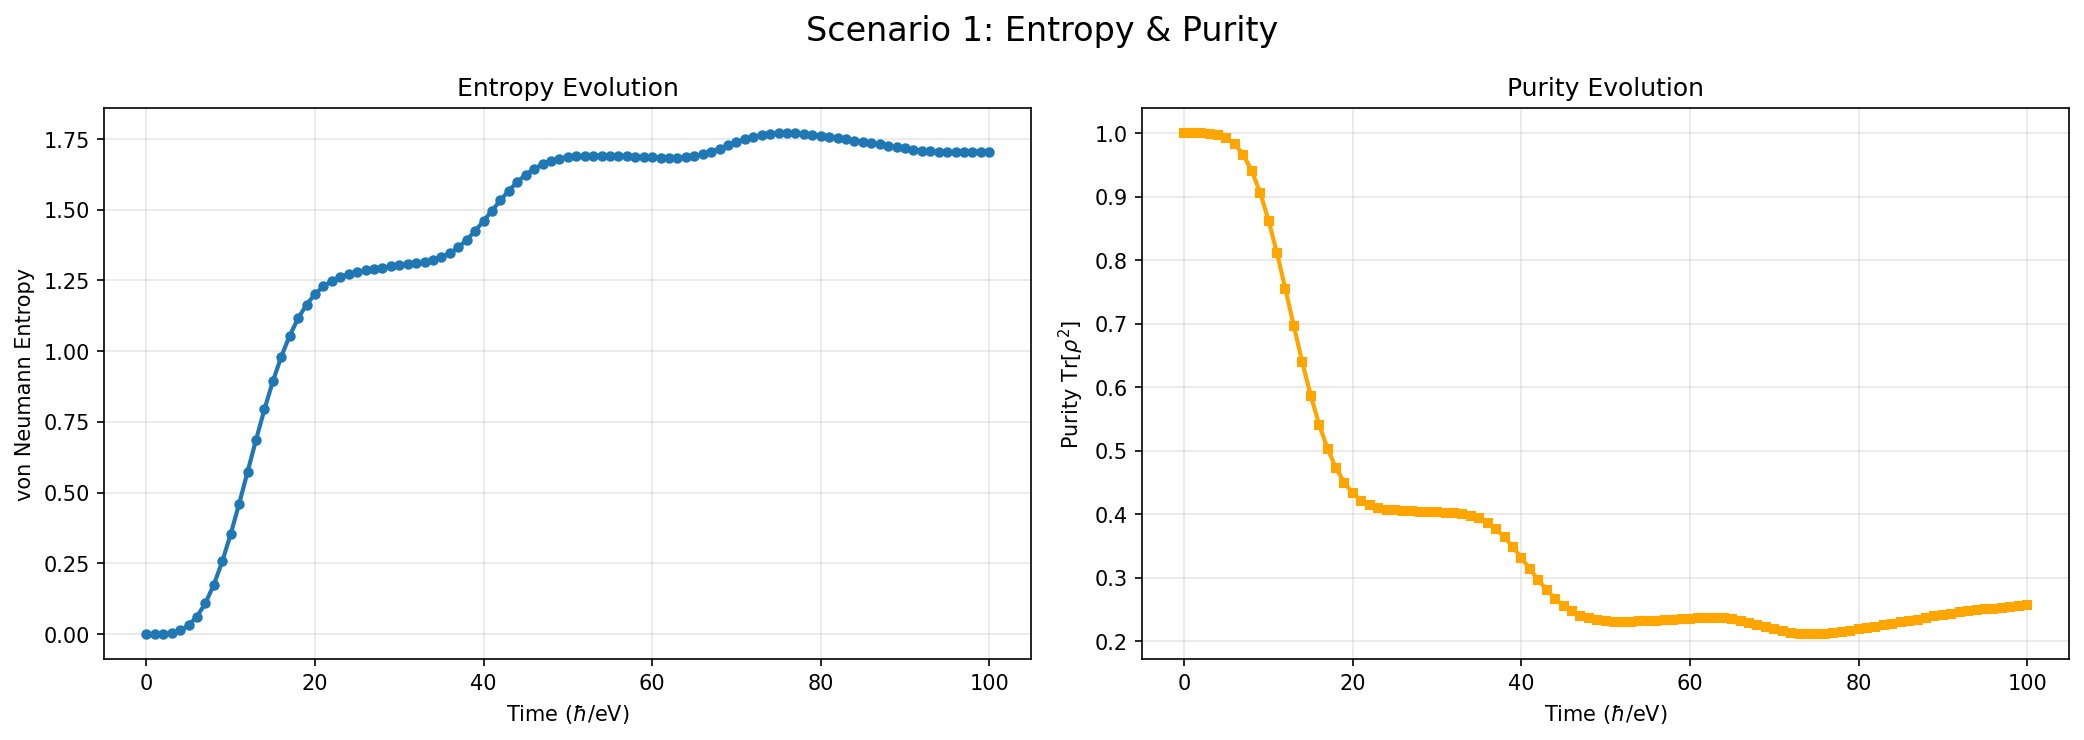

In [2]:
from classical_gksl_simulator import ClassicalGKSLSimulator
from gksl_visualization import plot_population_dynamics, plot_entropy_and_purity
from IPython.display import display, Image

os.makedirs("circuit_images", exist_ok=True)

sim1 = ClassicalGKSLSimulator(params)
result1 = sim1.simulate(t_max=t_max, n_steps=n_steps, initial_state='edge_triplet')

print(f'Elapsed time: {result1["elapsed_time"]:.2f}s')
print(f'Final populations: N_S0={result1["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result1["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result1["populations"][-1]["N_S1"]:.4f}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result1["trace"]):.2e}')

plot_population_dynamics(result1, title='Scenario 1: Classical GKSL (No Boson)',
                         save_path='circuit_images/scenario1_population.png')
display(Image(filename='circuit_images/scenario1_population.png'))

plot_entropy_and_purity(result1, title='Scenario 1: Entropy & Purity',
                        save_path='circuit_images/scenario1_entropy_purity.png')
display(Image(filename='circuit_images/scenario1_entropy_purity.png'))


## 3. シナリオ5: Qudit GKSL（ボソン無し）

ネイティブqutrit(d=3) + Stinespring dilation + 2次対称Trotter分解。
4 qutrit + 26 ancilla qudit(d=3) = 30 qudit相当（qudit量子コンピュータ向け）。
禁止状態なし（qutritの自然なエンコーディング）。

Elapsed time: 9.36s
System qutrits: 4
Ancilla qudits: 26
Total qudits: 30
Estimated gates/step: 66
Total estimated gates: 6600
Trace conservation: max|Tr-1| = 2.02e-14


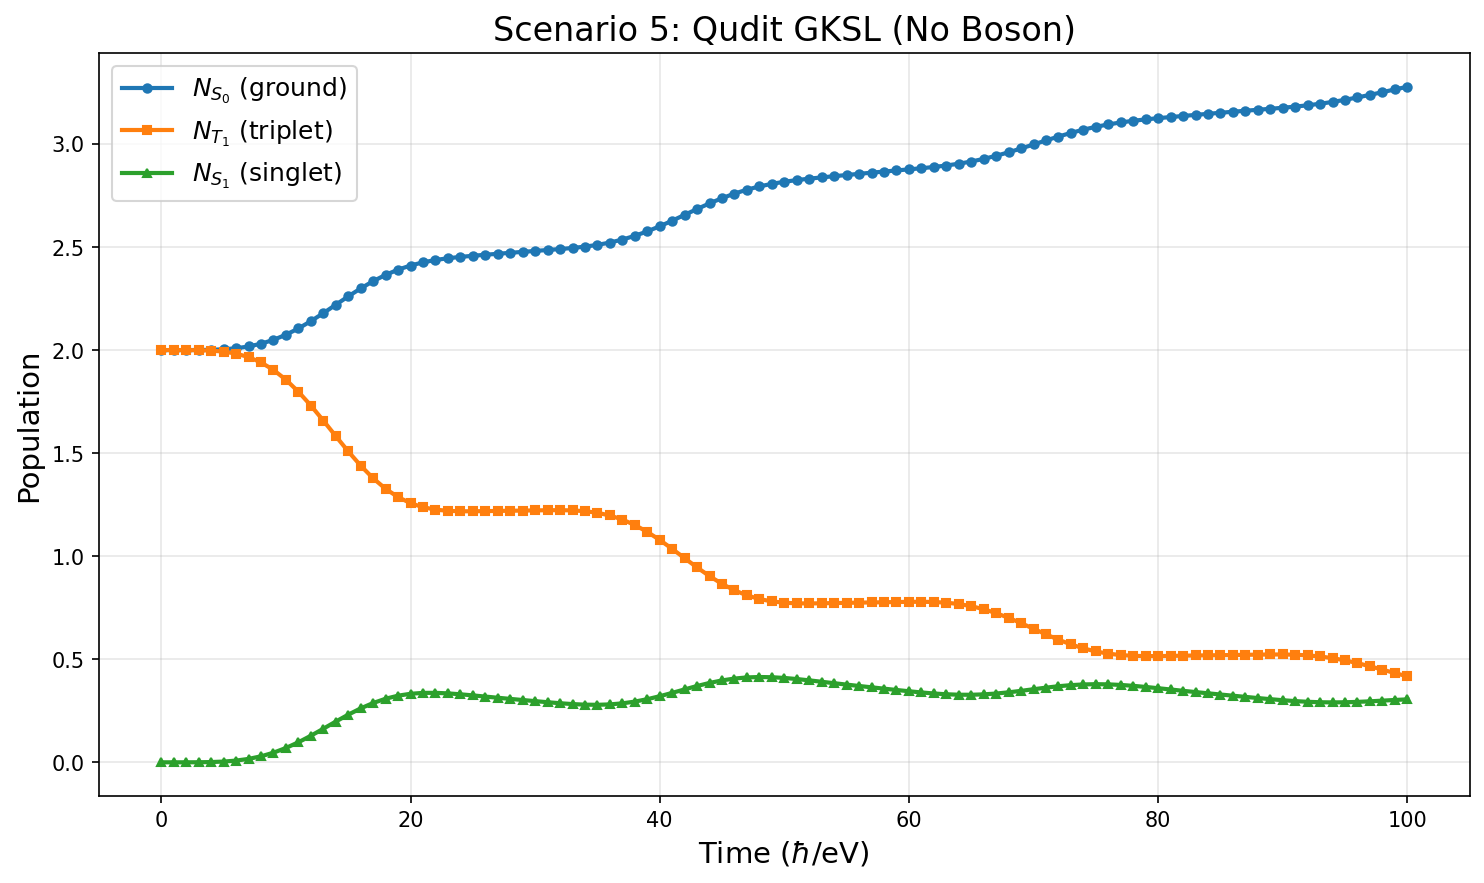

In [3]:
from qudit_gksl_simulator import QuditGKSLSimulator
from IPython.display import display, Image

sim5 = QuditGKSLSimulator(params)
result5 = sim5.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result5["elapsed_time"]:.2f}s')
print(f'System qutrits: {result5["n_system_qudits"]}')
print(f'Ancilla qudits: {result5["n_ancilla_qudits"]}')
print(f'Total qudits: {result5["n_total_qudits"]}')
print(f'Estimated gates/step: {result5["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result5["total_estimated_gates"]}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result5["trace"]):.2e}')

plot_population_dynamics(result5, title='Scenario 5: Qudit GKSL (No Boson)',
                         save_path='circuit_images/scenario5_population.png')
display(Image(filename='circuit_images/scenario5_population.png'))


## 4. シナリオ3: Qubit GKSL（ボソン無し）

2-qubitエンコーディング(|00⟩=S0, |01⟩=T1, |10⟩=S1, |11⟩=禁止) + Stinespring + Trotter。
8 system qubit + 26 ancilla = 34 qubit。

Elapsed time: 30.57s
System qubits: 8
Ancilla qubits: 26
Total qubits: 34
Estimated gates/step: 388
Total estimated gates: 38800
Trace conservation: max|Tr-1| = 2.04e-14


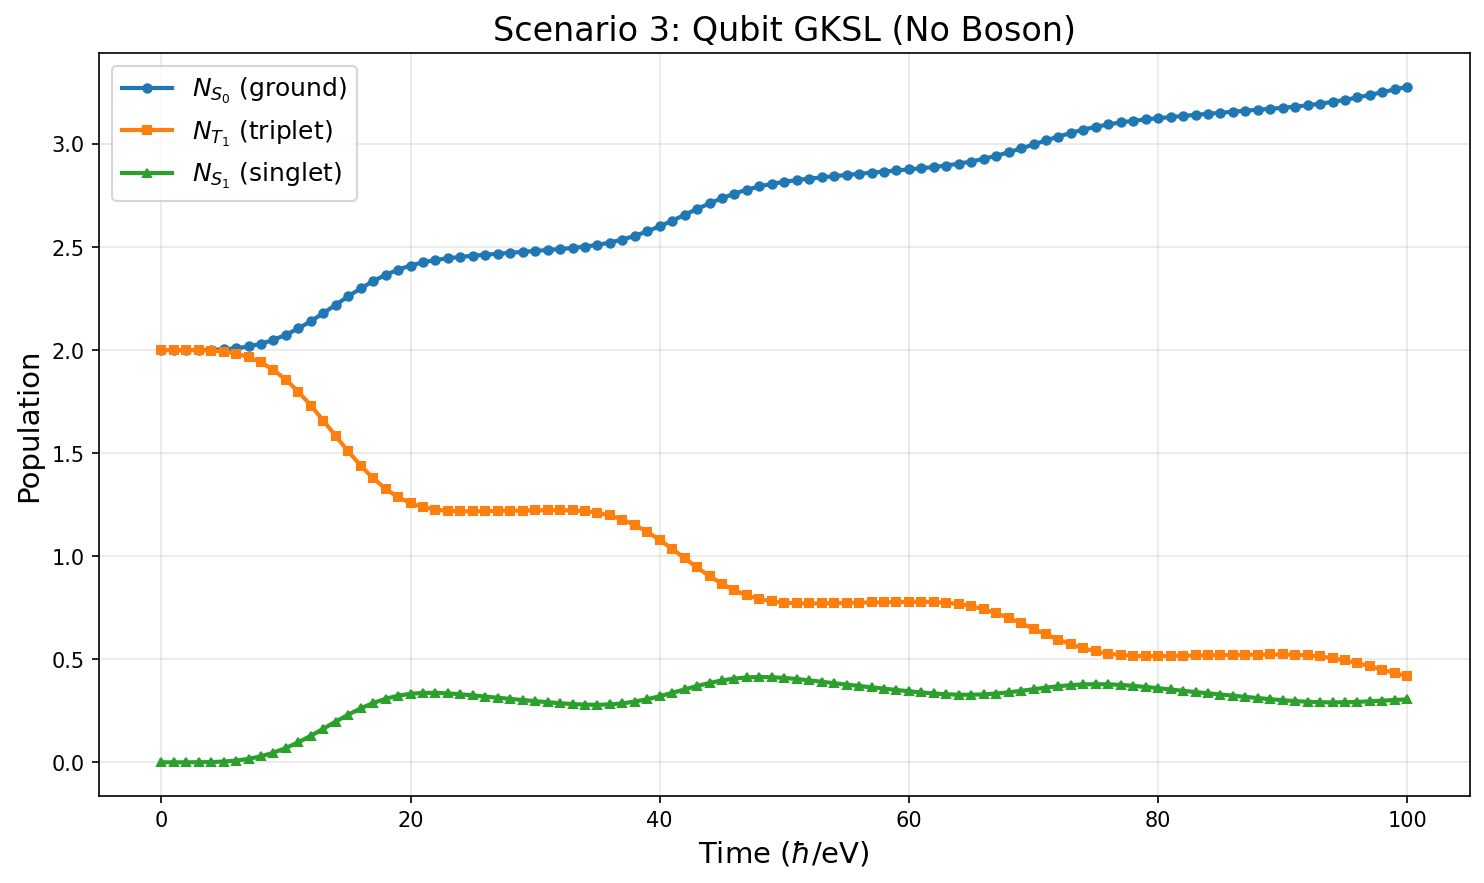

In [4]:
from qubit_gksl_simulator import QubitGKSLSimulator
from IPython.display import display, Image

sim3 = QubitGKSLSimulator(params)
result3 = sim3.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result3["elapsed_time"]:.2f}s')
print(f'System qubits: {result3["n_sys_qubits"]}')
print(f'Ancilla qubits: {result3["n_ancilla"]}')
print(f'Total qubits: {result3["n_total_qubits"]}')
print(f'Estimated gates/step: {result3["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result3["total_estimated_gates"]}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result3["trace"]):.2e}')

plot_population_dynamics(result3, title='Scenario 3: Qubit GKSL (No Boson)',
                         save_path='circuit_images/scenario3_population.png')
display(Image(filename='circuit_images/scenario3_population.png'))


## 5. シナリオ2: 古典GKSL（ボソン有り）

Holstein型電子-フォノン結合を含むBDF法ODE積分。
計算負荷のため、2分子・n_max=1で実行（dim=36）。

Elapsed time: 0.27s
Trace conservation: max|Tr-1| = 5.77e-15


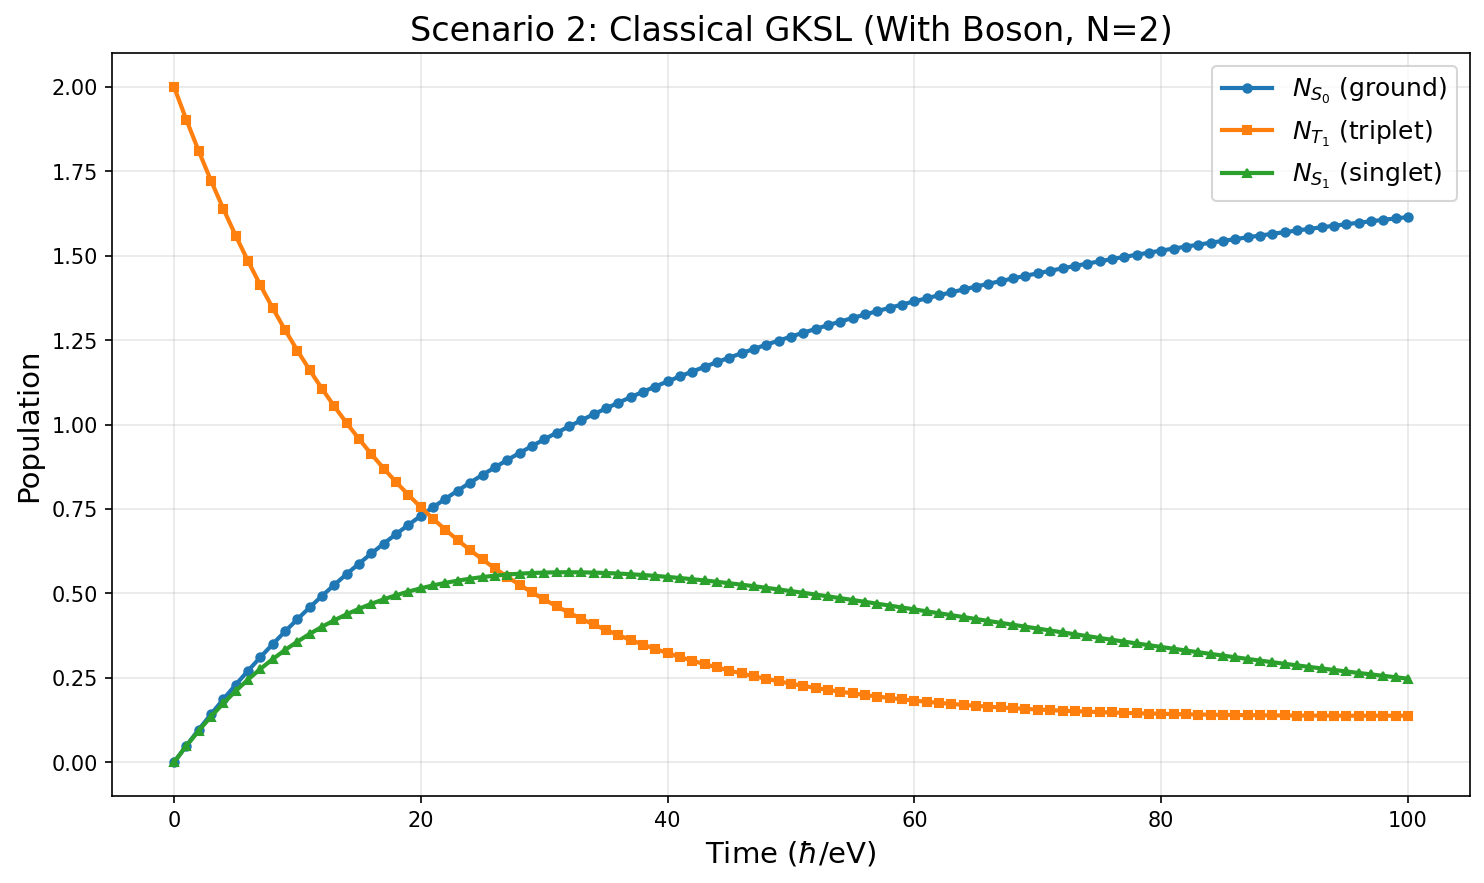

In [5]:
from classical_gksl_boson_simulator import ClassicalGKSLBosonSimulator
from IPython.display import display, Image

sim2 = ClassicalGKSLBosonSimulator(params_boson)
result2 = sim2.simulate(t_max=t_max, n_steps=n_steps, initial_state='edge_triplet')

print(f'Elapsed time: {result2["elapsed_time"]:.2f}s')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result2["trace"]):.2e}')

plot_population_dynamics(result2, title='Scenario 2: Classical GKSL (With Boson, N=2)',
                         save_path='circuit_images/scenario2_population.png')
display(Image(filename='circuit_images/scenario2_population.png'))


## 6. シナリオ6: Qudit GKSL（ボソン有り）

qutrit電子系 + qutritフォノン系 + Stinespring dilation。
2分子・n_max=1で実行。

Elapsed time: 3.11s
System qutrits: 2
Phonon qutrits: 2
Ancilla qudits: 12
Total qudits: 16
Estimated gates/step: 38
Total estimated gates: 3800
Trace conservation: max|Tr-1| = 9.99e-15


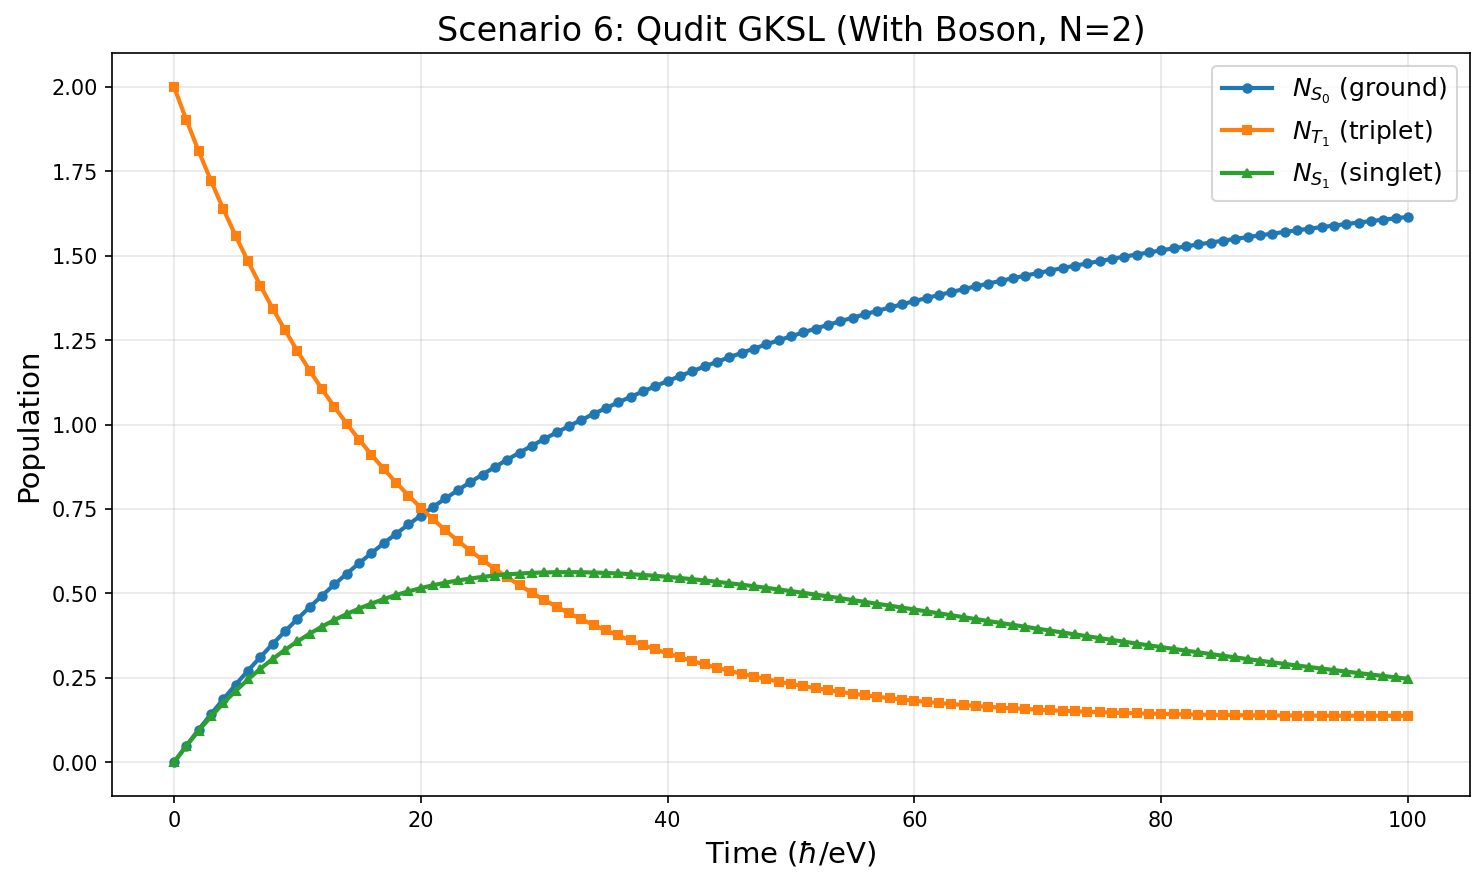

In [6]:
from qudit_gksl_boson_simulator import QuditGKSLBosonSimulator
from IPython.display import display, Image

sim6 = QuditGKSLBosonSimulator(params_boson)
result6 = sim6.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result6["elapsed_time"]:.2f}s')
print(f'System qutrits: {result6["n_system_qudits"]}')
print(f'Phonon qutrits: {result6["n_phonon_qudits"]}')
print(f'Ancilla qudits: {result6["n_ancilla_qudits"]}')
print(f'Total qudits: {result6["n_total_qudits"]}')
print(f'Estimated gates/step: {result6["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result6["total_estimated_gates"]}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result6["trace"]):.2e}')

plot_population_dynamics(result6, title='Scenario 6: Qudit GKSL (With Boson, N=2)',
                         save_path='circuit_images/scenario6_population.png')
display(Image(filename='circuit_images/scenario6_population.png'))


## 7. シナリオ4: Qubit GKSL（ボソン有り）

Qubit Stinespring + Trotter in 拡張空間。
2分子・n_max=1で実行。

Elapsed time: 2.82s
Electronic qubits: 4
Phonon qubits: 2
Ancilla qubits: 12
Total qubits: 18
Estimated gates/step: 216
Total estimated gates: 21600
Trace conservation: max|Tr-1| = 1.01e-14


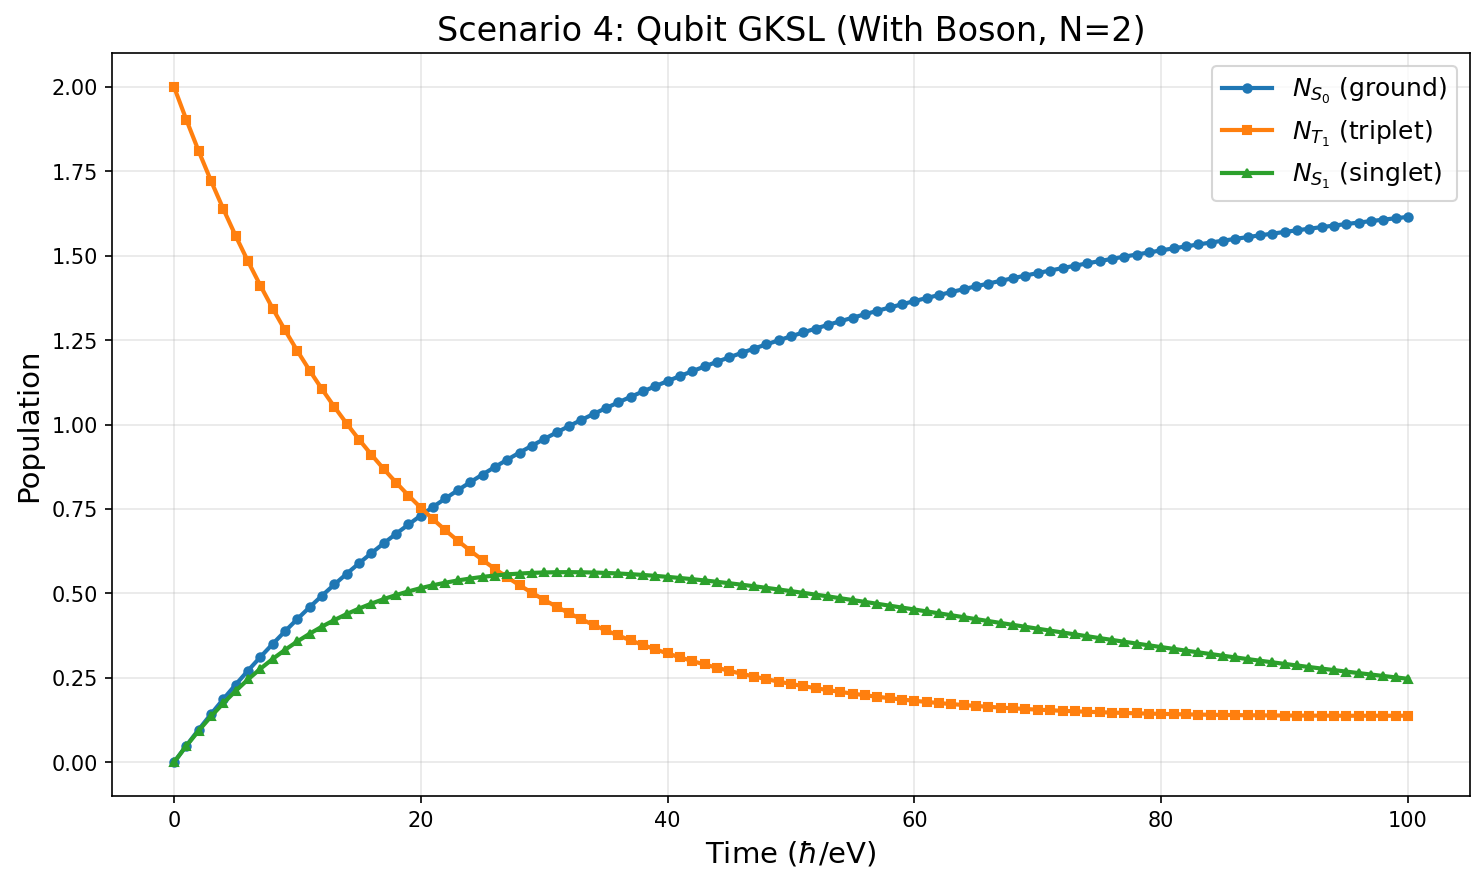

In [7]:
from qubit_gksl_boson_simulator import QubitGKSLBosonSimulator
from IPython.display import display, Image

sim4 = QubitGKSLBosonSimulator(params_boson)
result4 = sim4.simulate(t_max=t_max, n_steps=n_steps_quantum, initial_state='edge_triplet')

print(f'Elapsed time: {result4["elapsed_time"]:.2f}s')
print(f'Electronic qubits: {result4["n_el_qubits"]}')
print(f'Phonon qubits: {result4["n_ph_qubits"]}')
print(f'Ancilla qubits: {result4["n_ancilla"]}')
print(f'Total qubits: {result4["n_total_qubits"]}')
print(f'Estimated gates/step: {result4["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result4["total_estimated_gates"]}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result4["trace"]):.2e}')

plot_population_dynamics(result4, title='Scenario 4: Qubit GKSL (With Boson, N=2)',
                         save_path='circuit_images/scenario4_population.png')
display(Image(filename='circuit_images/scenario4_population.png'))


## 追補: 1トロッターステップ量子回路の可視化

各量子シミュレーションで1トロッターステップに実際に適用している回路（または等価な行列演算ゲート列）を全て表示します。


Scenario 3: Qubit GKSL (No Boson) - 1 Trotter Step
subcircuits: 54

[01] hamiltonian_half_1 -> circuit_images/scenario3_qubit_nb_01_hamiltonian_half_1.png


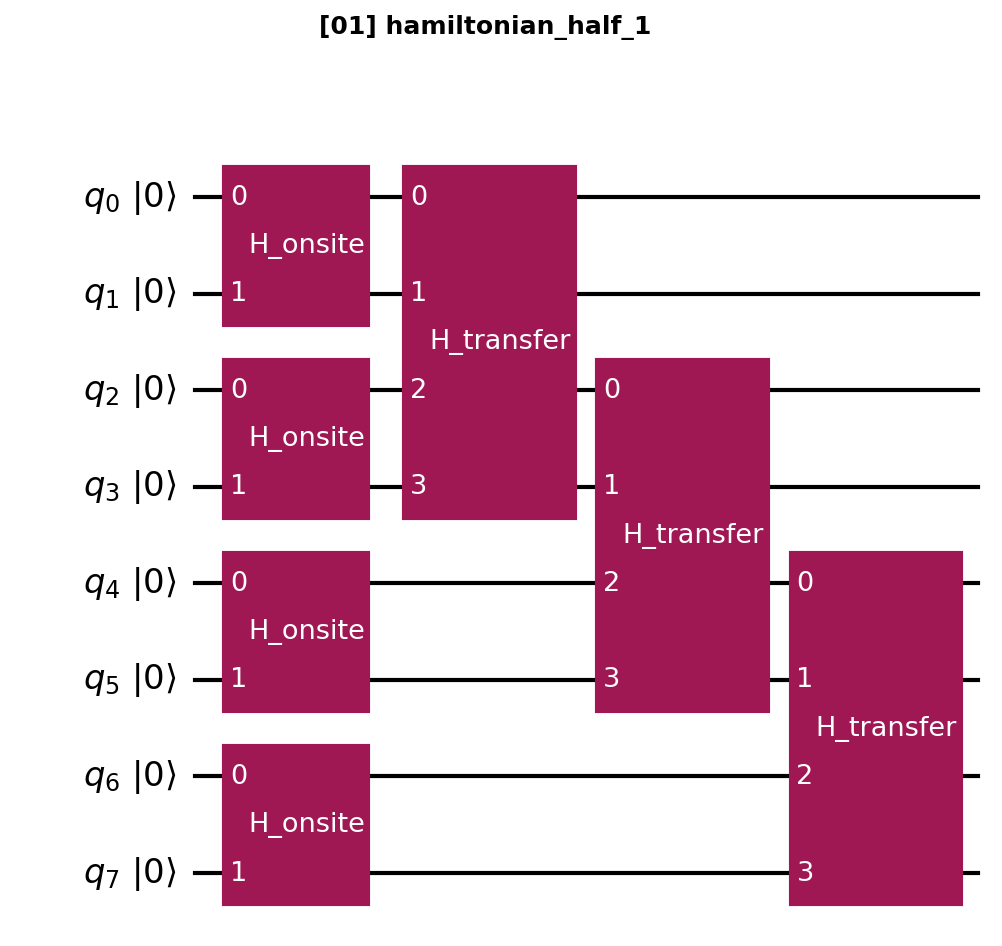


[02] stinespring_fwd_pair_0 -> circuit_images/scenario3_qubit_nb_02_stinespring_fwd_pair_0.png


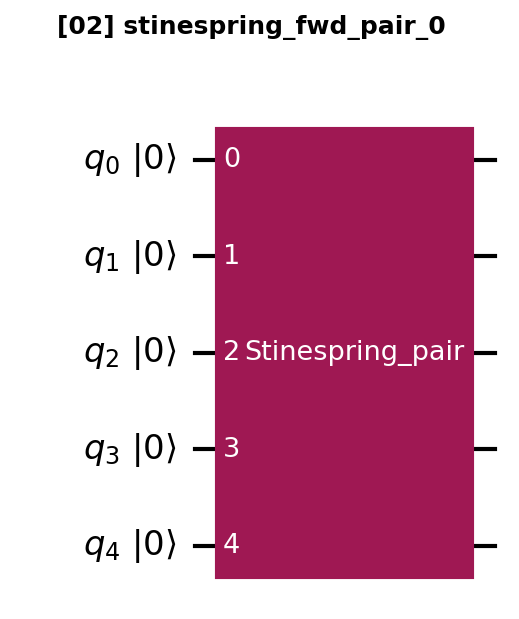


[03] stinespring_fwd_pair_1 -> circuit_images/scenario3_qubit_nb_03_stinespring_fwd_pair_1.png


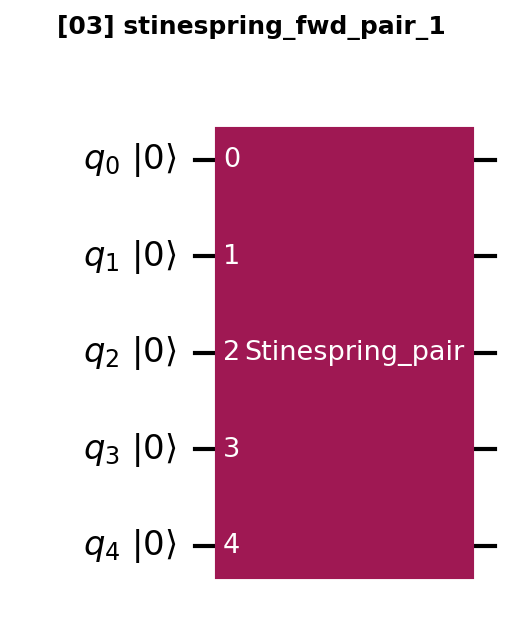


[04] stinespring_fwd_pair_2 -> circuit_images/scenario3_qubit_nb_04_stinespring_fwd_pair_2.png


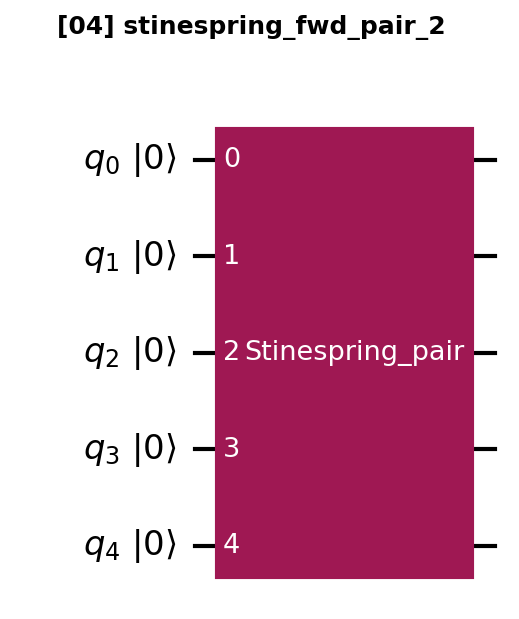


[05] stinespring_fwd_pair_3 -> circuit_images/scenario3_qubit_nb_05_stinespring_fwd_pair_3.png


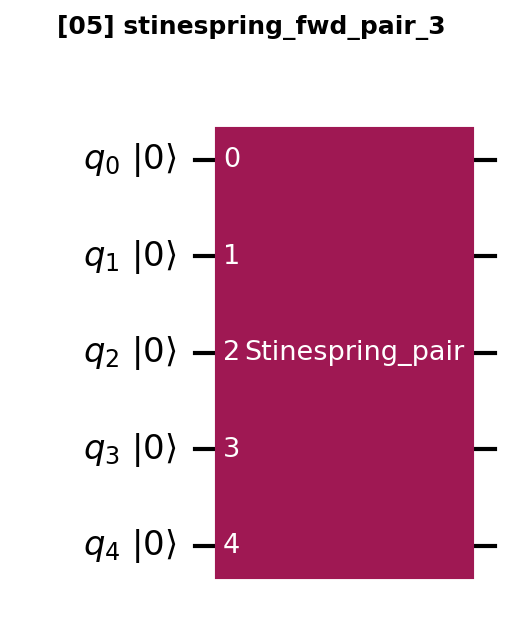


[06] stinespring_fwd_pair_4 -> circuit_images/scenario3_qubit_nb_06_stinespring_fwd_pair_4.png


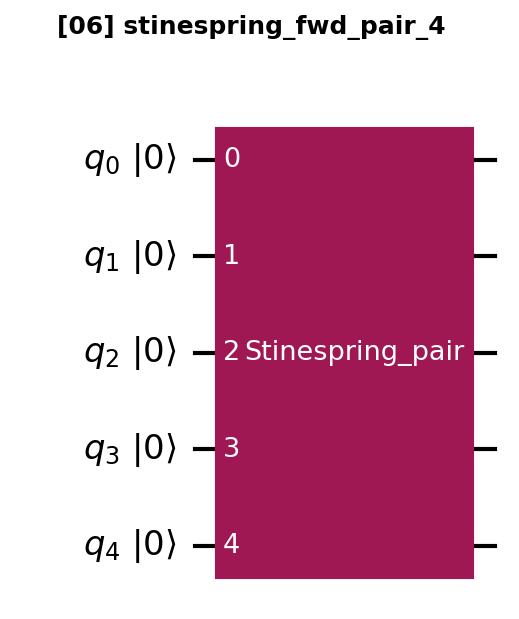


[07] stinespring_fwd_pair_5 -> circuit_images/scenario3_qubit_nb_07_stinespring_fwd_pair_5.png


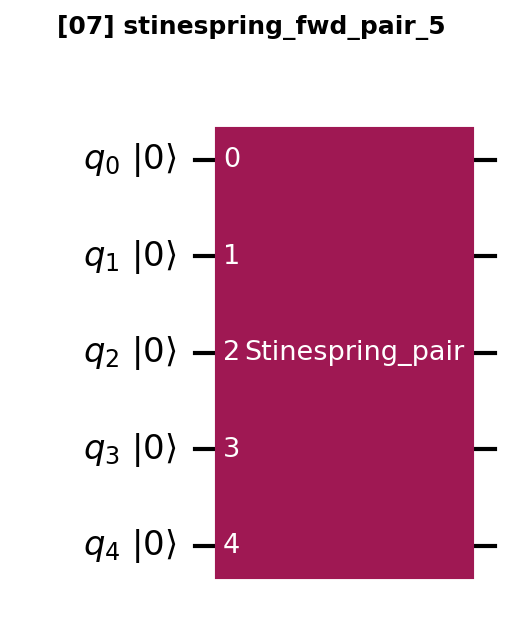


[08] stinespring_fwd_single_6 -> circuit_images/scenario3_qubit_nb_08_stinespring_fwd_single_6.png


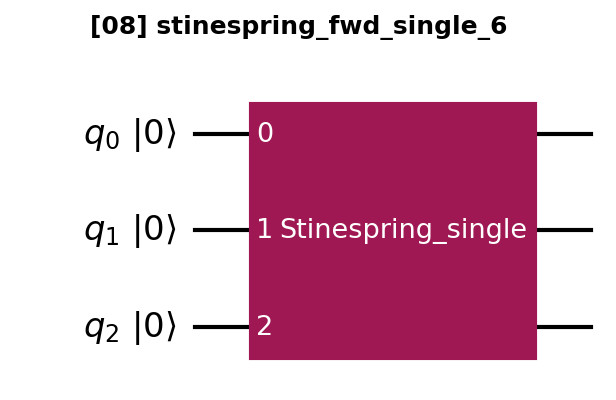


[09] stinespring_fwd_single_7 -> circuit_images/scenario3_qubit_nb_09_stinespring_fwd_single_7.png


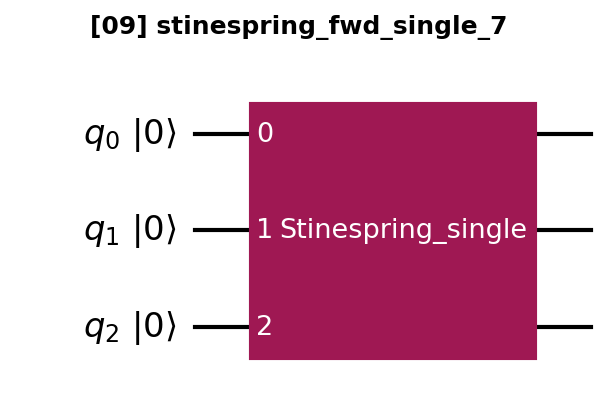


[10] stinespring_fwd_single_8 -> circuit_images/scenario3_qubit_nb_10_stinespring_fwd_single_8.png


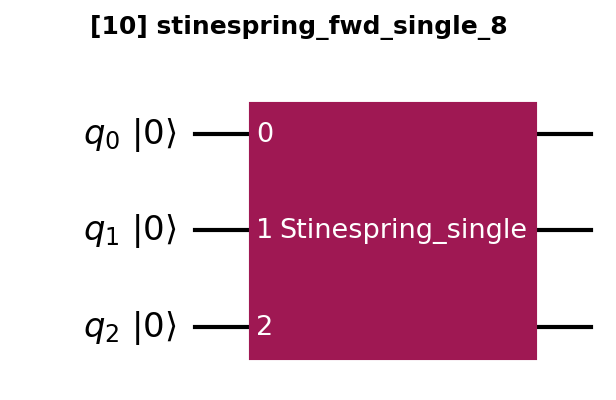


[11] stinespring_fwd_single_9 -> circuit_images/scenario3_qubit_nb_11_stinespring_fwd_single_9.png


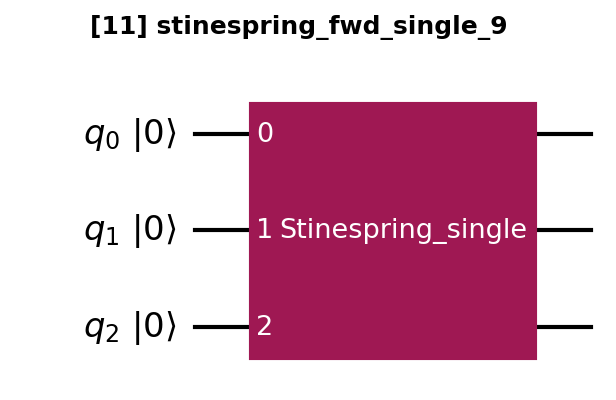


[12] stinespring_fwd_single_10 -> circuit_images/scenario3_qubit_nb_12_stinespring_fwd_single_10.png


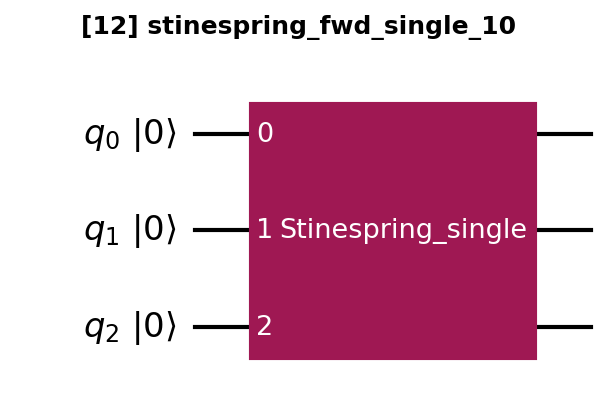


[13] stinespring_fwd_single_11 -> circuit_images/scenario3_qubit_nb_13_stinespring_fwd_single_11.png


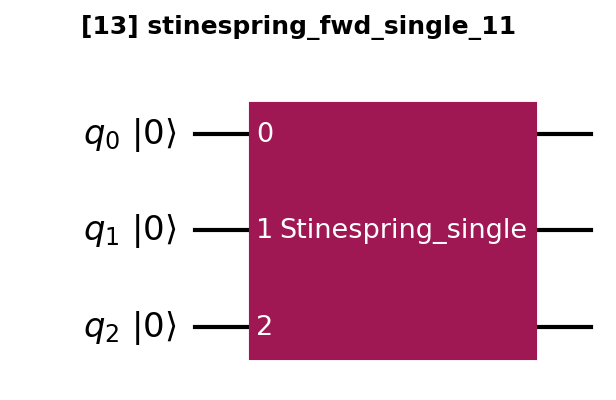


[14] stinespring_fwd_single_12 -> circuit_images/scenario3_qubit_nb_14_stinespring_fwd_single_12.png


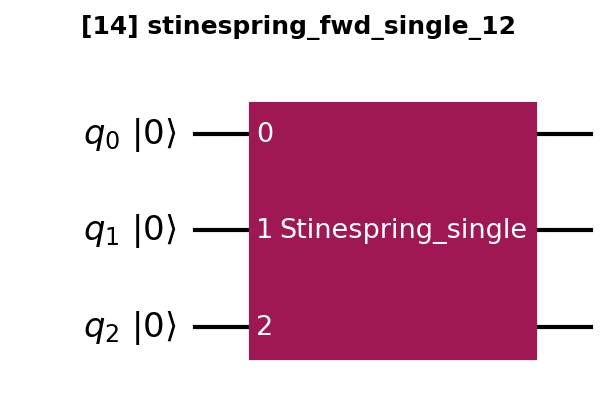


[15] stinespring_fwd_single_13 -> circuit_images/scenario3_qubit_nb_15_stinespring_fwd_single_13.png


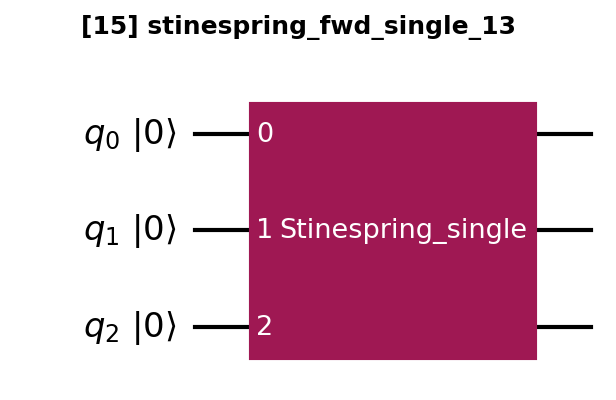


[16] stinespring_fwd_single_14 -> circuit_images/scenario3_qubit_nb_16_stinespring_fwd_single_14.png


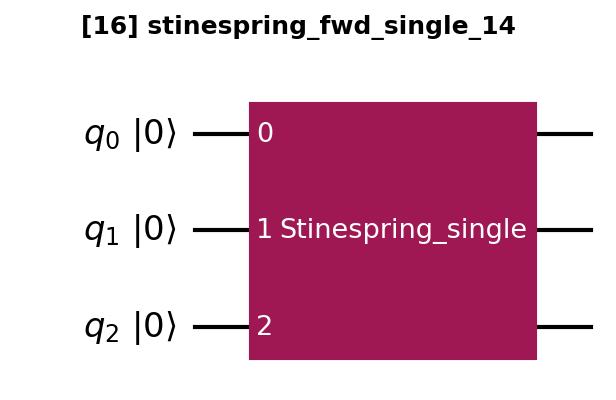


[17] stinespring_fwd_single_15 -> circuit_images/scenario3_qubit_nb_17_stinespring_fwd_single_15.png


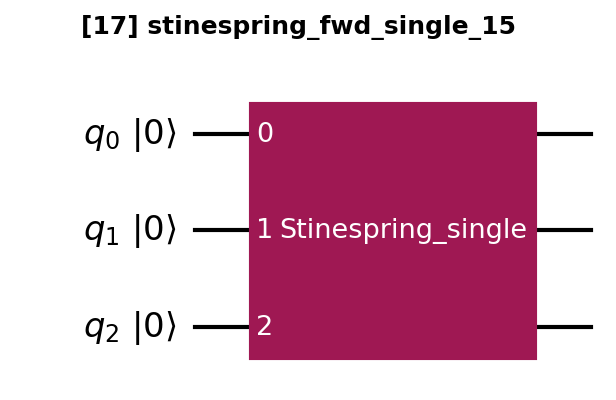


[18] stinespring_fwd_single_16 -> circuit_images/scenario3_qubit_nb_18_stinespring_fwd_single_16.png


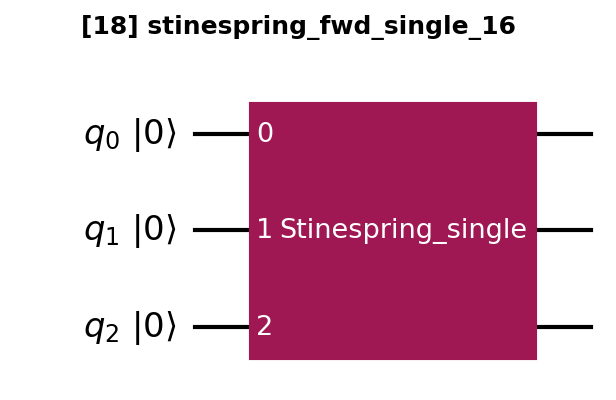


[19] stinespring_fwd_single_17 -> circuit_images/scenario3_qubit_nb_19_stinespring_fwd_single_17.png


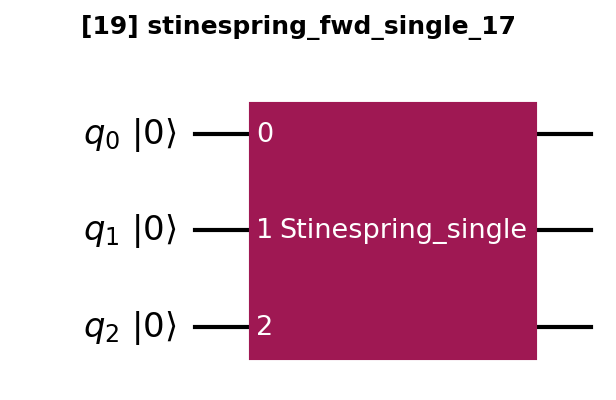


[20] stinespring_fwd_single_18 -> circuit_images/scenario3_qubit_nb_20_stinespring_fwd_single_18.png


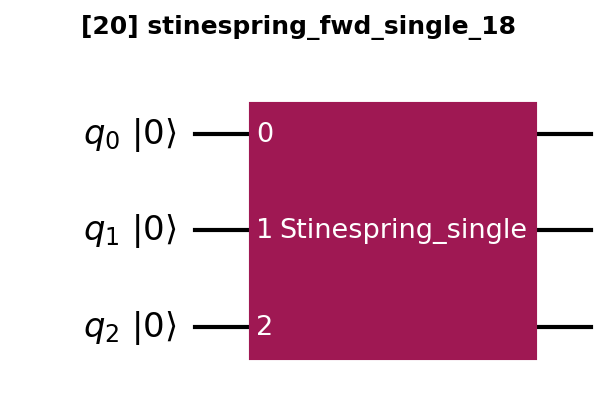


[21] stinespring_fwd_single_19 -> circuit_images/scenario3_qubit_nb_21_stinespring_fwd_single_19.png


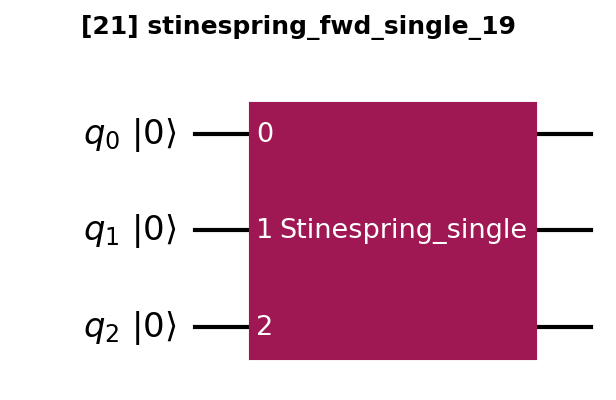


[22] stinespring_fwd_single_20 -> circuit_images/scenario3_qubit_nb_22_stinespring_fwd_single_20.png


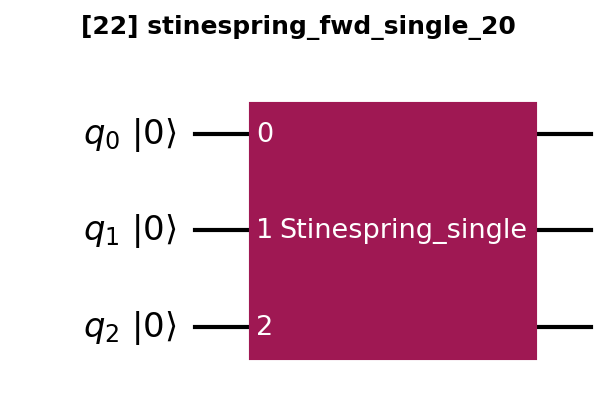


[23] stinespring_fwd_single_21 -> circuit_images/scenario3_qubit_nb_23_stinespring_fwd_single_21.png


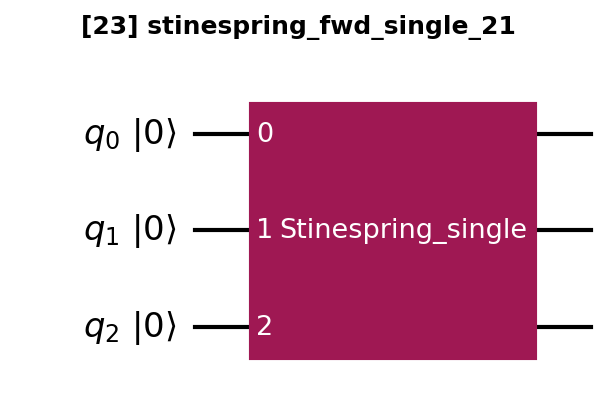


[24] stinespring_fwd_single_22 -> circuit_images/scenario3_qubit_nb_24_stinespring_fwd_single_22.png


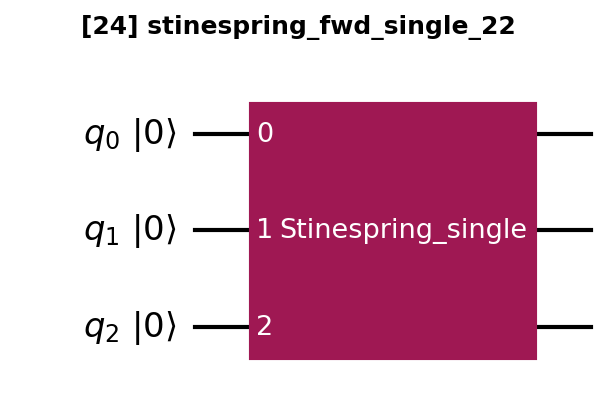


[25] stinespring_fwd_single_23 -> circuit_images/scenario3_qubit_nb_25_stinespring_fwd_single_23.png


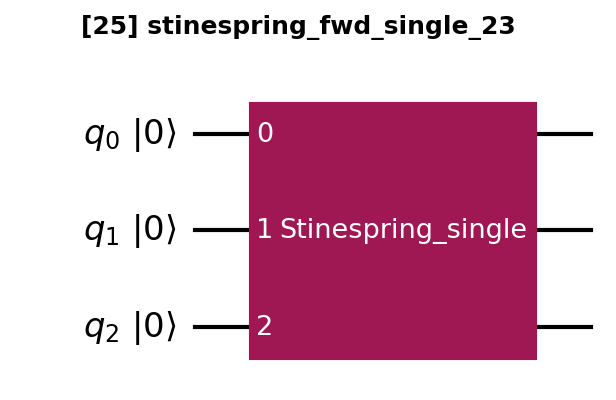


[26] stinespring_fwd_single_24 -> circuit_images/scenario3_qubit_nb_26_stinespring_fwd_single_24.png


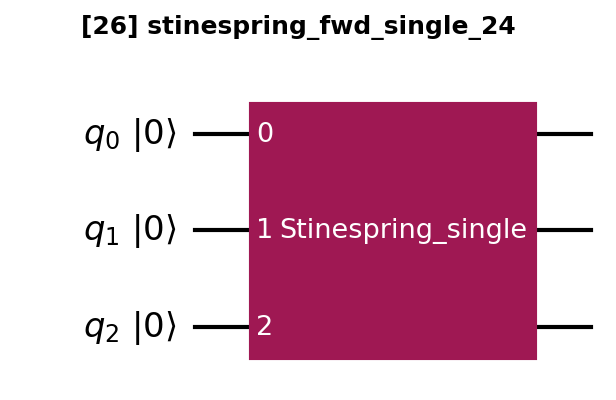


[27] stinespring_fwd_single_25 -> circuit_images/scenario3_qubit_nb_27_stinespring_fwd_single_25.png


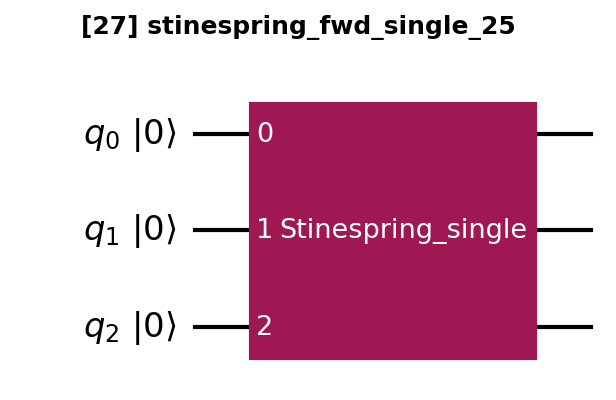


[28] stinespring_rev_single_25 -> circuit_images/scenario3_qubit_nb_28_stinespring_rev_single_25.png


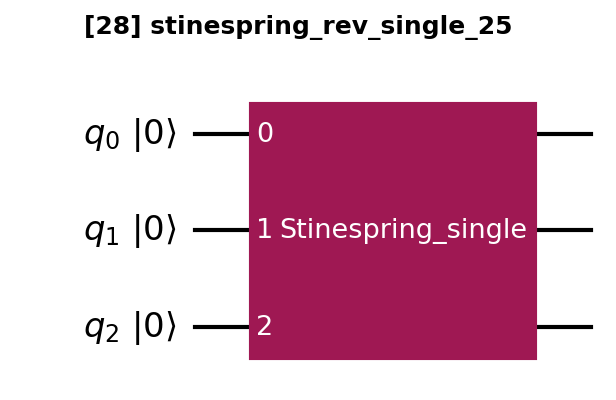


[29] stinespring_rev_single_24 -> circuit_images/scenario3_qubit_nb_29_stinespring_rev_single_24.png


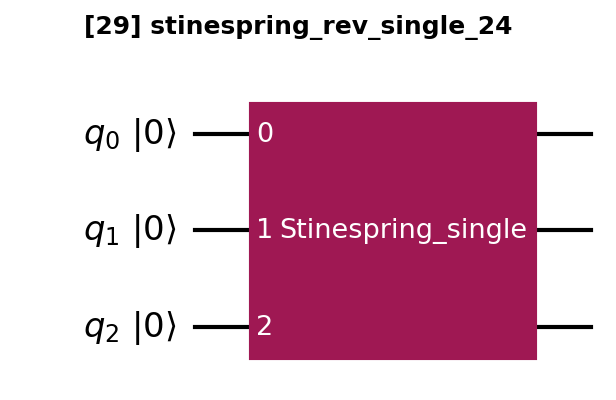


[30] stinespring_rev_single_23 -> circuit_images/scenario3_qubit_nb_30_stinespring_rev_single_23.png


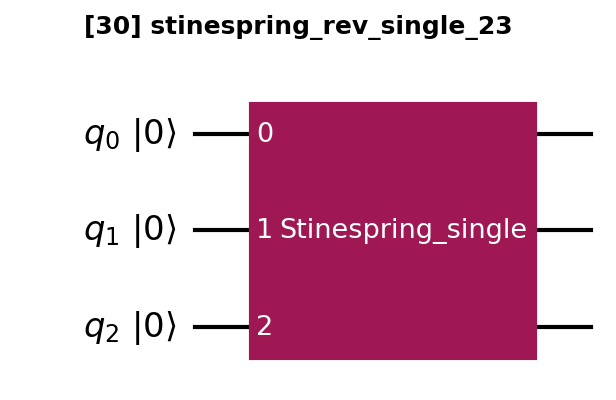


[31] stinespring_rev_single_22 -> circuit_images/scenario3_qubit_nb_31_stinespring_rev_single_22.png


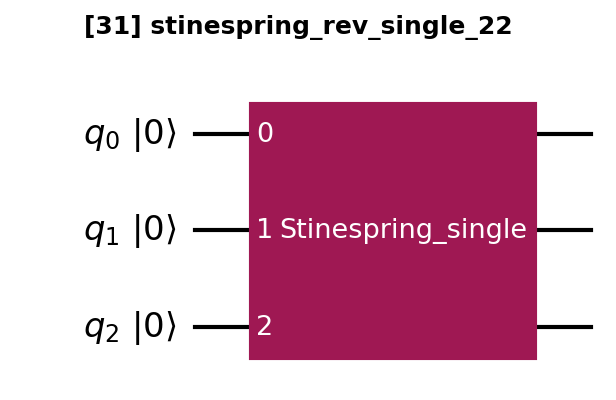


[32] stinespring_rev_single_21 -> circuit_images/scenario3_qubit_nb_32_stinespring_rev_single_21.png


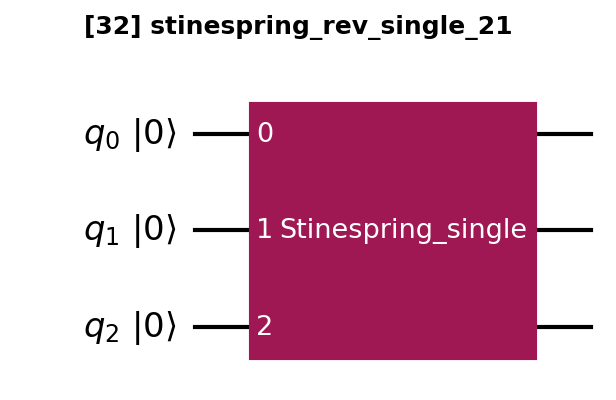


[33] stinespring_rev_single_20 -> circuit_images/scenario3_qubit_nb_33_stinespring_rev_single_20.png


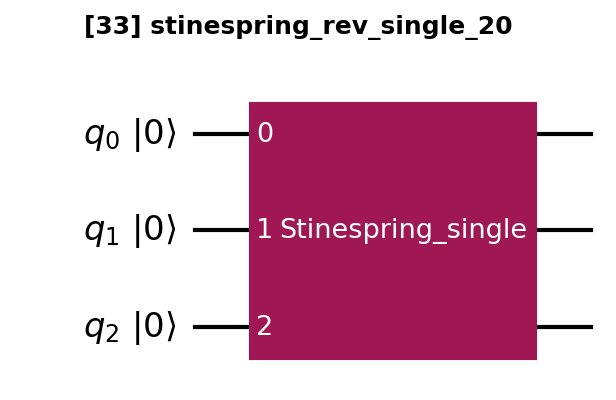


[34] stinespring_rev_single_19 -> circuit_images/scenario3_qubit_nb_34_stinespring_rev_single_19.png


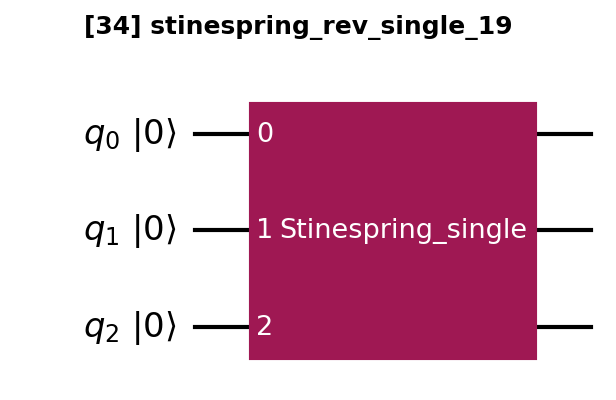


[35] stinespring_rev_single_18 -> circuit_images/scenario3_qubit_nb_35_stinespring_rev_single_18.png


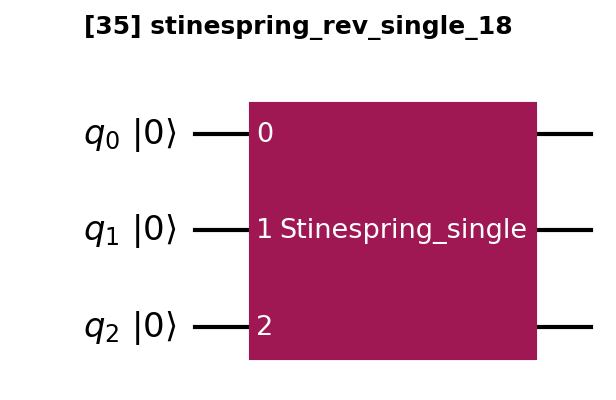


[36] stinespring_rev_single_17 -> circuit_images/scenario3_qubit_nb_36_stinespring_rev_single_17.png


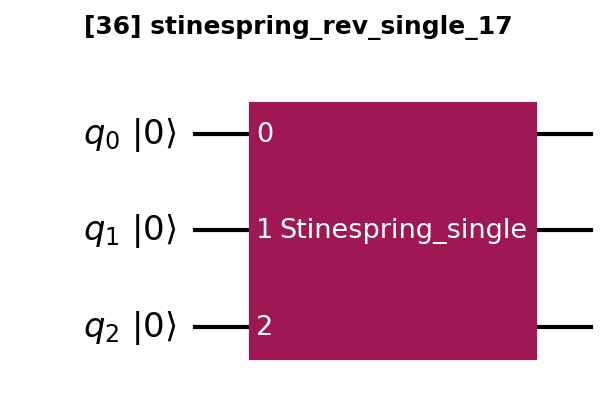


[37] stinespring_rev_single_16 -> circuit_images/scenario3_qubit_nb_37_stinespring_rev_single_16.png


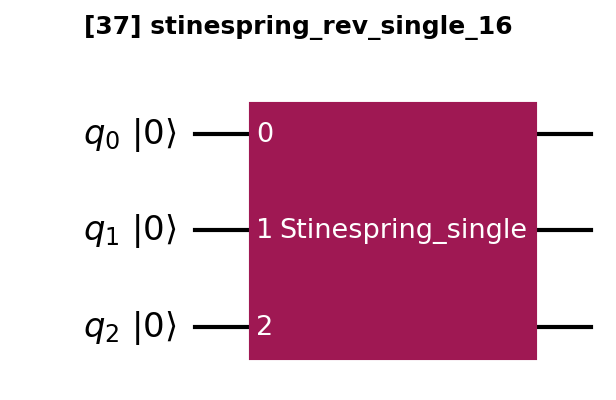


[38] stinespring_rev_single_15 -> circuit_images/scenario3_qubit_nb_38_stinespring_rev_single_15.png


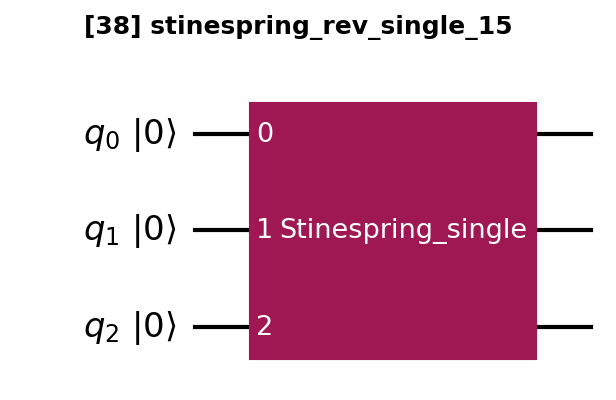


[39] stinespring_rev_single_14 -> circuit_images/scenario3_qubit_nb_39_stinespring_rev_single_14.png


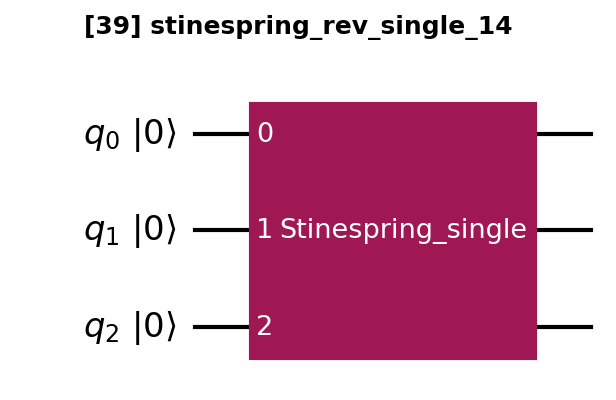


[40] stinespring_rev_single_13 -> circuit_images/scenario3_qubit_nb_40_stinespring_rev_single_13.png


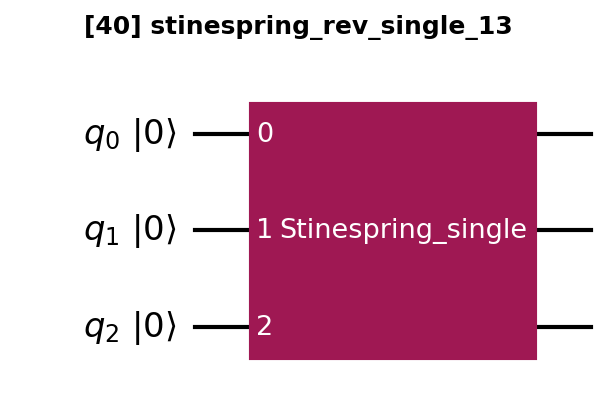


[41] stinespring_rev_single_12 -> circuit_images/scenario3_qubit_nb_41_stinespring_rev_single_12.png


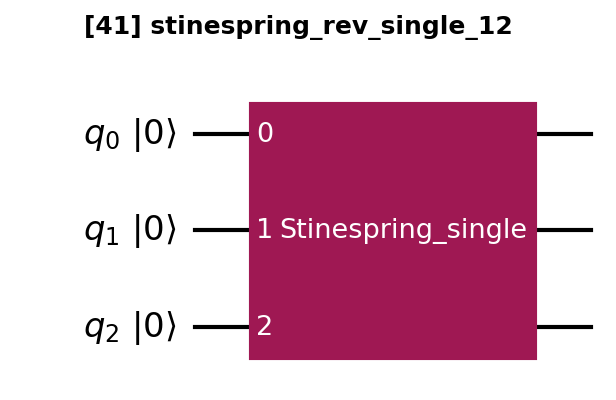


[42] stinespring_rev_single_11 -> circuit_images/scenario3_qubit_nb_42_stinespring_rev_single_11.png


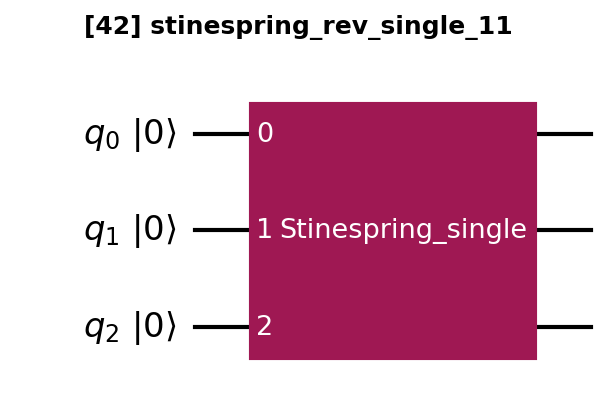


[43] stinespring_rev_single_10 -> circuit_images/scenario3_qubit_nb_43_stinespring_rev_single_10.png


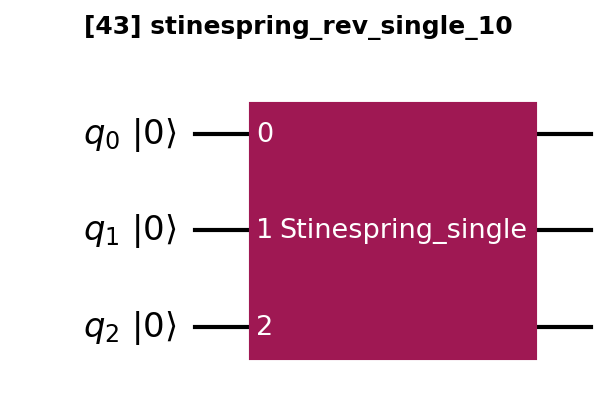


[44] stinespring_rev_single_9 -> circuit_images/scenario3_qubit_nb_44_stinespring_rev_single_9.png


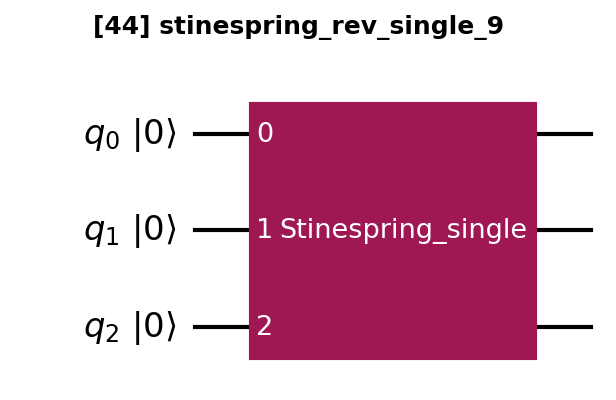


[45] stinespring_rev_single_8 -> circuit_images/scenario3_qubit_nb_45_stinespring_rev_single_8.png


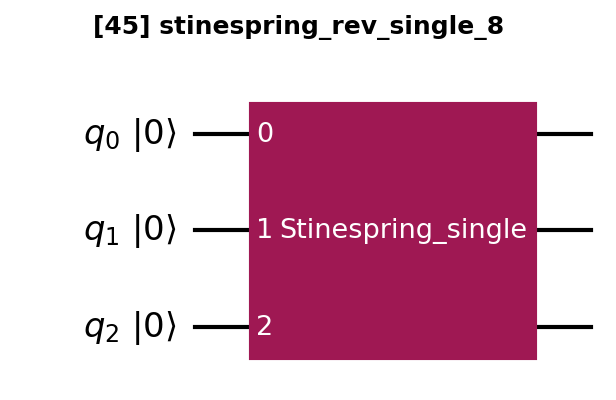


[46] stinespring_rev_single_7 -> circuit_images/scenario3_qubit_nb_46_stinespring_rev_single_7.png


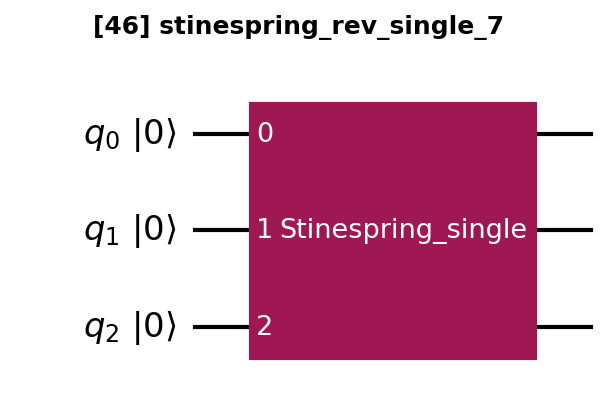


[47] stinespring_rev_single_6 -> circuit_images/scenario3_qubit_nb_47_stinespring_rev_single_6.png


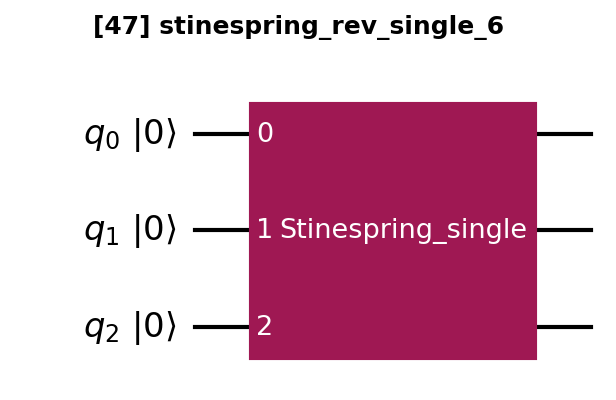


[48] stinespring_rev_pair_5 -> circuit_images/scenario3_qubit_nb_48_stinespring_rev_pair_5.png


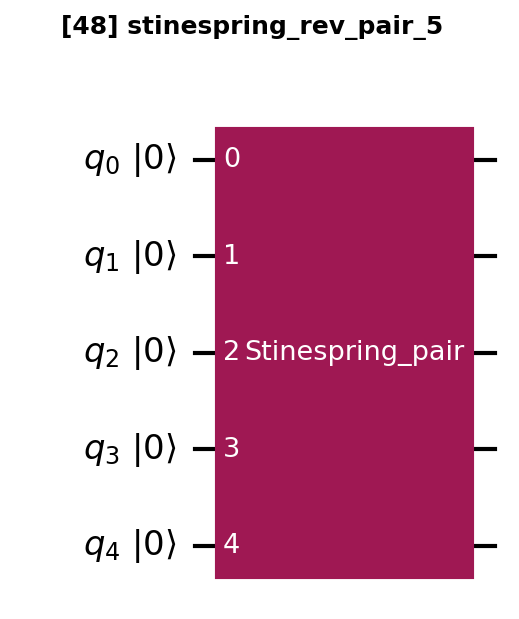


[49] stinespring_rev_pair_4 -> circuit_images/scenario3_qubit_nb_49_stinespring_rev_pair_4.png


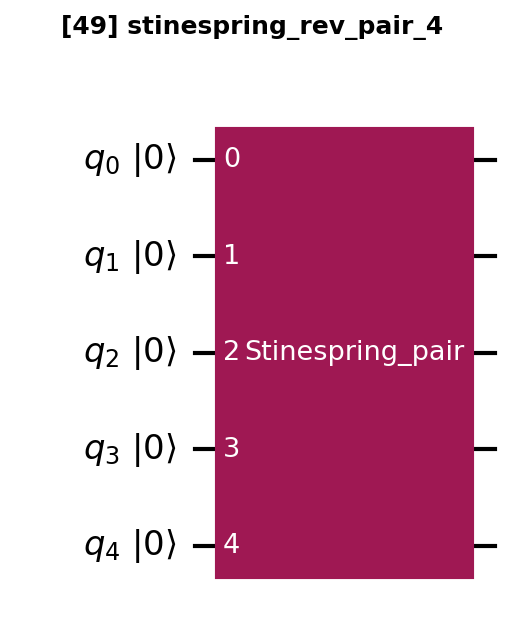


[50] stinespring_rev_pair_3 -> circuit_images/scenario3_qubit_nb_50_stinespring_rev_pair_3.png


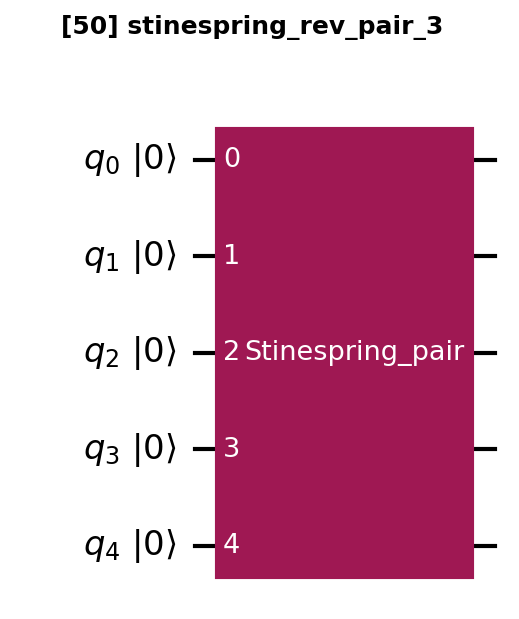


[51] stinespring_rev_pair_2 -> circuit_images/scenario3_qubit_nb_51_stinespring_rev_pair_2.png


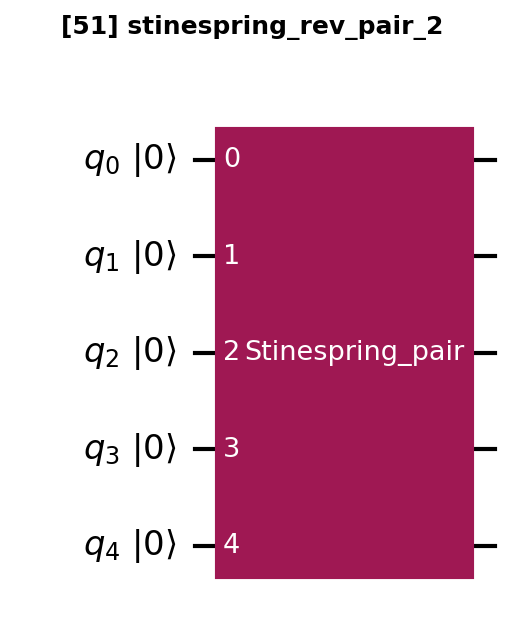


[52] stinespring_rev_pair_1 -> circuit_images/scenario3_qubit_nb_52_stinespring_rev_pair_1.png


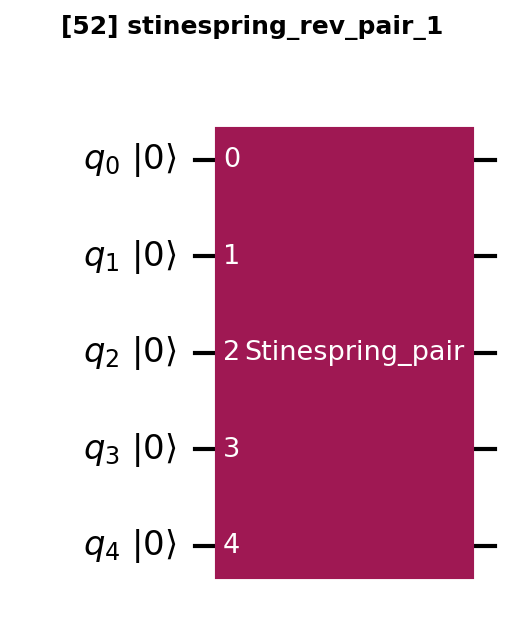


[53] stinespring_rev_pair_0 -> circuit_images/scenario3_qubit_nb_53_stinespring_rev_pair_0.png


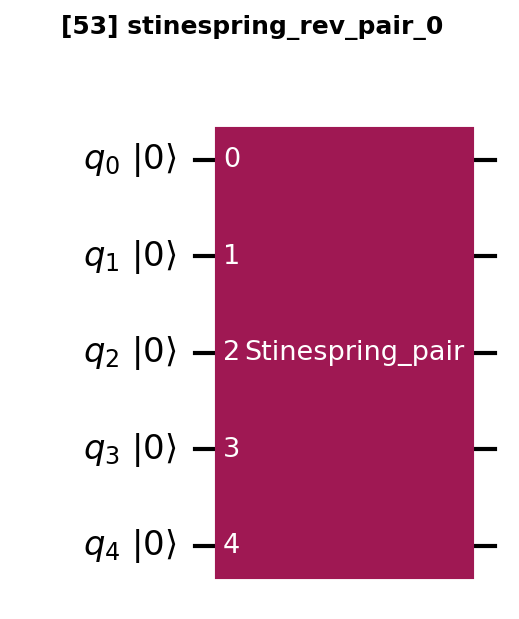


[54] hamiltonian_half_2 -> circuit_images/scenario3_qubit_nb_54_hamiltonian_half_2.png


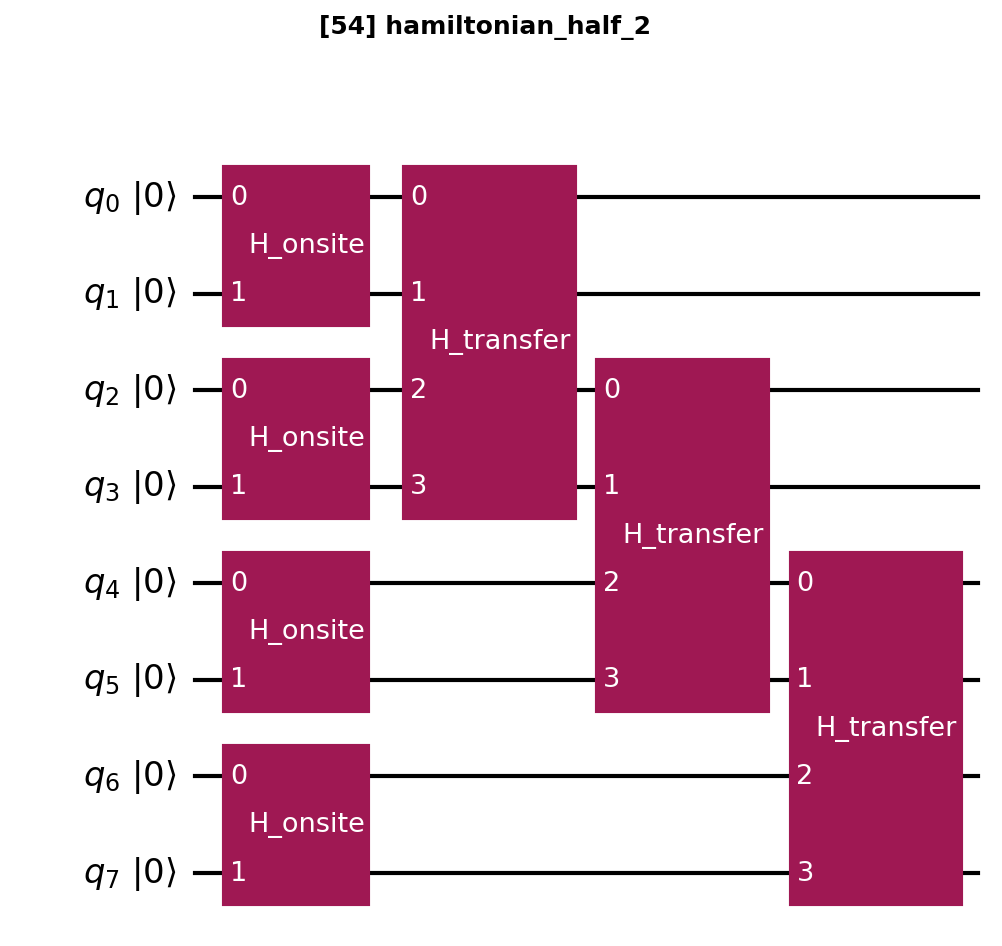


Scenario 5: Qudit GKSL (No Boson) - 1 Trotter Step
subcircuits: 54

[01] hamiltonian_half_1 -> circuit_images/scenario5_qudit_nb_01_hamiltonian_half_1.png


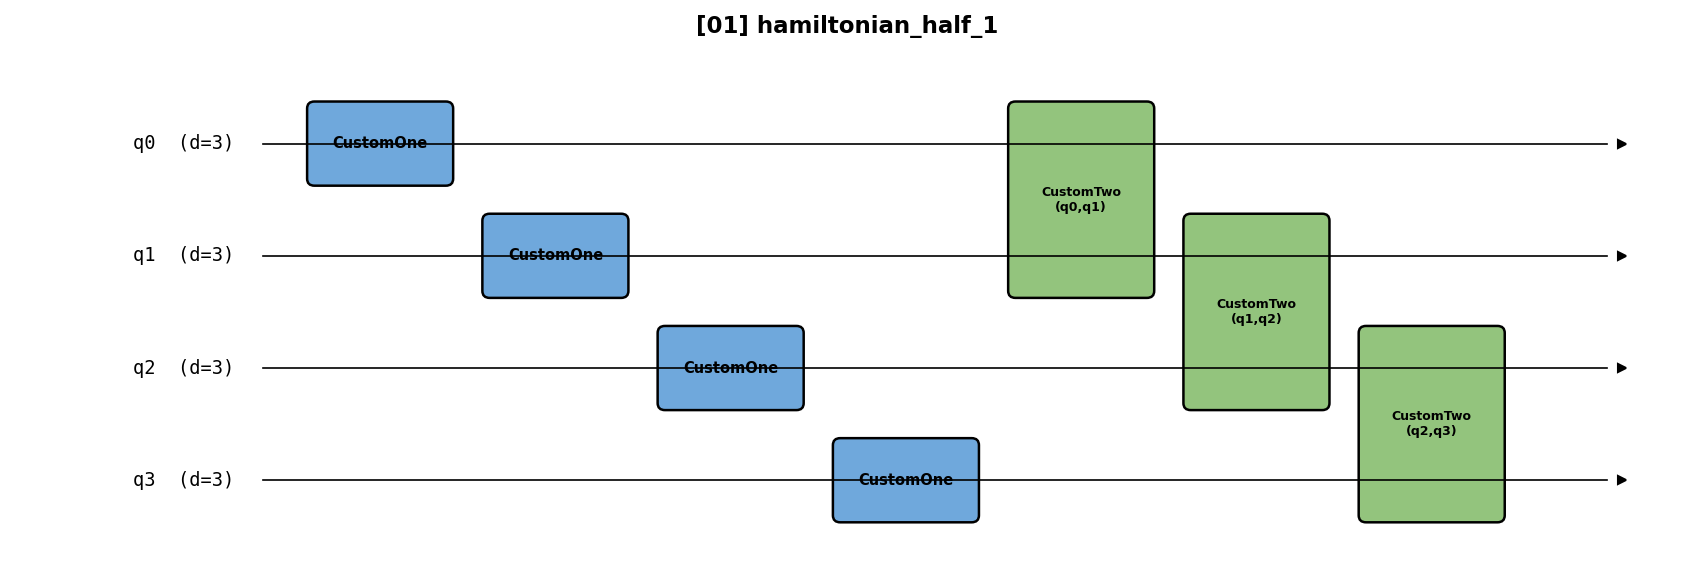


[02] stinespring_fwd_pair_0 -> circuit_images/scenario5_qudit_nb_02_stinespring_fwd_pair_0.png


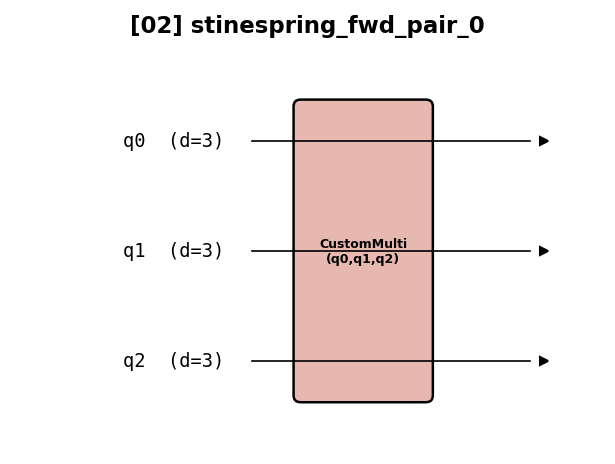


[03] stinespring_fwd_pair_1 -> circuit_images/scenario5_qudit_nb_03_stinespring_fwd_pair_1.png


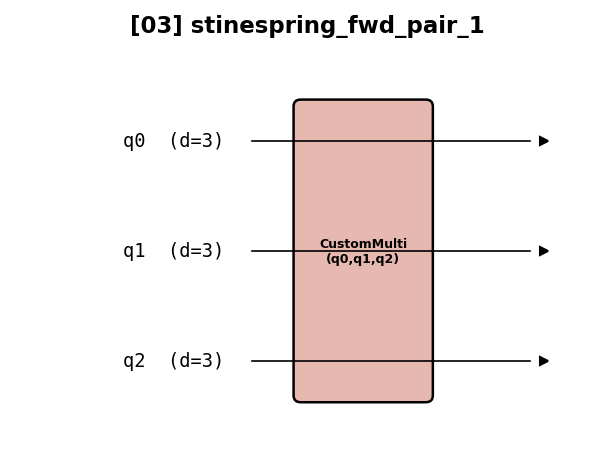


[04] stinespring_fwd_pair_2 -> circuit_images/scenario5_qudit_nb_04_stinespring_fwd_pair_2.png


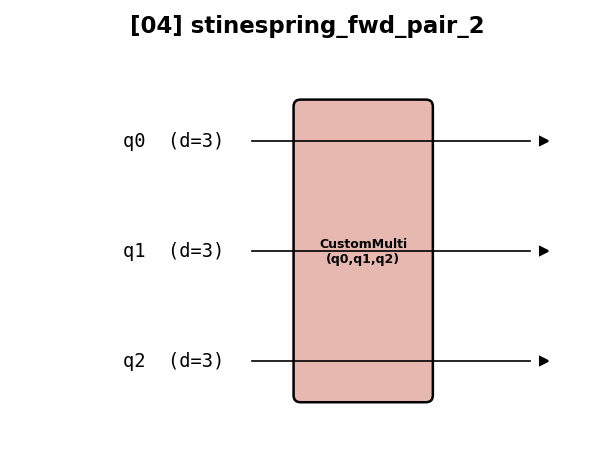


[05] stinespring_fwd_pair_3 -> circuit_images/scenario5_qudit_nb_05_stinespring_fwd_pair_3.png


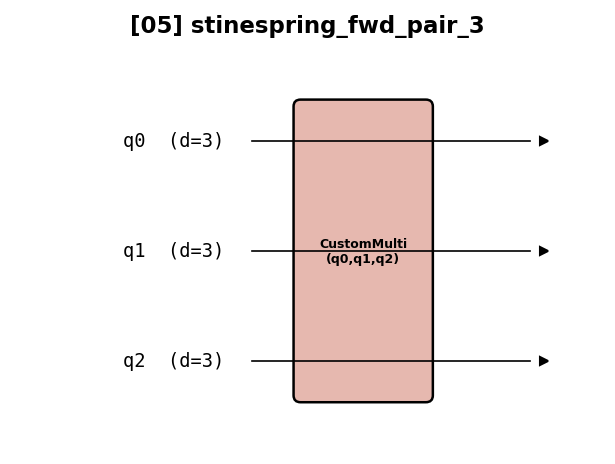


[06] stinespring_fwd_pair_4 -> circuit_images/scenario5_qudit_nb_06_stinespring_fwd_pair_4.png


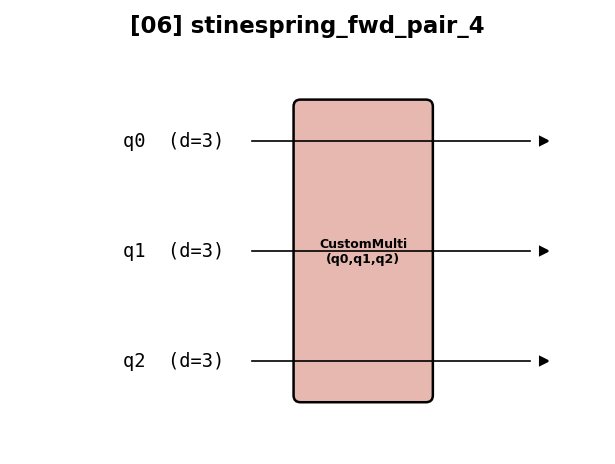


[07] stinespring_fwd_pair_5 -> circuit_images/scenario5_qudit_nb_07_stinespring_fwd_pair_5.png


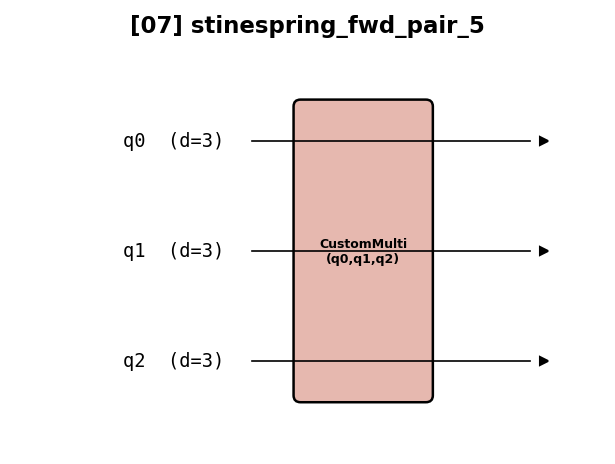


[08] stinespring_fwd_single_6 -> circuit_images/scenario5_qudit_nb_08_stinespring_fwd_single_6.png


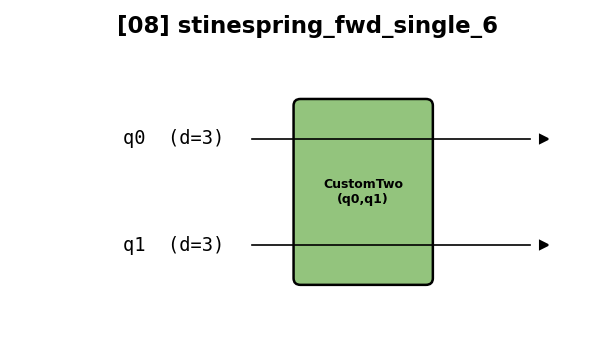


[09] stinespring_fwd_single_7 -> circuit_images/scenario5_qudit_nb_09_stinespring_fwd_single_7.png


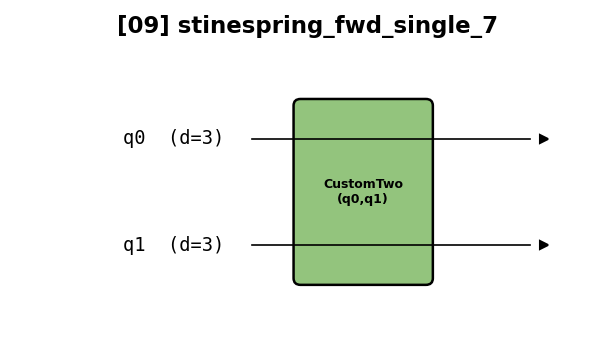


[10] stinespring_fwd_single_8 -> circuit_images/scenario5_qudit_nb_10_stinespring_fwd_single_8.png


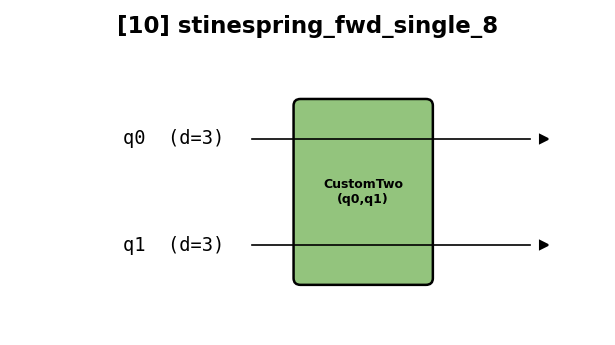


[11] stinespring_fwd_single_9 -> circuit_images/scenario5_qudit_nb_11_stinespring_fwd_single_9.png


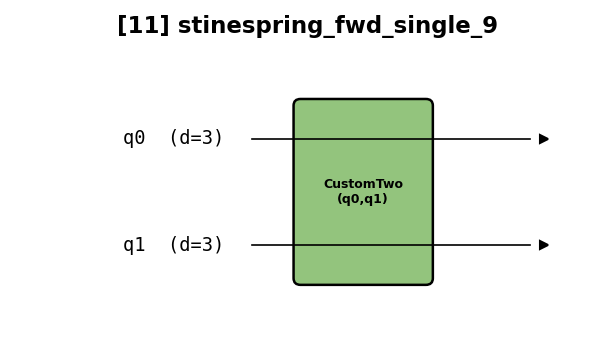


[12] stinespring_fwd_single_10 -> circuit_images/scenario5_qudit_nb_12_stinespring_fwd_single_10.png


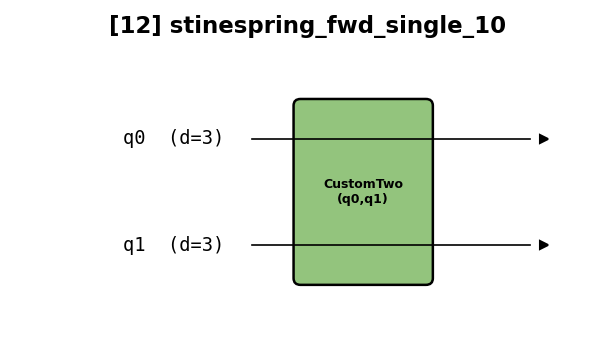


[13] stinespring_fwd_single_11 -> circuit_images/scenario5_qudit_nb_13_stinespring_fwd_single_11.png


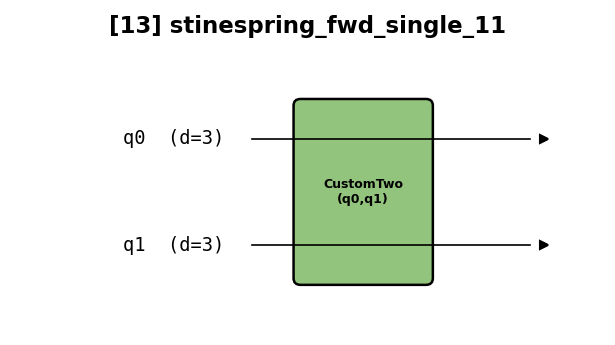


[14] stinespring_fwd_single_12 -> circuit_images/scenario5_qudit_nb_14_stinespring_fwd_single_12.png


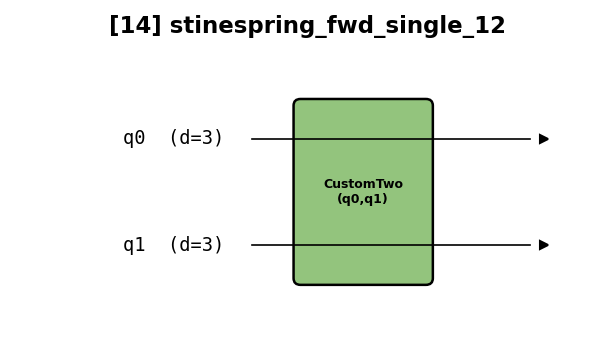


[15] stinespring_fwd_single_13 -> circuit_images/scenario5_qudit_nb_15_stinespring_fwd_single_13.png


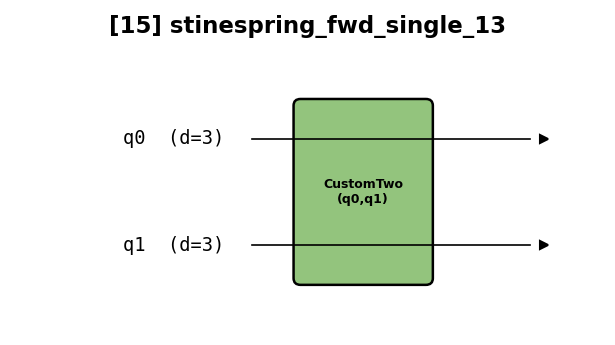


[16] stinespring_fwd_single_14 -> circuit_images/scenario5_qudit_nb_16_stinespring_fwd_single_14.png


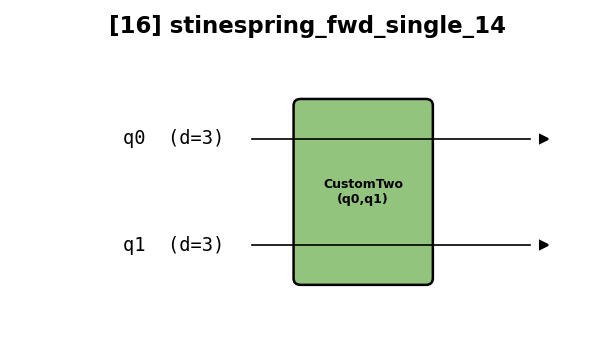


[17] stinespring_fwd_single_15 -> circuit_images/scenario5_qudit_nb_17_stinespring_fwd_single_15.png


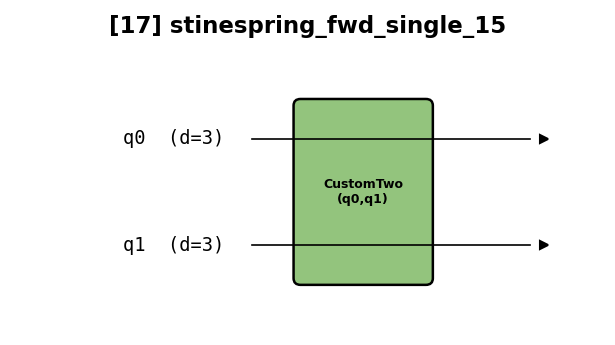


[18] stinespring_fwd_single_16 -> circuit_images/scenario5_qudit_nb_18_stinespring_fwd_single_16.png


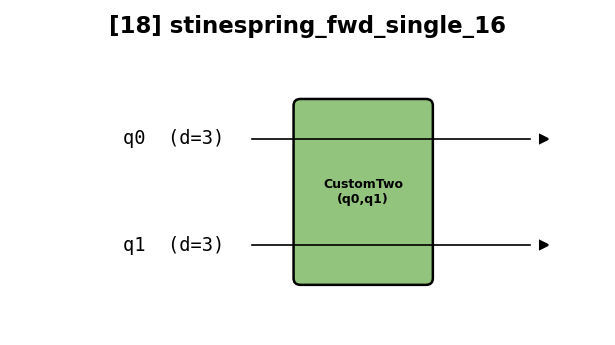


[19] stinespring_fwd_single_17 -> circuit_images/scenario5_qudit_nb_19_stinespring_fwd_single_17.png


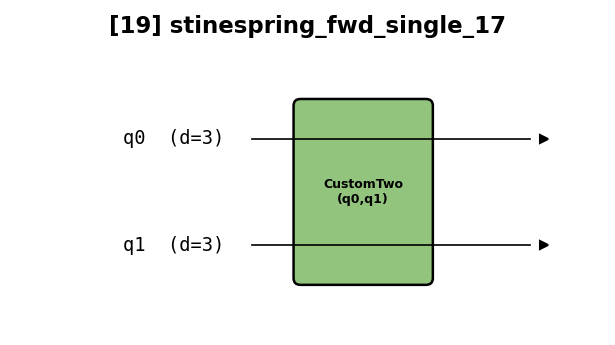


[20] stinespring_fwd_single_18 -> circuit_images/scenario5_qudit_nb_20_stinespring_fwd_single_18.png


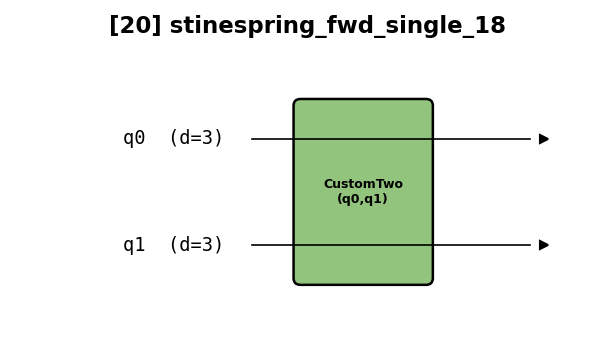


[21] stinespring_fwd_single_19 -> circuit_images/scenario5_qudit_nb_21_stinespring_fwd_single_19.png


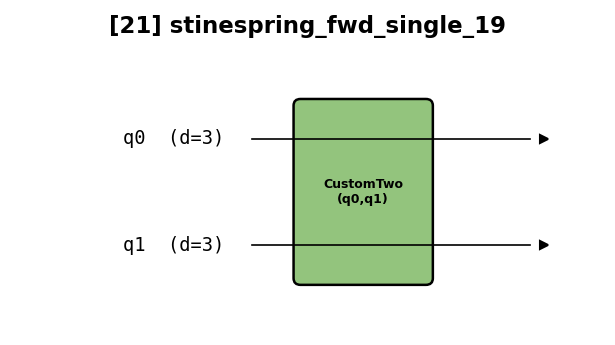


[22] stinespring_fwd_single_20 -> circuit_images/scenario5_qudit_nb_22_stinespring_fwd_single_20.png


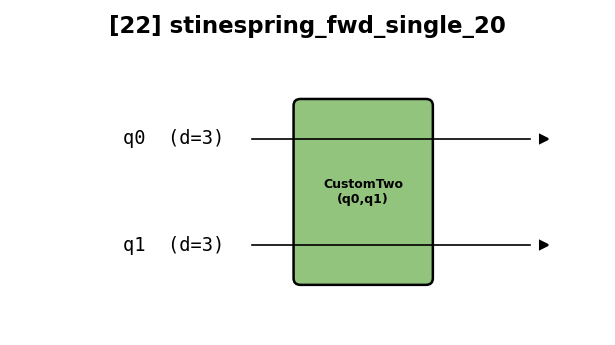


[23] stinespring_fwd_single_21 -> circuit_images/scenario5_qudit_nb_23_stinespring_fwd_single_21.png


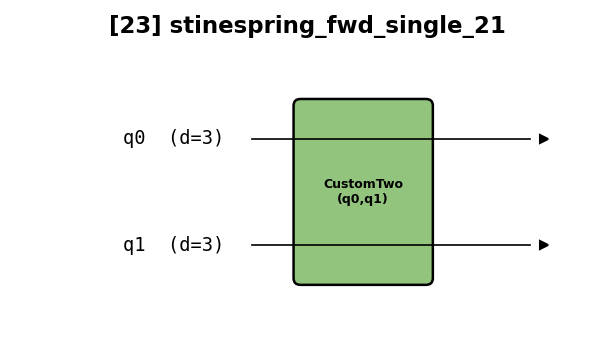


[24] stinespring_fwd_single_22 -> circuit_images/scenario5_qudit_nb_24_stinespring_fwd_single_22.png


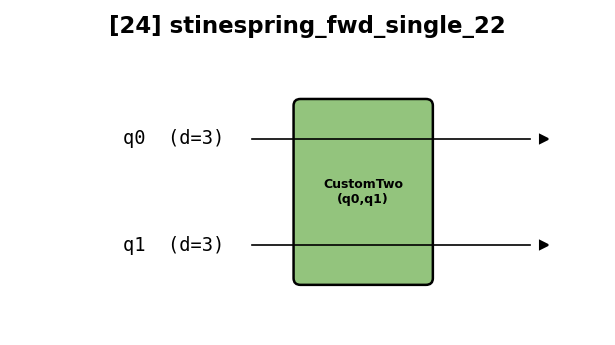


[25] stinespring_fwd_single_23 -> circuit_images/scenario5_qudit_nb_25_stinespring_fwd_single_23.png


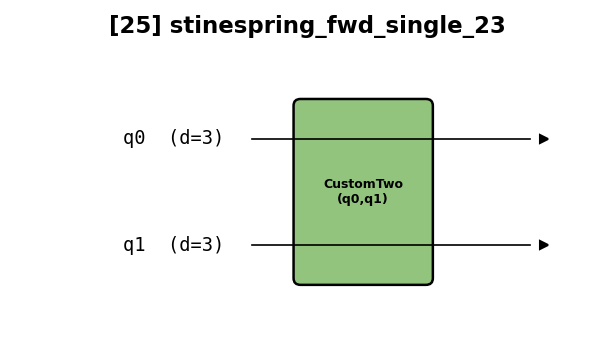


[26] stinespring_fwd_single_24 -> circuit_images/scenario5_qudit_nb_26_stinespring_fwd_single_24.png


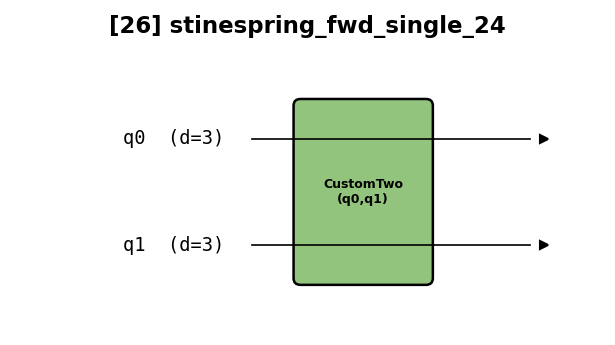


[27] stinespring_fwd_single_25 -> circuit_images/scenario5_qudit_nb_27_stinespring_fwd_single_25.png


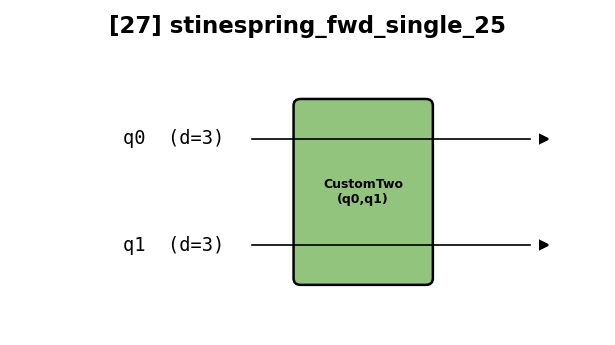


[28] stinespring_rev_single_25 -> circuit_images/scenario5_qudit_nb_28_stinespring_rev_single_25.png


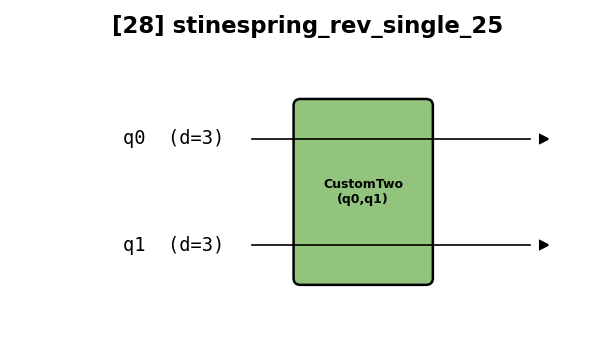


[29] stinespring_rev_single_24 -> circuit_images/scenario5_qudit_nb_29_stinespring_rev_single_24.png


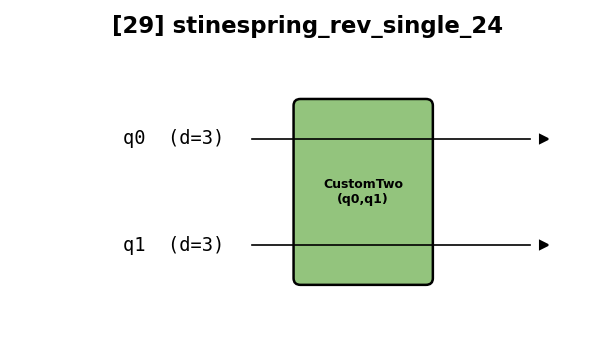


[30] stinespring_rev_single_23 -> circuit_images/scenario5_qudit_nb_30_stinespring_rev_single_23.png


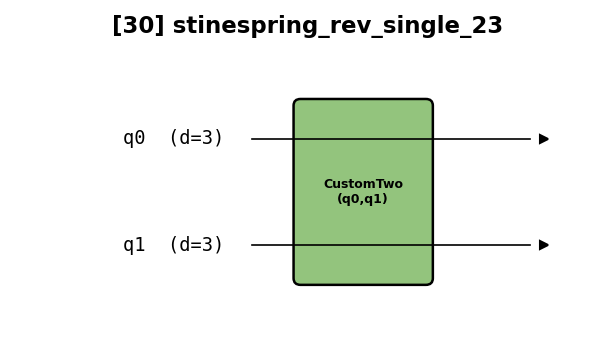


[31] stinespring_rev_single_22 -> circuit_images/scenario5_qudit_nb_31_stinespring_rev_single_22.png


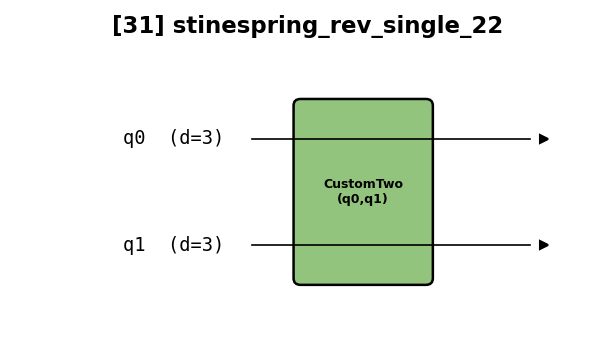


[32] stinespring_rev_single_21 -> circuit_images/scenario5_qudit_nb_32_stinespring_rev_single_21.png


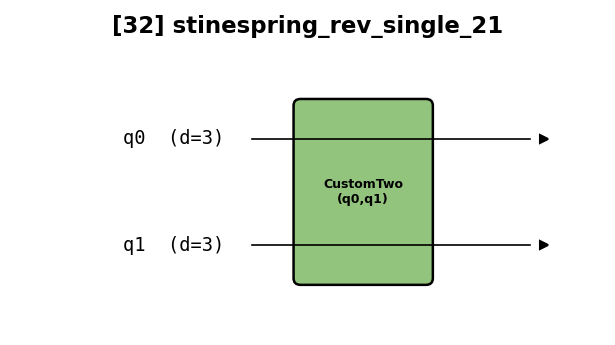


[33] stinespring_rev_single_20 -> circuit_images/scenario5_qudit_nb_33_stinespring_rev_single_20.png


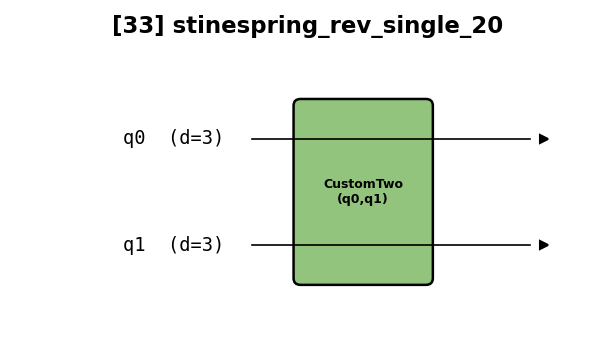


[34] stinespring_rev_single_19 -> circuit_images/scenario5_qudit_nb_34_stinespring_rev_single_19.png


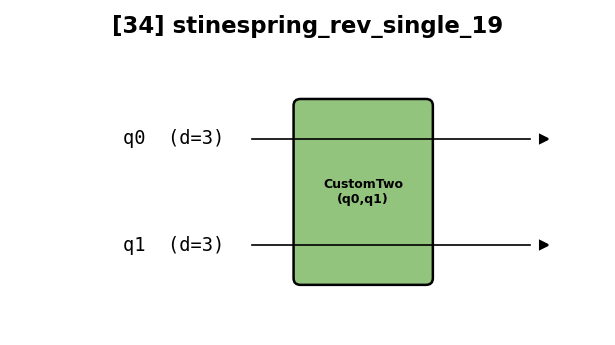


[35] stinespring_rev_single_18 -> circuit_images/scenario5_qudit_nb_35_stinespring_rev_single_18.png


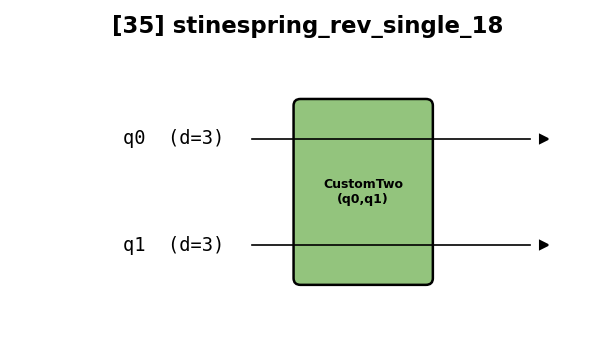


[36] stinespring_rev_single_17 -> circuit_images/scenario5_qudit_nb_36_stinespring_rev_single_17.png


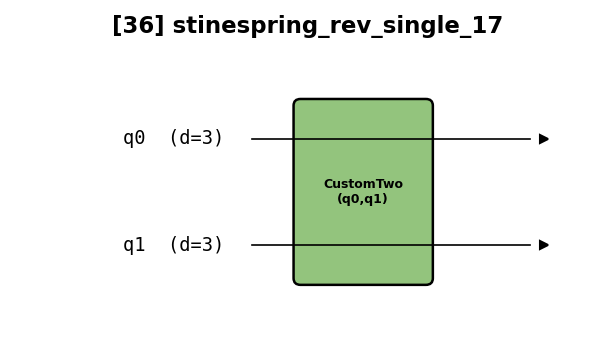


[37] stinespring_rev_single_16 -> circuit_images/scenario5_qudit_nb_37_stinespring_rev_single_16.png


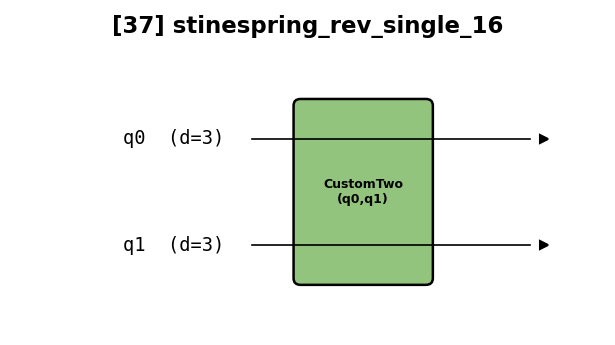


[38] stinespring_rev_single_15 -> circuit_images/scenario5_qudit_nb_38_stinespring_rev_single_15.png


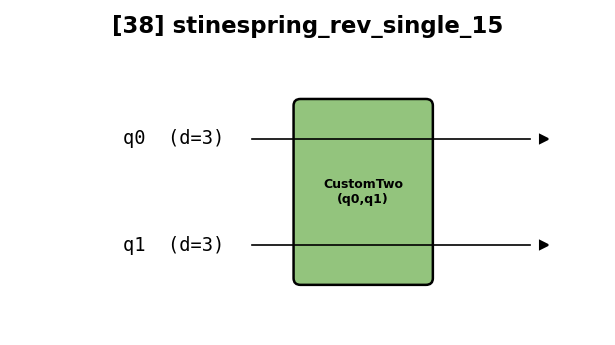


[39] stinespring_rev_single_14 -> circuit_images/scenario5_qudit_nb_39_stinespring_rev_single_14.png


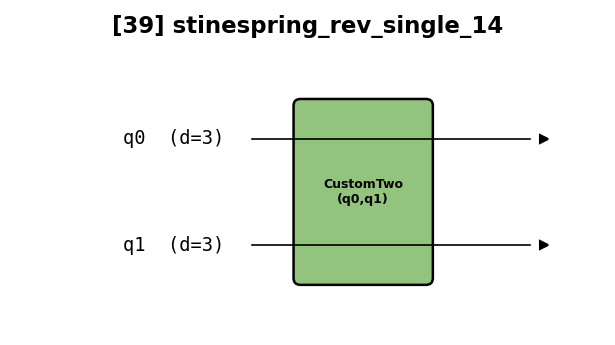


[40] stinespring_rev_single_13 -> circuit_images/scenario5_qudit_nb_40_stinespring_rev_single_13.png


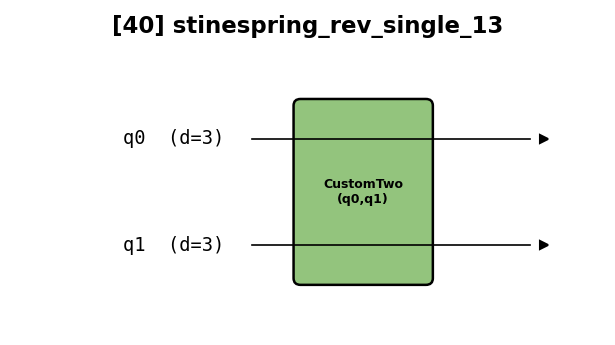


[41] stinespring_rev_single_12 -> circuit_images/scenario5_qudit_nb_41_stinespring_rev_single_12.png


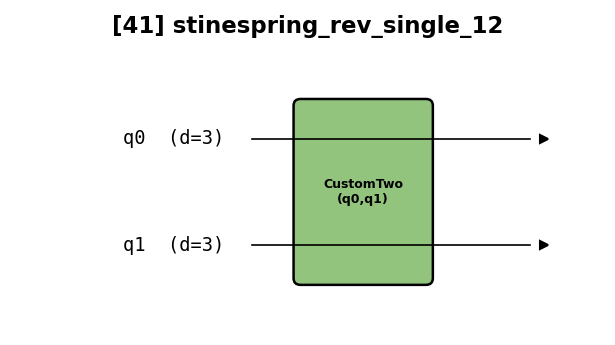


[42] stinespring_rev_single_11 -> circuit_images/scenario5_qudit_nb_42_stinespring_rev_single_11.png


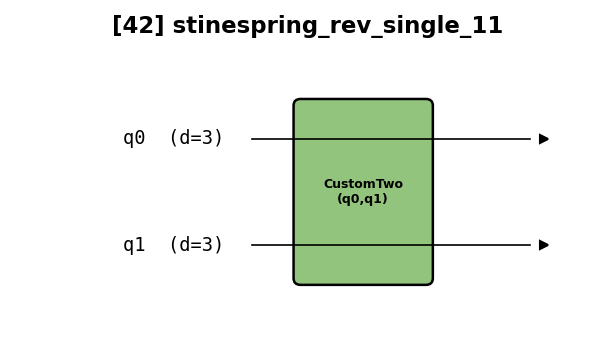


[43] stinespring_rev_single_10 -> circuit_images/scenario5_qudit_nb_43_stinespring_rev_single_10.png


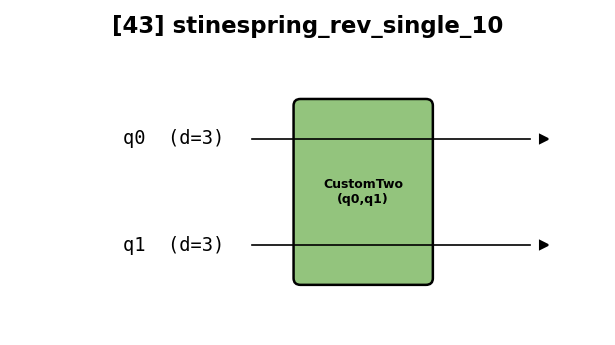


[44] stinespring_rev_single_9 -> circuit_images/scenario5_qudit_nb_44_stinespring_rev_single_9.png


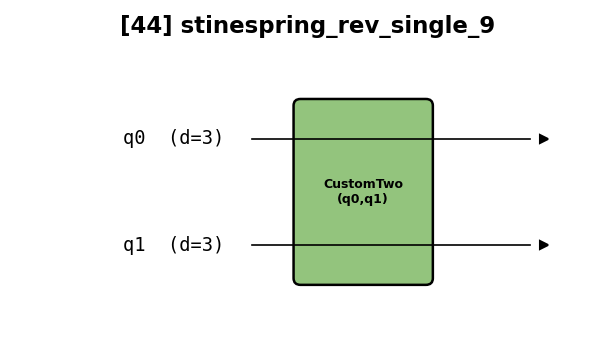


[45] stinespring_rev_single_8 -> circuit_images/scenario5_qudit_nb_45_stinespring_rev_single_8.png


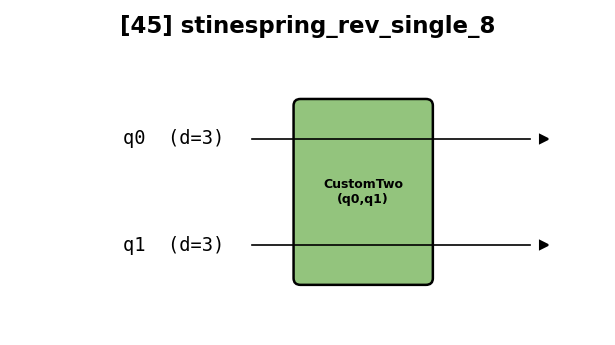


[46] stinespring_rev_single_7 -> circuit_images/scenario5_qudit_nb_46_stinespring_rev_single_7.png


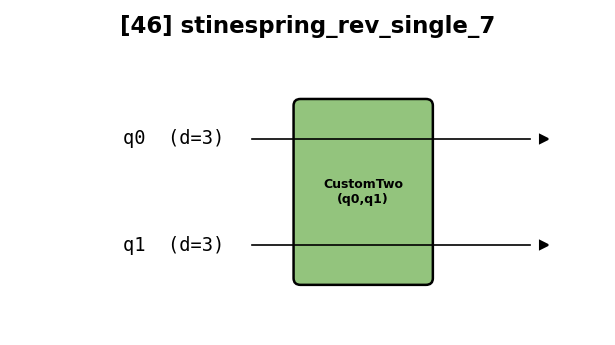


[47] stinespring_rev_single_6 -> circuit_images/scenario5_qudit_nb_47_stinespring_rev_single_6.png


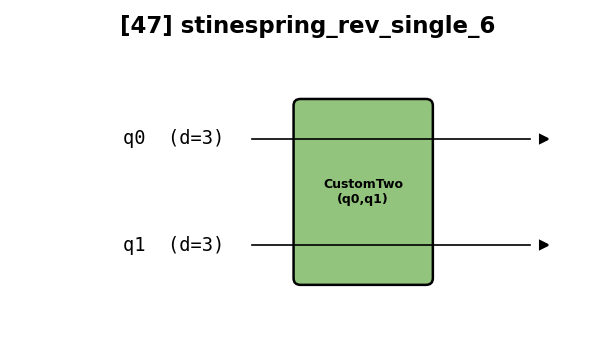


[48] stinespring_rev_pair_5 -> circuit_images/scenario5_qudit_nb_48_stinespring_rev_pair_5.png


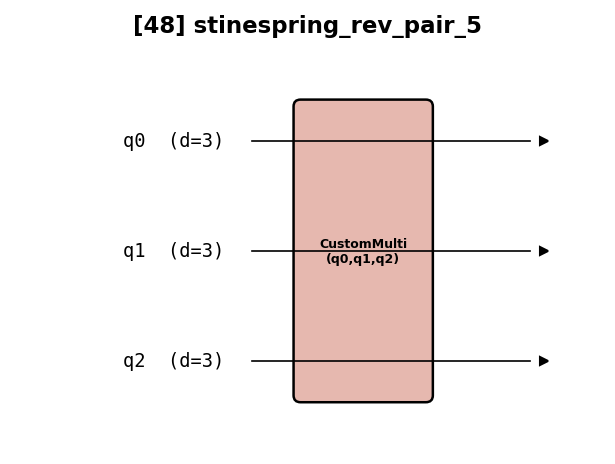


[49] stinespring_rev_pair_4 -> circuit_images/scenario5_qudit_nb_49_stinespring_rev_pair_4.png


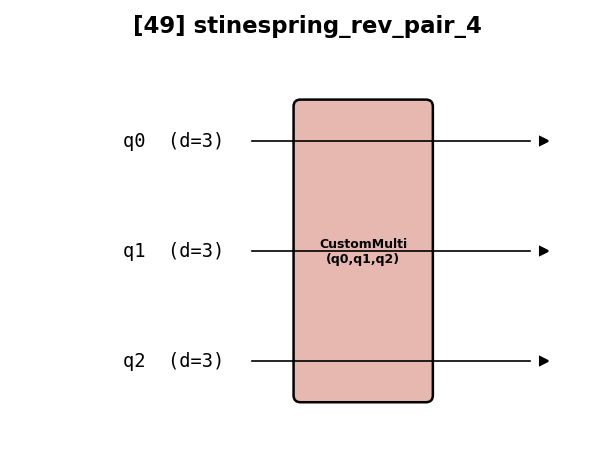


[50] stinespring_rev_pair_3 -> circuit_images/scenario5_qudit_nb_50_stinespring_rev_pair_3.png


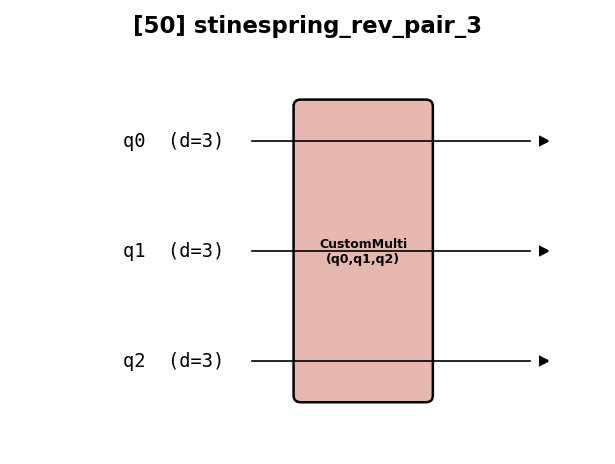


[51] stinespring_rev_pair_2 -> circuit_images/scenario5_qudit_nb_51_stinespring_rev_pair_2.png


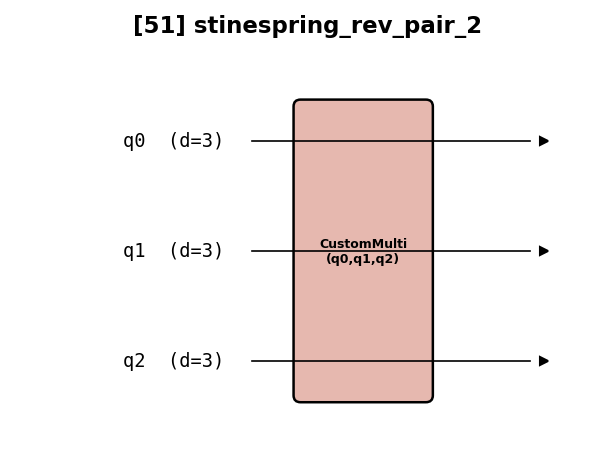


[52] stinespring_rev_pair_1 -> circuit_images/scenario5_qudit_nb_52_stinespring_rev_pair_1.png


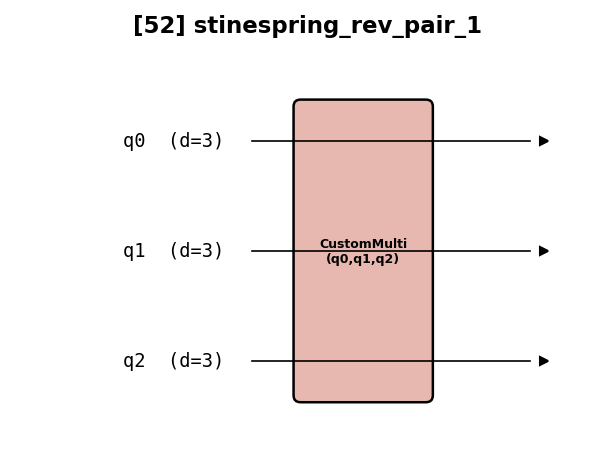


[53] stinespring_rev_pair_0 -> circuit_images/scenario5_qudit_nb_53_stinespring_rev_pair_0.png


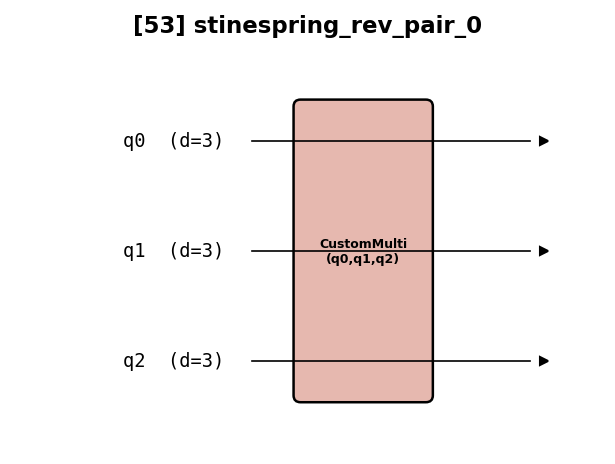


[54] hamiltonian_half_2 -> circuit_images/scenario5_qudit_nb_54_hamiltonian_half_2.png


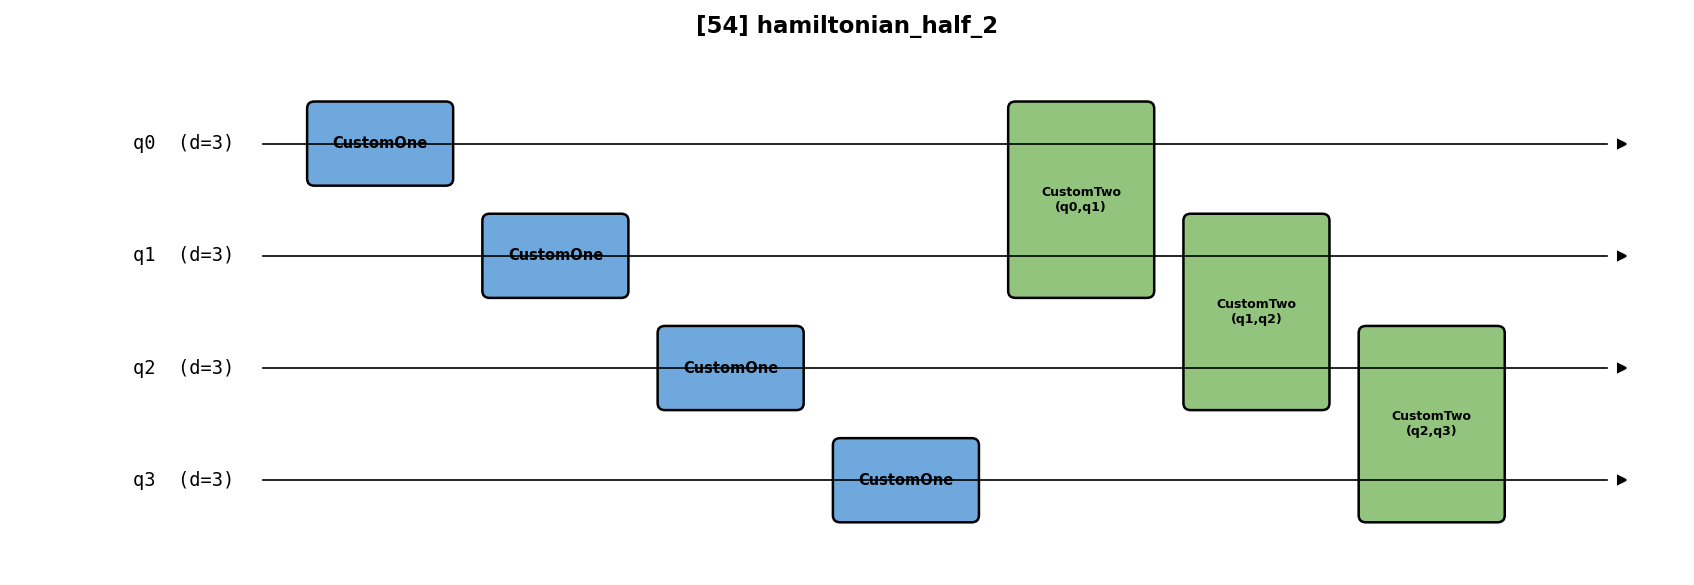


Scenario 6: Qudit GKSL (With Boson) - 1 Trotter Step
subcircuits: 26

[01] hamiltonian_half_1 -> circuit_images/scenario6_qudit_b_01_hamiltonian_half_1.png


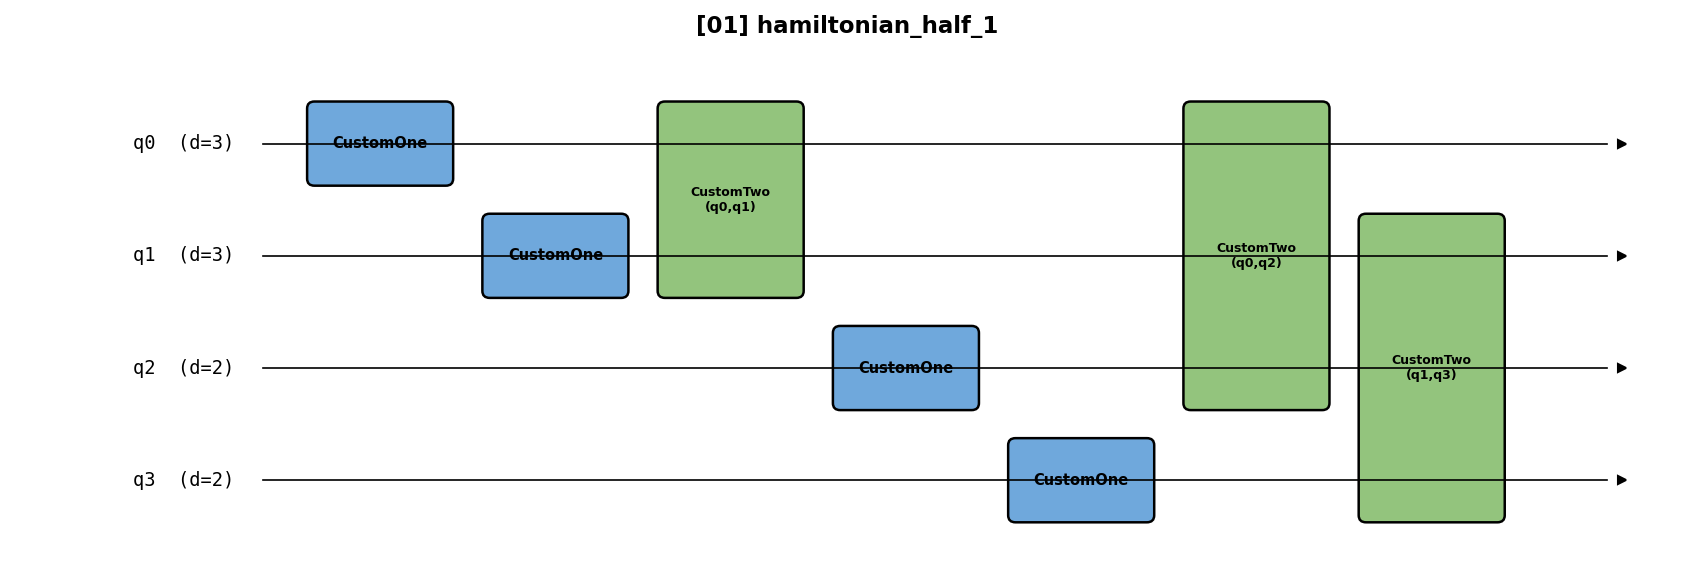


[02] stinespring_fwd_pair_0 -> circuit_images/scenario6_qudit_b_02_stinespring_fwd_pair_0.png


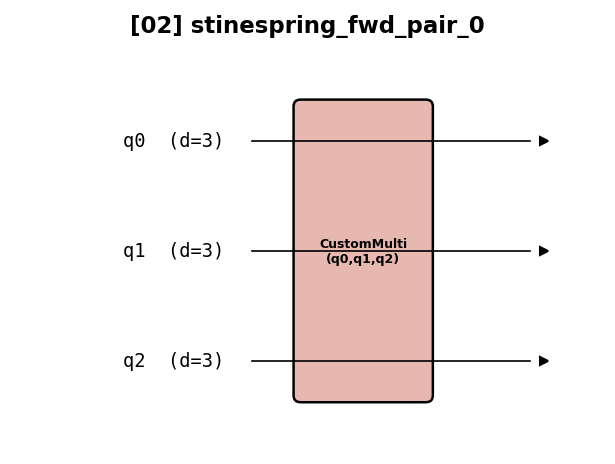


[03] stinespring_fwd_pair_1 -> circuit_images/scenario6_qudit_b_03_stinespring_fwd_pair_1.png


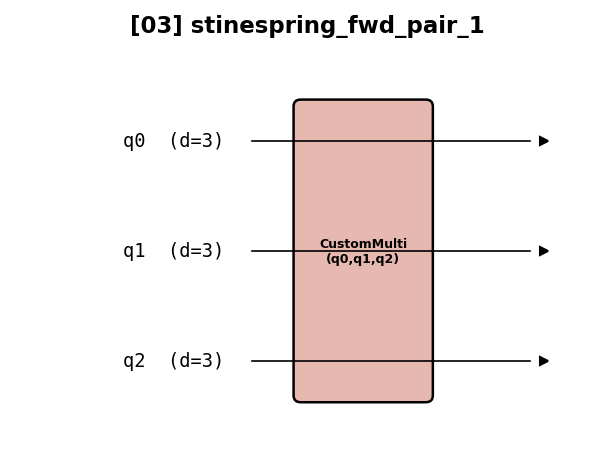


[04] stinespring_fwd_single_2 -> circuit_images/scenario6_qudit_b_04_stinespring_fwd_single_2.png


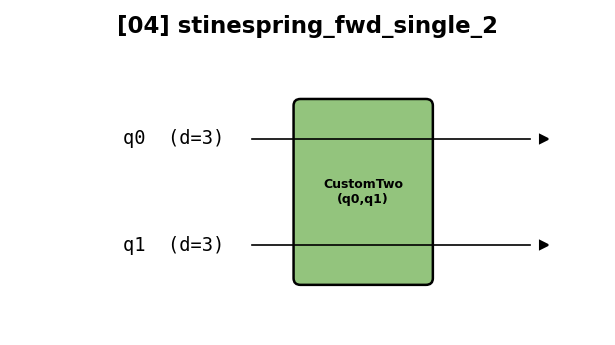


[05] stinespring_fwd_single_3 -> circuit_images/scenario6_qudit_b_05_stinespring_fwd_single_3.png


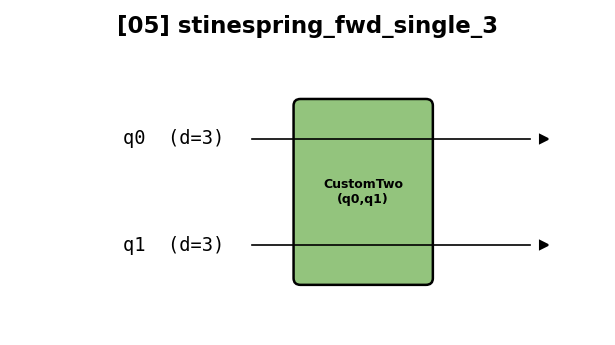


[06] stinespring_fwd_single_4 -> circuit_images/scenario6_qudit_b_06_stinespring_fwd_single_4.png


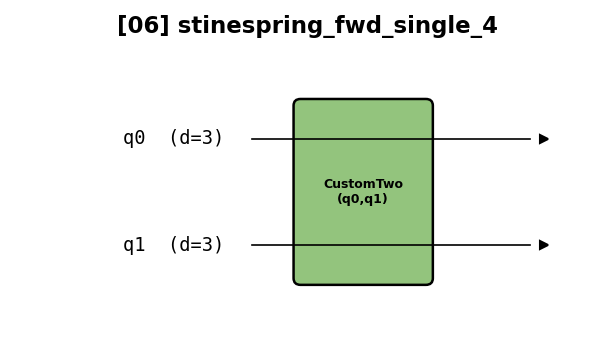


[07] stinespring_fwd_single_5 -> circuit_images/scenario6_qudit_b_07_stinespring_fwd_single_5.png


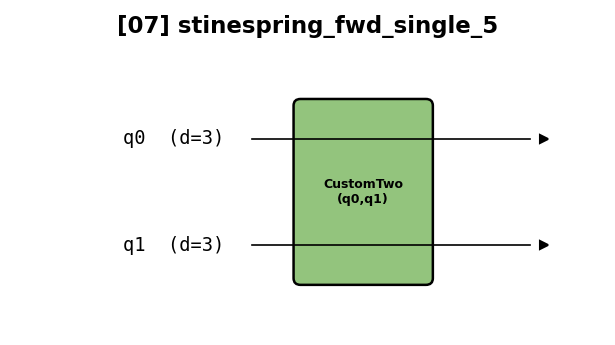


[08] stinespring_fwd_single_6 -> circuit_images/scenario6_qudit_b_08_stinespring_fwd_single_6.png


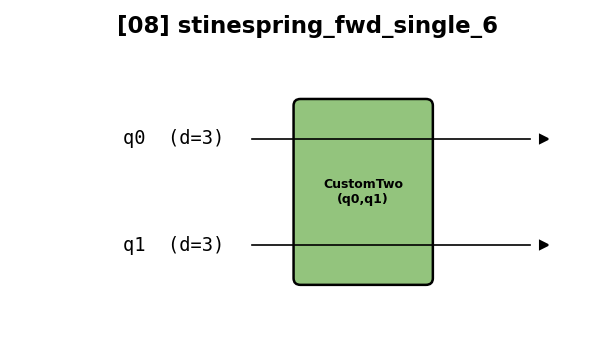


[09] stinespring_fwd_single_7 -> circuit_images/scenario6_qudit_b_09_stinespring_fwd_single_7.png


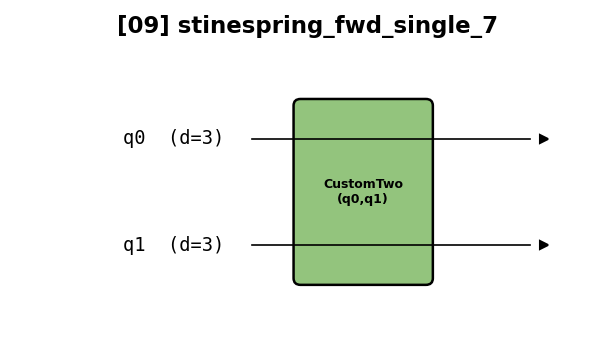


[10] stinespring_fwd_single_8 -> circuit_images/scenario6_qudit_b_10_stinespring_fwd_single_8.png


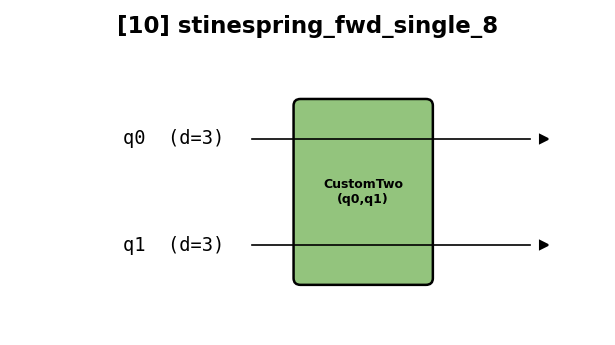


[11] stinespring_fwd_single_9 -> circuit_images/scenario6_qudit_b_11_stinespring_fwd_single_9.png


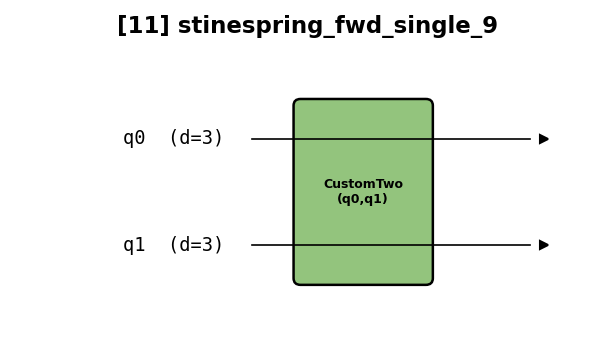


[12] stinespring_fwd_single_10 -> circuit_images/scenario6_qudit_b_12_stinespring_fwd_single_10.png


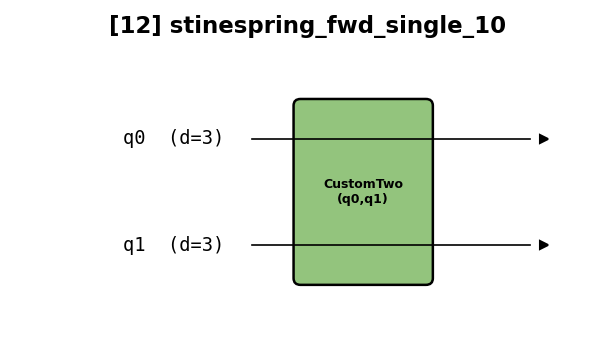


[13] stinespring_fwd_single_11 -> circuit_images/scenario6_qudit_b_13_stinespring_fwd_single_11.png


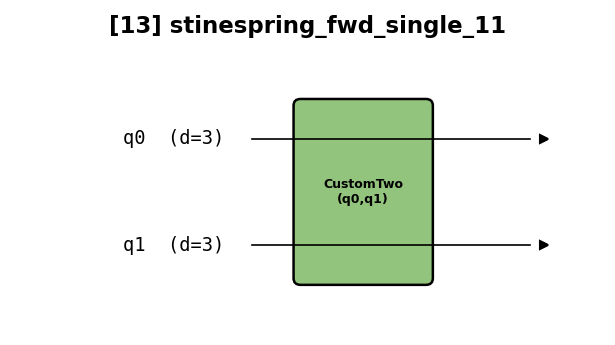


[14] stinespring_rev_single_11 -> circuit_images/scenario6_qudit_b_14_stinespring_rev_single_11.png


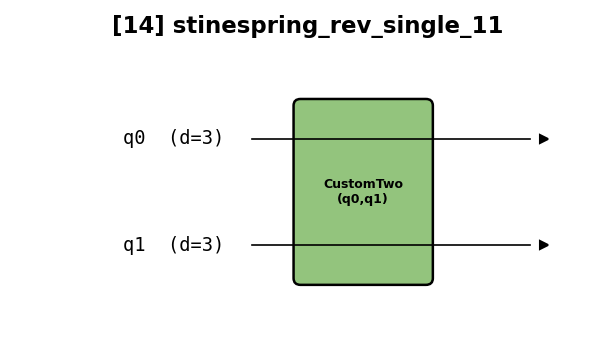


[15] stinespring_rev_single_10 -> circuit_images/scenario6_qudit_b_15_stinespring_rev_single_10.png


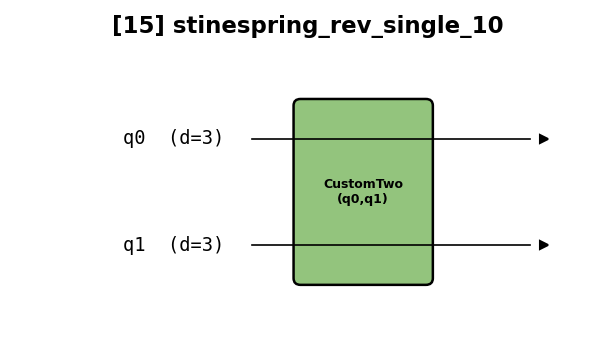


[16] stinespring_rev_single_9 -> circuit_images/scenario6_qudit_b_16_stinespring_rev_single_9.png


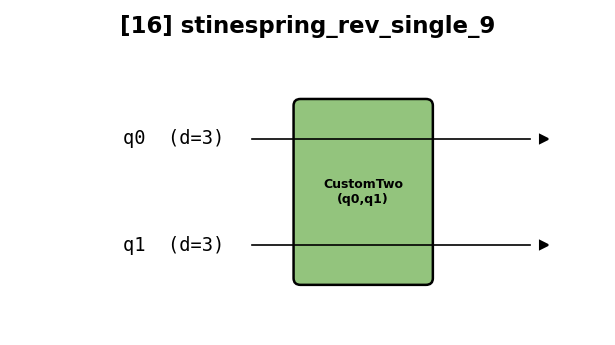


[17] stinespring_rev_single_8 -> circuit_images/scenario6_qudit_b_17_stinespring_rev_single_8.png


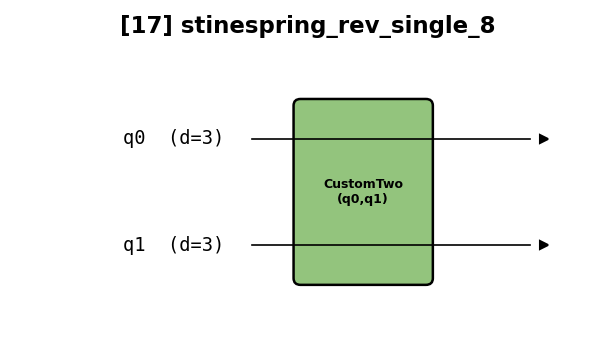


[18] stinespring_rev_single_7 -> circuit_images/scenario6_qudit_b_18_stinespring_rev_single_7.png


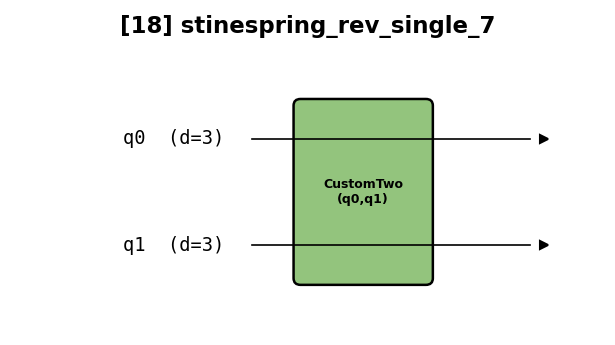


[19] stinespring_rev_single_6 -> circuit_images/scenario6_qudit_b_19_stinespring_rev_single_6.png


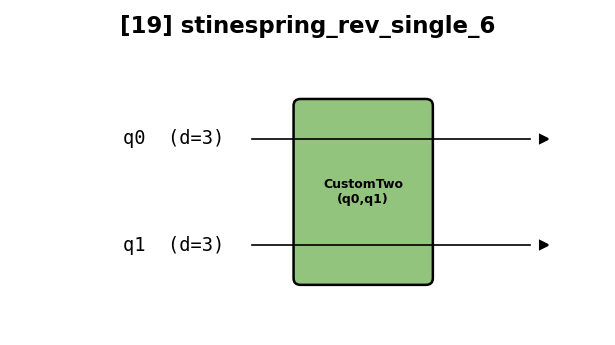


[20] stinespring_rev_single_5 -> circuit_images/scenario6_qudit_b_20_stinespring_rev_single_5.png


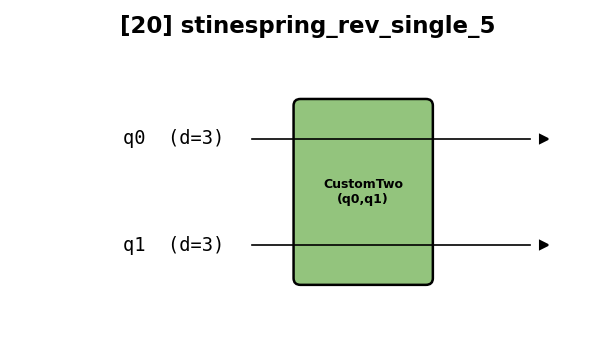


[21] stinespring_rev_single_4 -> circuit_images/scenario6_qudit_b_21_stinespring_rev_single_4.png


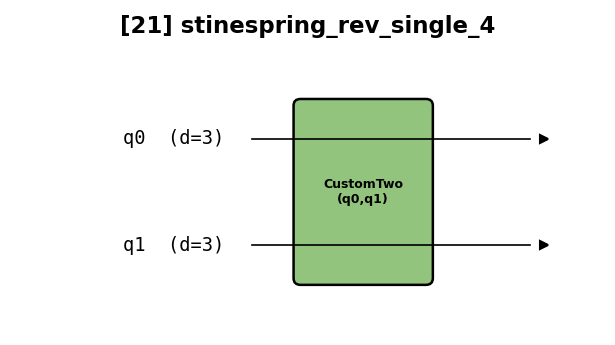


[22] stinespring_rev_single_3 -> circuit_images/scenario6_qudit_b_22_stinespring_rev_single_3.png


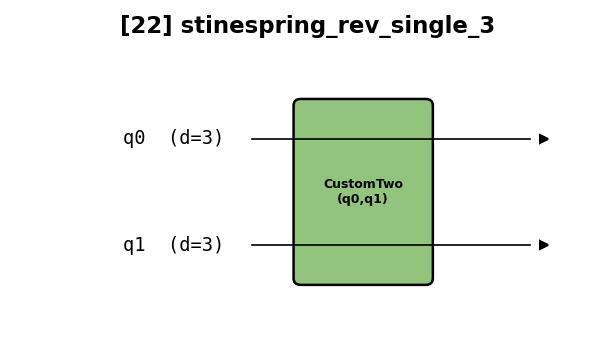


[23] stinespring_rev_single_2 -> circuit_images/scenario6_qudit_b_23_stinespring_rev_single_2.png


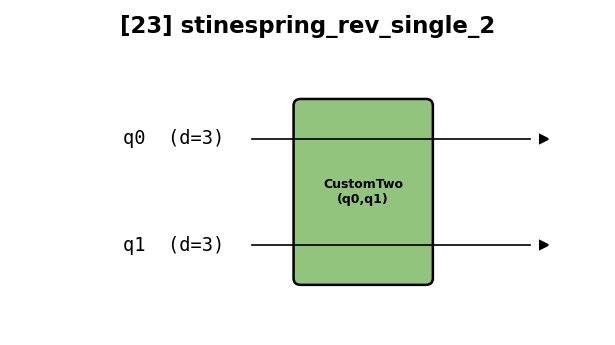


[24] stinespring_rev_pair_1 -> circuit_images/scenario6_qudit_b_24_stinespring_rev_pair_1.png


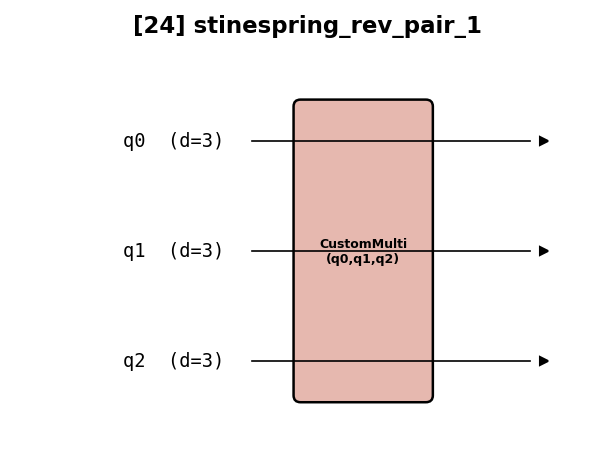


[25] stinespring_rev_pair_0 -> circuit_images/scenario6_qudit_b_25_stinespring_rev_pair_0.png


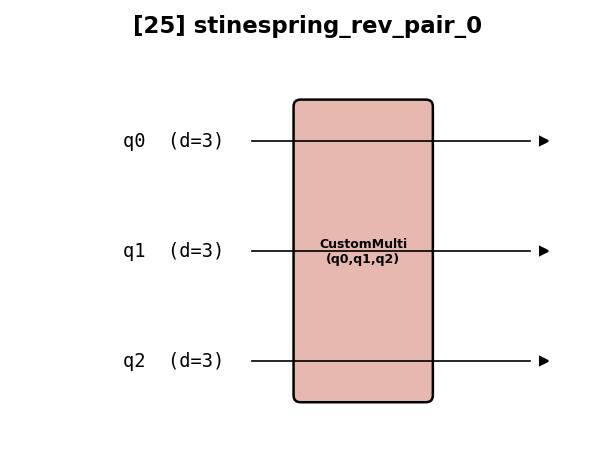


[26] hamiltonian_half_2 -> circuit_images/scenario6_qudit_b_26_hamiltonian_half_2.png


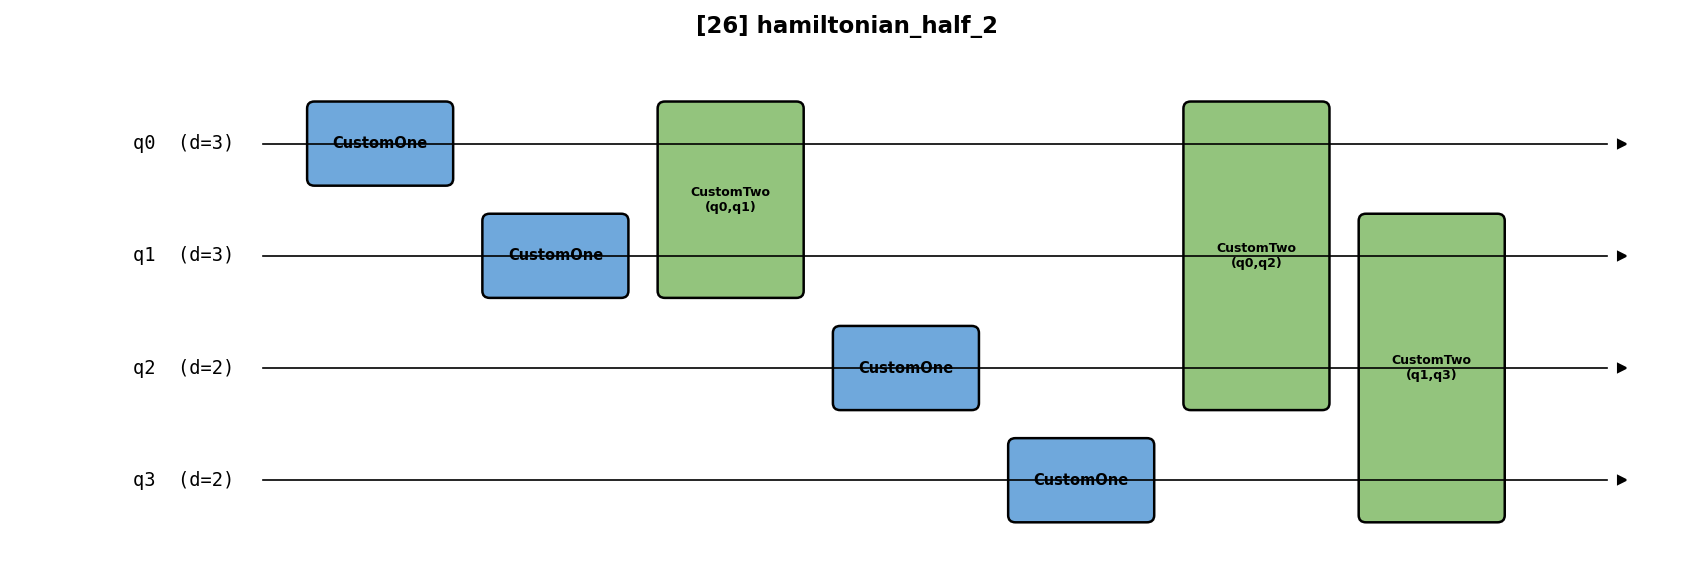


Scenario 4: Qubit GKSL (With Boson) - 1 Trotter Step
subcircuits: 26

[01] hamiltonian_half_1 -> circuit_images/scenario4_qubit_b_01_hamiltonian_half_1.png


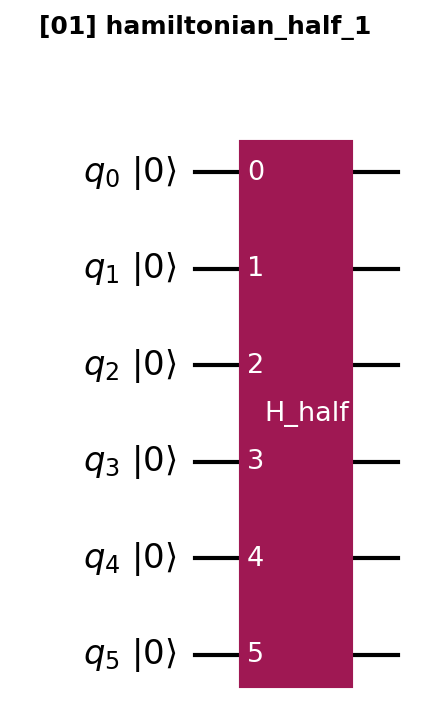


[02] stinespring_fwd_0 -> circuit_images/scenario4_qubit_b_02_stinespring_fwd_0.png


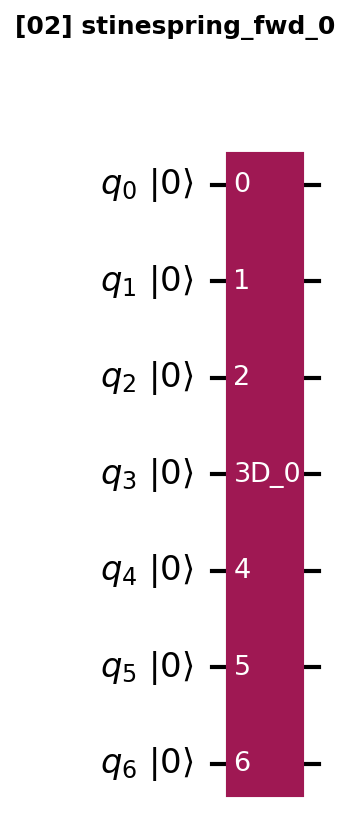


[03] stinespring_fwd_1 -> circuit_images/scenario4_qubit_b_03_stinespring_fwd_1.png


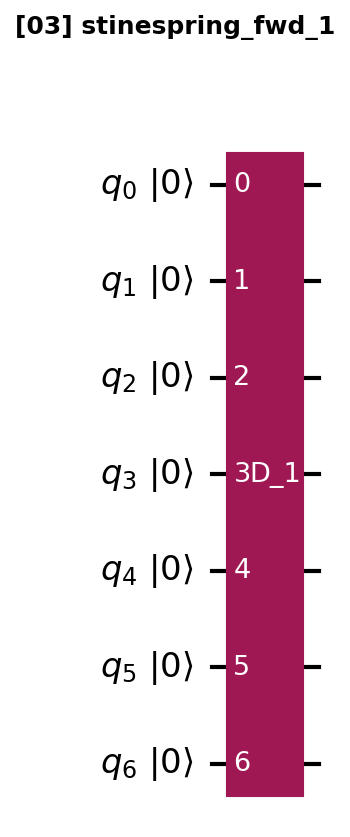


[04] stinespring_fwd_2 -> circuit_images/scenario4_qubit_b_04_stinespring_fwd_2.png


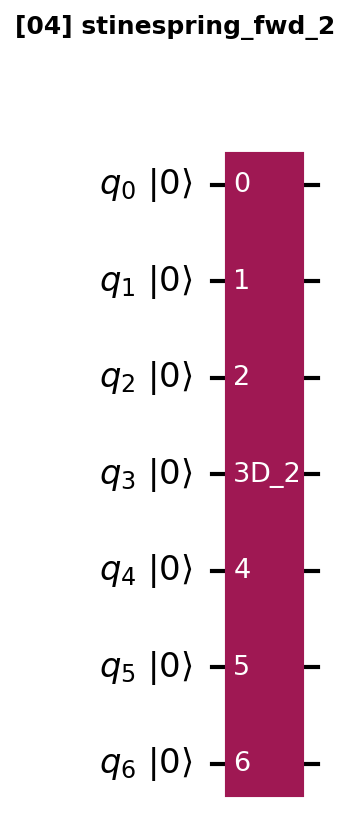


[05] stinespring_fwd_3 -> circuit_images/scenario4_qubit_b_05_stinespring_fwd_3.png


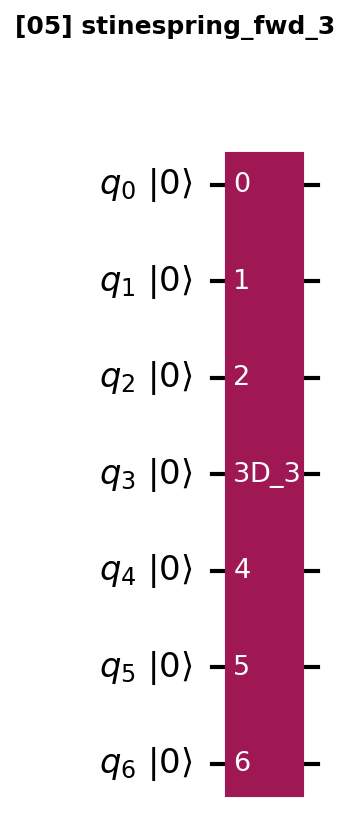


[06] stinespring_fwd_4 -> circuit_images/scenario4_qubit_b_06_stinespring_fwd_4.png


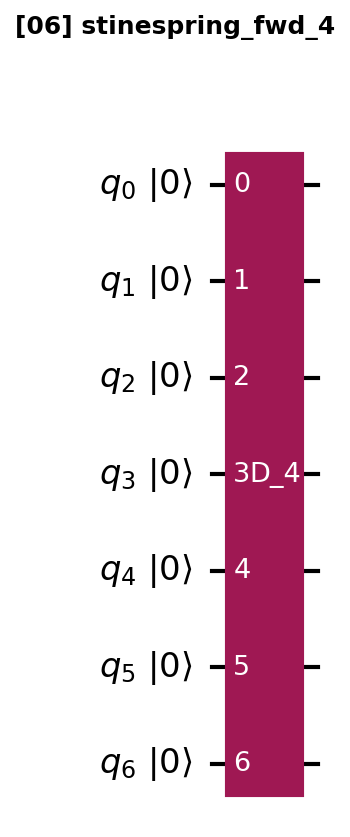


[07] stinespring_fwd_5 -> circuit_images/scenario4_qubit_b_07_stinespring_fwd_5.png


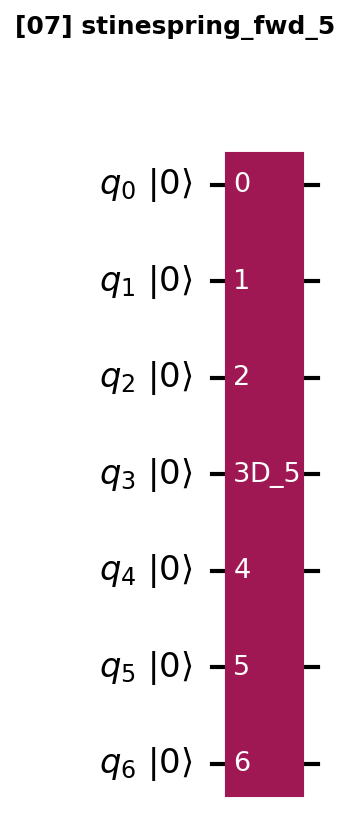


[08] stinespring_fwd_6 -> circuit_images/scenario4_qubit_b_08_stinespring_fwd_6.png


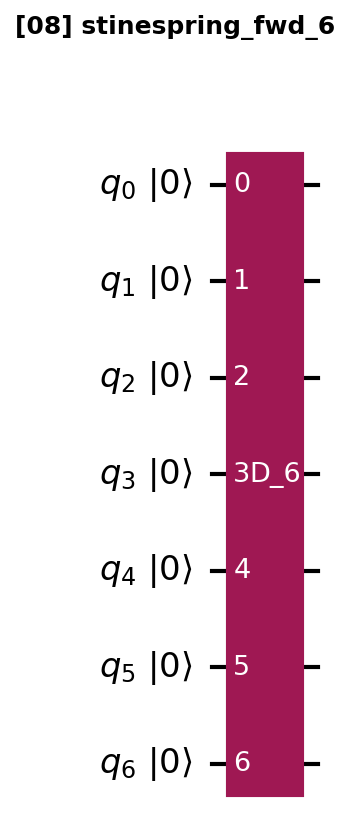


[09] stinespring_fwd_7 -> circuit_images/scenario4_qubit_b_09_stinespring_fwd_7.png


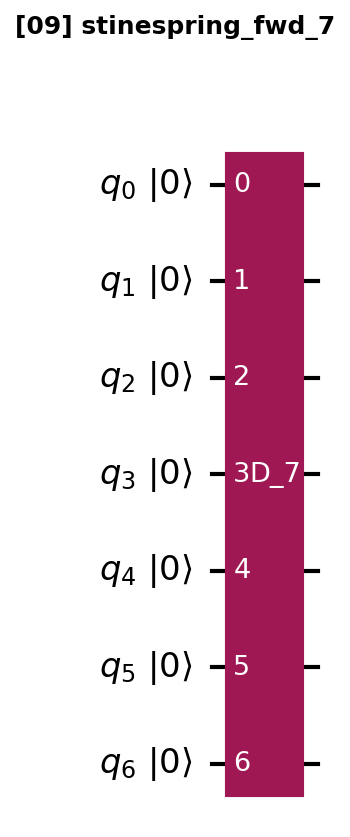


[10] stinespring_fwd_8 -> circuit_images/scenario4_qubit_b_10_stinespring_fwd_8.png


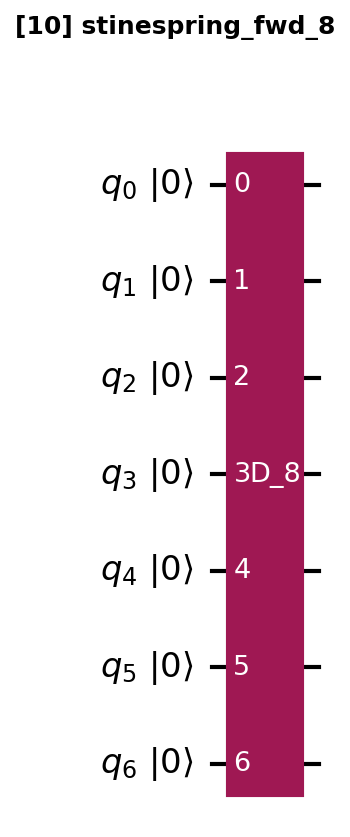


[11] stinespring_fwd_9 -> circuit_images/scenario4_qubit_b_11_stinespring_fwd_9.png


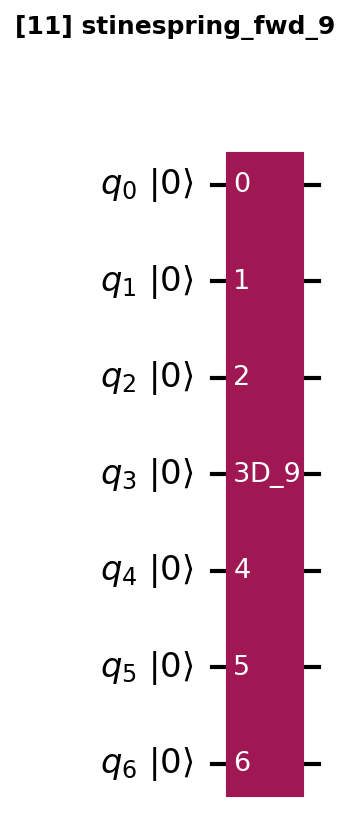


[12] stinespring_fwd_10 -> circuit_images/scenario4_qubit_b_12_stinespring_fwd_10.png


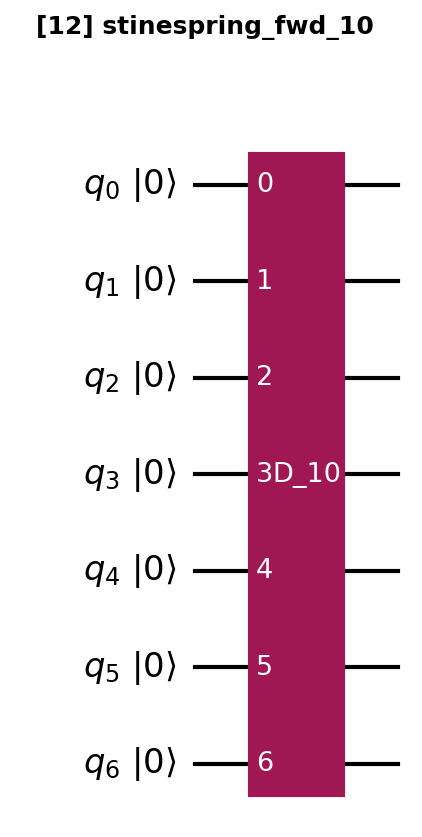


[13] stinespring_fwd_11 -> circuit_images/scenario4_qubit_b_13_stinespring_fwd_11.png


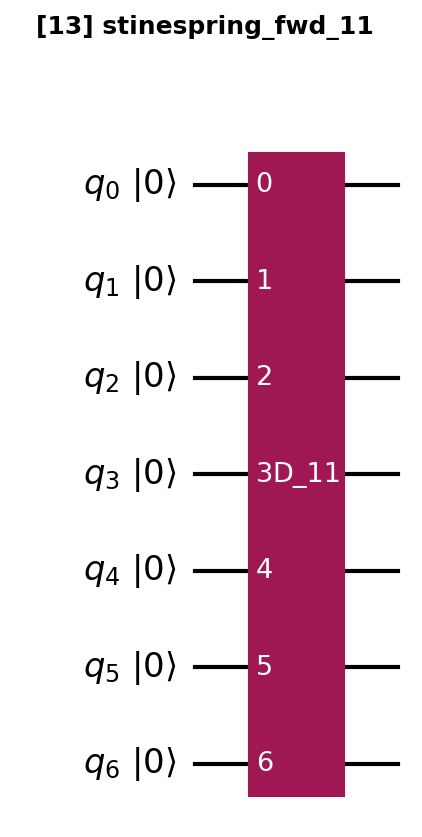


[14] stinespring_rev_11 -> circuit_images/scenario4_qubit_b_14_stinespring_rev_11.png


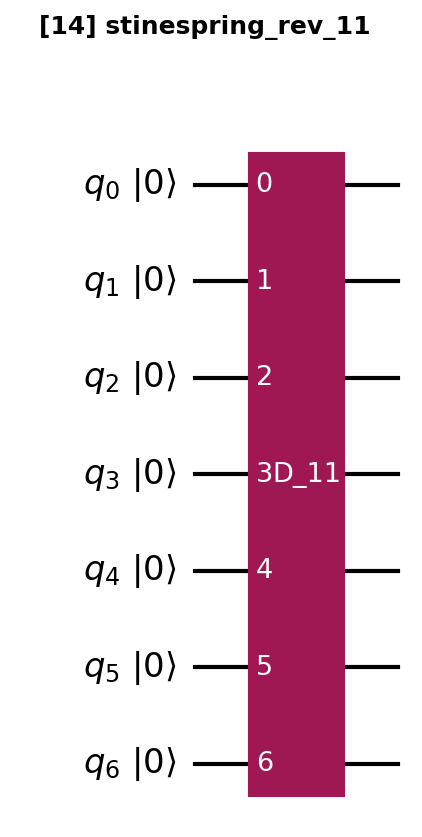


[15] stinespring_rev_10 -> circuit_images/scenario4_qubit_b_15_stinespring_rev_10.png


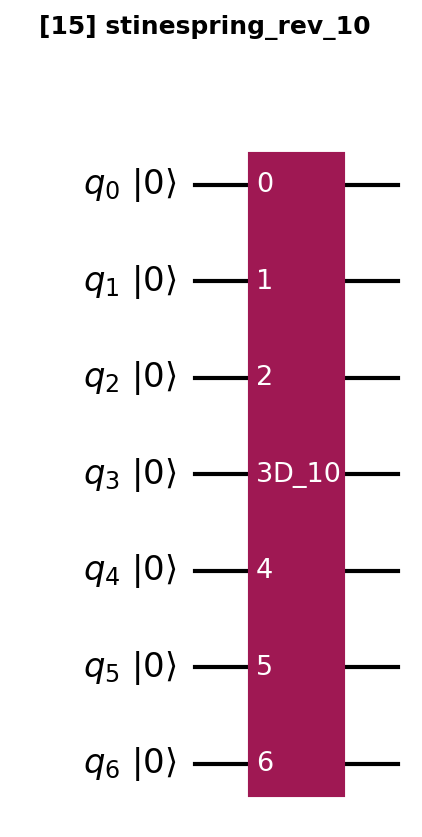


[16] stinespring_rev_9 -> circuit_images/scenario4_qubit_b_16_stinespring_rev_9.png


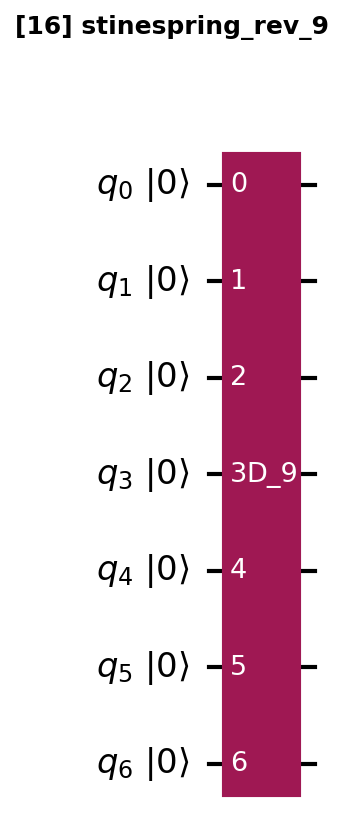


[17] stinespring_rev_8 -> circuit_images/scenario4_qubit_b_17_stinespring_rev_8.png


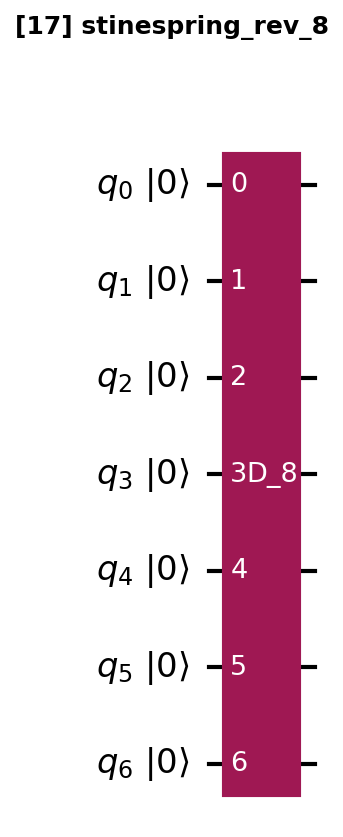


[18] stinespring_rev_7 -> circuit_images/scenario4_qubit_b_18_stinespring_rev_7.png


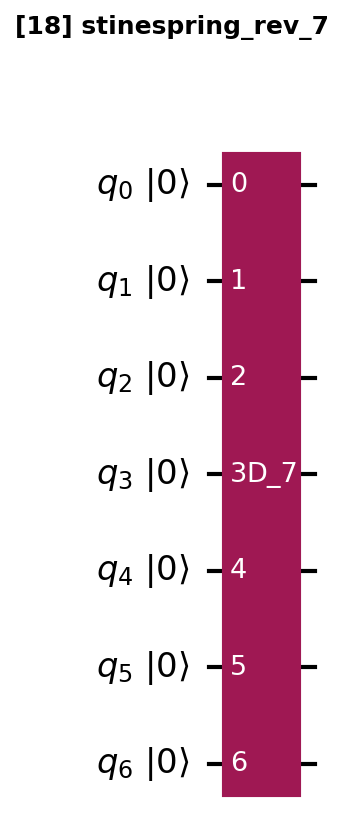


[19] stinespring_rev_6 -> circuit_images/scenario4_qubit_b_19_stinespring_rev_6.png


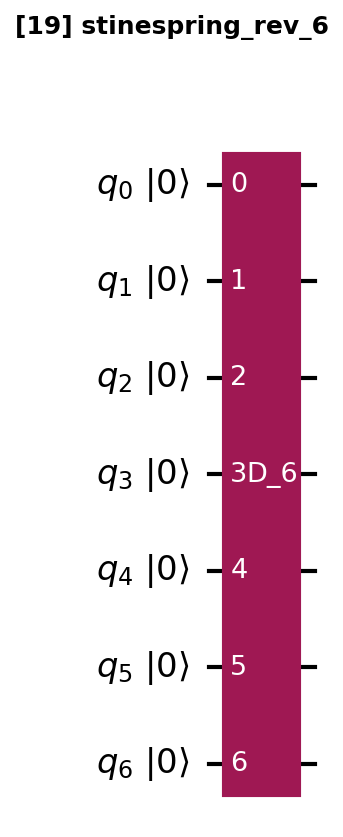


[20] stinespring_rev_5 -> circuit_images/scenario4_qubit_b_20_stinespring_rev_5.png


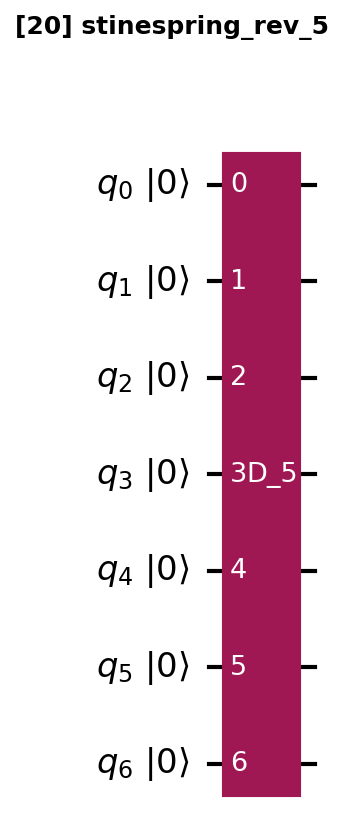


[21] stinespring_rev_4 -> circuit_images/scenario4_qubit_b_21_stinespring_rev_4.png


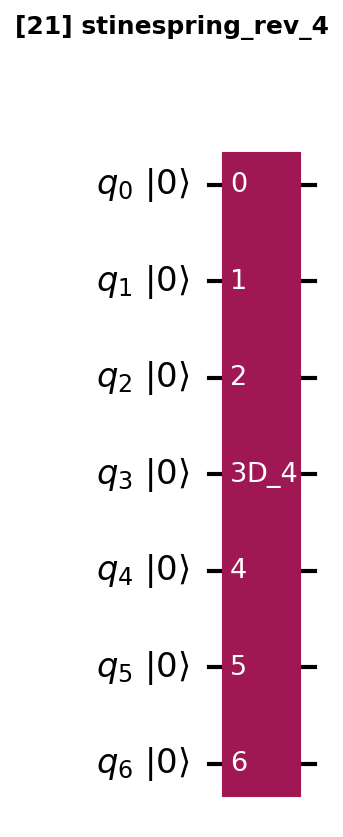


[22] stinespring_rev_3 -> circuit_images/scenario4_qubit_b_22_stinespring_rev_3.png


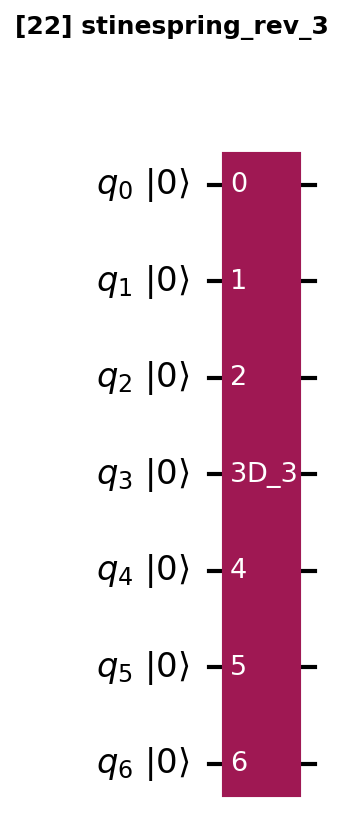


[23] stinespring_rev_2 -> circuit_images/scenario4_qubit_b_23_stinespring_rev_2.png


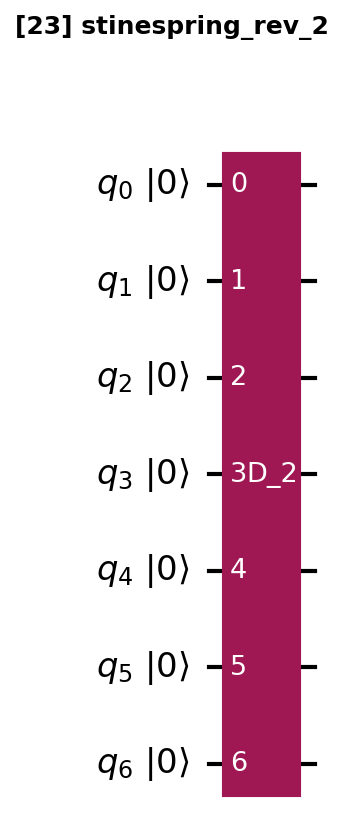


[24] stinespring_rev_1 -> circuit_images/scenario4_qubit_b_24_stinespring_rev_1.png


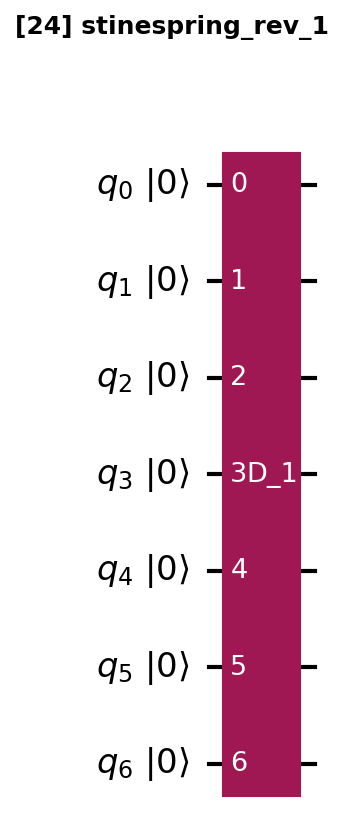


[25] stinespring_rev_0 -> circuit_images/scenario4_qubit_b_25_stinespring_rev_0.png


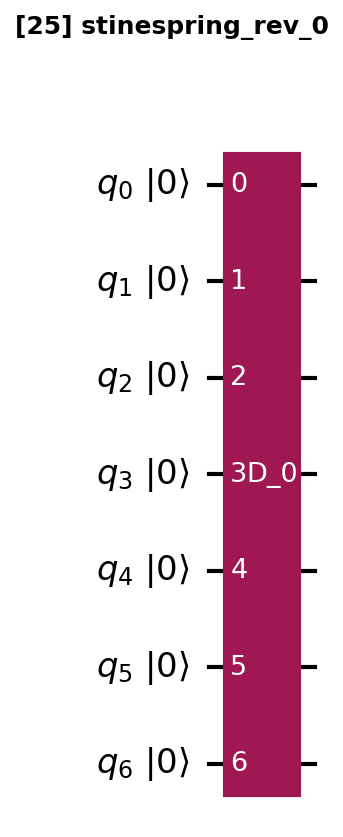


[26] hamiltonian_half_2 -> circuit_images/scenario4_qubit_b_26_hamiltonian_half_2.png


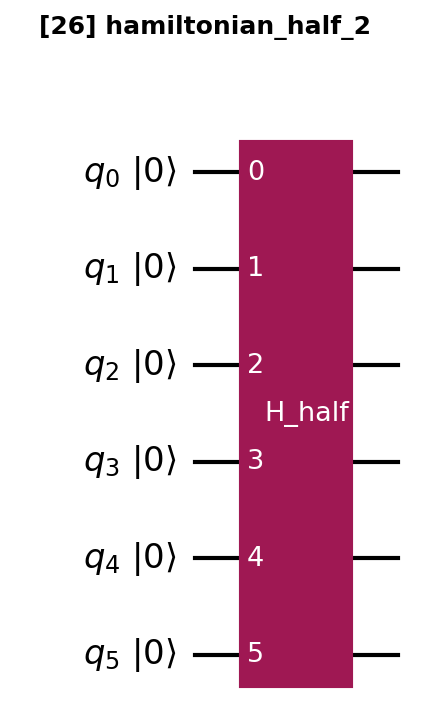

In [8]:
from scipy.linalg import expm
from typing import Protocol

from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import circuit_drawer

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Image

from qubit_gksl_circuit_simulator import QubitGKSLCircuitSimulator
from qudit_gksl_circuit_simulator import QuditGKSLCircuitSimulator
from qudit_gksl_circuit_boson_simulator import QuditGKSLCircuitBosonSimulator
from stinespring_utils import stinespring_unitary_from_lindblad

from mqt.qudits.quantum_circuit.components.extensions.gate_types import GateTypes

# Output directory for PNG files
os.makedirs("circuit_images", exist_ok=True)


def _embed_unitary_to_power_of_two(U: np.ndarray, target_dim: int) -> np.ndarray:
    if U.shape[0] != U.shape[1]:
        raise ValueError("Unitary must be square")
    if target_dim <= 0 or (target_dim & (target_dim - 1)) != 0:
        raise ValueError("Target dimension must be a positive power of two")
    if U.shape[0] > target_dim:
        raise ValueError("Target dimension is smaller than unitary dimension")

    embedded = np.eye(target_dim, dtype=np.complex128)
    embedded[: U.shape[0], : U.shape[1]] = U
    return embedded


class SupportsToQasm(Protocol):
    def to_qasm(self) -> str: ...


def _draw_qiskit_subcircuits(
    title: str,
    named_circuits: list[tuple[str, QuantumCircuit]],
    prefix: str,
) -> None:
    """Draw Qiskit subcircuits using circuit_drawer with mpl output, save as PNG, and display."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"subcircuits: {len(named_circuits)}")
    for idx, (name, circuit) in enumerate(named_circuits, start=1):
        filename = f"circuit_images/{prefix}_{idx:02d}_{name}.png"
        fig = circuit_drawer(circuit, output="mpl", fold=40, initial_state=True)
        fig.suptitle(f"[{idx:02d}] {name}", fontsize=12, fontweight="bold")
        fig.savefig(filename, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"\n[{idx:02d}] {name} -> {filename}")
        display(Image(filename=filename))


def _draw_qudit_circuit_mpl(
    circuit,
    title: str = "",
    filename: str | None = None,
) -> None:
    """Draw an MQT-Qudits QuantumCircuit using matplotlib.

    Renders a circuit diagram with horizontal qudit wires (labeled with
    dimension) and gate boxes for each instruction. Multi-qudit gates
    span the relevant wires with a single box.

    This provides circuit visualization analogous to qiskit.visualization.circuit_drawer
    but for qudit circuits with heterogeneous dimensions.
    """
    n_qudits = circuit.num_qudits
    dims = circuit.dimensions
    instructions = circuit.instructions
    n_gates = len(instructions)

    # Layout parameters
    wire_spacing = 0.8
    gate_spacing = 1.2
    gate_width = 0.9
    gate_height = 0.5
    margin_left = 2.0
    margin_right = 1.0

    total_width = margin_left + max(n_gates, 1) * gate_spacing + margin_right
    total_height = max(2.0, (n_qudits + 1) * wire_spacing)

    fig, ax = plt.subplots(figsize=(min(total_width, 30), total_height))

    x_start = margin_left
    x_end = x_start + max(n_gates, 1) * gate_spacing + 0.5

    # Draw wires and labels
    for i in range(n_qudits):
        y = (n_qudits - 1 - i) * wire_spacing
        ax.plot([x_start - 0.3, x_end], [y, y], color="black", linewidth=0.8)
        label = f"q{i}  (d={dims[i]})"
        ax.text(
            x_start - 0.5, y, label,
            ha="right", va="center", fontsize=9, fontfamily="monospace",
        )
        # Measurement symbol at the end
        ax.plot(x_end + 0.1, y, "k>", markersize=4)

    # Color map for gate types
    gate_colors = {
        GateTypes.SINGLE: "#6fa8dc",   # Blue for single-qudit gates
        GateTypes.TWO: "#93c47d",      # Green for two-qudit gates
        GateTypes.MULTI: "#e6b8af",    # Pink for multi-qudit gates
    }

    # Draw gates
    for gate_idx, gate in enumerate(instructions):
        x = x_start + gate_idx * gate_spacing + 0.5

        gate_name = type(gate).__name__
        color = gate_colors.get(gate.gate_type, "#d9d9d9")

        if gate.gate_type == GateTypes.SINGLE:
            qudit = gate.target_qudits
            y = (n_qudits - 1 - qudit) * wire_spacing
            rect = mpatches.FancyBboxPatch(
                (x - gate_width / 2, y - gate_height / 2),
                gate_width, gate_height,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="black", linewidth=1.2,
            )
            ax.add_patch(rect)
            ax.text(x, y, gate_name, ha="center", va="center", fontsize=7, fontweight="bold")
        else:
            # Multi-qudit gate
            qudits = gate.target_qudits if isinstance(gate.target_qudits, list) else [gate.target_qudits]
            y_positions = [(n_qudits - 1 - q) * wire_spacing for q in qudits]
            y_min = min(y_positions) - gate_height / 2
            y_max = max(y_positions) + gate_height / 2
            box_height = y_max - y_min

            rect = mpatches.FancyBboxPatch(
                (x - gate_width / 2, y_min),
                gate_width, box_height,
                boxstyle="round,pad=0.05",
                facecolor=color, edgecolor="black", linewidth=1.2,
            )
            ax.add_patch(rect)
            y_center = (y_min + y_max) / 2
            label_text = f"{gate_name}\n({','.join(f'q{q}' for q in qudits)})"
            ax.text(x, y_center, label_text, ha="center", va="center", fontsize=6, fontweight="bold")

    ax.set_xlim(0, x_end + 0.5)
    ax.set_ylim(-wire_spacing * 0.8, (n_qudits - 0.2) * wire_spacing)
    ax.set_aspect("auto")
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=11, fontweight="bold", pad=10)

    plt.tight_layout()
    if filename:
        fig.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)


def _draw_qudit_subcircuits(
    title: str,
    named_circuits: list[tuple[str, object]],
    prefix: str,
) -> None:
    """Draw qudit subcircuits using matplotlib, save as PNG, and display."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"subcircuits: {len(named_circuits)}")
    for idx, (name, circuit) in enumerate(named_circuits, start=1):
        filename = f"circuit_images/{prefix}_{idx:02d}_{name}.png"
        _draw_qudit_circuit_mpl(circuit, title=f"[{idx:02d}] {name}", filename=filename)
        print(f"\n[{idx:02d}] {name} -> {filename}")
        display(Image(filename=filename))


dt_quantum = t_max / n_steps_quantum

# Scenario 3: Qubit GKSL (no boson)
qubit_circuit_sim = QubitGKSLCircuitSimulator(params)
qubit_step_info = qubit_circuit_sim.build_full_trotter_step_circuit(dt_quantum)
_draw_qiskit_subcircuits(
    "Scenario 3: Qubit GKSL (No Boson) - 1 Trotter Step",
    qubit_step_info["circuits"],
    prefix="scenario3_qubit_nb",
)

# Scenario 5: Qudit GKSL (no boson)
qudit_circuit_sim = QuditGKSLCircuitSimulator(params)
qudit_step_info = qudit_circuit_sim.build_full_trotter_step_circuit(dt_quantum)
_draw_qudit_subcircuits(
    "Scenario 5: Qudit GKSL (No Boson) - 1 Trotter Step",
    qudit_step_info["circuits"],
    prefix="scenario5_qudit_nb",
)

# Scenario 6: Qudit GKSL (with boson)
qudit_boson_circuit_sim = QuditGKSLCircuitBosonSimulator(params_boson)
qudit_boson_step_circuits: list[tuple[str, SupportsToQasm]] = []

h1, _ = qudit_boson_circuit_sim.build_hamiltonian_circuit(dt_quantum / 2)
qudit_boson_step_circuits.append(("hamiltonian_half_1", h1))

# Forward half-step for all Lindblad channels
for idx, (op_type, sites, L_local, _gamma) in enumerate(qudit_boson_circuit_sim.lindblad_local_info):
    if op_type == "single":
        circ, _ = qudit_boson_circuit_sim.build_stinespring_circuit_single(
            L_local, dt_quantum / 2, sites[0]
        )
        qudit_boson_step_circuits.append((f"stinespring_fwd_single_{idx}", circ))
    elif op_type == "pair":
        circ, _ = qudit_boson_circuit_sim.build_stinespring_circuit_pair(
            L_local, dt_quantum / 2, sites[0], sites[1]
        )
        qudit_boson_step_circuits.append((f"stinespring_fwd_pair_{idx}", circ))

# Reverse half-step for all Lindblad channels (palindromic)
for idx, (op_type, sites, L_local, _gamma) in reversed(list(enumerate(qudit_boson_circuit_sim.lindblad_local_info))):
    if op_type == "single":
        circ, _ = qudit_boson_circuit_sim.build_stinespring_circuit_single(
            L_local, dt_quantum / 2, sites[0]
        )
        qudit_boson_step_circuits.append((f"stinespring_rev_single_{idx}", circ))
    elif op_type == "pair":
        circ, _ = qudit_boson_circuit_sim.build_stinespring_circuit_pair(
            L_local, dt_quantum / 2, sites[0], sites[1]
        )
        qudit_boson_step_circuits.append((f"stinespring_rev_pair_{idx}", circ))

h2, _ = qudit_boson_circuit_sim.build_hamiltonian_circuit(dt_quantum / 2)
qudit_boson_step_circuits.append(("hamiltonian_half_2", h2))

_draw_qudit_subcircuits(
    "Scenario 6: Qudit GKSL (With Boson) - 1 Trotter Step",
    qudit_boson_step_circuits,
    prefix="scenario6_qudit_b",
)

# Scenario 4: Qubit GKSL (with boson)
n_sys_qubits_boson = sim4.n_el_qubits + sim4.n_ph_qubits
dim_sys_boson = 2 ** n_sys_qubits_boson

qubit_boson_step_circuits: list[tuple[str, QuantumCircuit]] = []

U_half = expm(-1j * sim4.H_total * (dt_quantum / 2))
U_half_embedded = _embed_unitary_to_power_of_two(U_half, dim_sys_boson)

ham1 = QuantumCircuit(n_sys_qubits_boson)
ham1.append(UnitaryGate(U_half_embedded, label="H_half"), range(n_sys_qubits_boson))
qubit_boson_step_circuits.append(("hamiltonian_half_1", ham1))

# Forward half-step for all Lindblad channels
for idx, (L_op, _gamma) in enumerate(sim4.lindblad_ops):
    U_stinespring = stinespring_unitary_from_lindblad(L_op, dt_quantum / 2)
    U_stinespring_embedded = _embed_unitary_to_power_of_two(
        U_stinespring, 2 * dim_sys_boson
    )

    channel_circuit = QuantumCircuit(n_sys_qubits_boson + 1)
    channel_circuit.append(
        UnitaryGate(U_stinespring_embedded, label=f"D_{idx}"),
        range(n_sys_qubits_boson + 1),
    )
    qubit_boson_step_circuits.append((f"stinespring_fwd_{idx}", channel_circuit))

# Reverse half-step for all Lindblad channels (palindromic)
for idx, (L_op, _gamma) in reversed(list(enumerate(sim4.lindblad_ops))):
    U_stinespring = stinespring_unitary_from_lindblad(L_op, dt_quantum / 2)
    U_stinespring_embedded = _embed_unitary_to_power_of_two(
        U_stinespring, 2 * dim_sys_boson
    )

    channel_circuit = QuantumCircuit(n_sys_qubits_boson + 1)
    channel_circuit.append(
        UnitaryGate(U_stinespring_embedded, label=f"D_{idx}"),
        range(n_sys_qubits_boson + 1),
    )
    qubit_boson_step_circuits.append((f"stinespring_rev_{idx}", channel_circuit))

ham2 = QuantumCircuit(n_sys_qubits_boson)
ham2.append(UnitaryGate(U_half_embedded, label="H_half"), range(n_sys_qubits_boson))
qubit_boson_step_circuits.append(("hamiltonian_half_2", ham2))

_draw_qiskit_subcircuits(
    "Scenario 4: Qubit GKSL (With Boson) - 1 Trotter Step",
    qubit_boson_step_circuits,
    prefix="scenario4_qubit_b",
)


# ==================================================================
# Combined single-circuit visualization for each scenario
# ==================================================================
# Each scenario's full Trotter step is shown as ONE circuit diagram,
# with all Hamiltonian and Stinespring gates on the same register.
# ==================================================================

print("\n" + "#" * 80)
print("# COMBINED SINGLE-CIRCUIT DIAGRAMS")
print("#" * 80)

# --- Scenario 3: Qubit (No Boson) - Combined ---
qubit_combined_info = qubit_circuit_sim.build_combined_trotter_step_circuit(dt_quantum)
qubit_combined_circ = qubit_combined_info["circuit"]
print(f"\nScenario 3 Combined: {qubit_combined_info['n_total_qubits']} qubits "
      f"({qubit_combined_info['n_system_qubits']} system + "
      f"{qubit_combined_info['n_ancilla_qubits']} ancilla), "
      f"{qubit_combined_info['total_gates']} gates "
      f"({qubit_combined_info['n_hamiltonian_gates']} H + "
      f"{qubit_combined_info['n_stinespring_gates']} D)")

fig_qb = circuit_drawer(qubit_combined_circ, output="mpl", fold=40, initial_state=True)
fig_qb.suptitle(
    "Scenario 3: Qubit GKSL (No Boson) - Combined 1 Trotter Step\n"
    f"({qubit_combined_info['n_total_qubits']} qubits: "
    f"{qubit_combined_info['n_system_qubits']} system + 1 ancilla, "
    f"{qubit_combined_info['total_gates']} gates)",
    fontsize=11, fontweight="bold",
)
filename_qb = "circuit_images/scenario3_qubit_nb_combined.png"
fig_qb.savefig(filename_qb, dpi=150, bbox_inches="tight")
plt.close(fig_qb)
print(f"  -> {filename_qb}")
display(Image(filename=filename_qb))

# --- Scenario 5: Qudit (No Boson) - Combined ---
qudit_combined_info = qudit_circuit_sim.build_combined_trotter_step_circuit(dt_quantum)
qudit_combined_circ = qudit_combined_info["circuit"]
print(f"\nScenario 5 Combined: {qudit_combined_info['n_total_qudits']} qudits "
      f"({qudit_combined_info['n_system_qudits']} system + "
      f"{qudit_combined_info['n_ancilla_qudits']} ancilla), "
      f"{qudit_combined_info['total_gates']} gates "
      f"({qudit_combined_info['n_hamiltonian_gates']} H + "
      f"{qudit_combined_info['n_stinespring_gates']} D)")

_draw_qudit_circuit_mpl(
    qudit_combined_circ,
    title=(
        "Scenario 5: Qudit GKSL (No Boson) - Combined 1 Trotter Step\n"
        f"({qudit_combined_info['n_total_qudits']} qudits: "
        f"{qudit_combined_info['n_system_qudits']} system + 1 ancilla, "
        f"{qudit_combined_info['total_gates']} gates)"
    ),
    filename="circuit_images/scenario5_qudit_nb_combined.png",
)
print(f"  -> circuit_images/scenario5_qudit_nb_combined.png")
display(Image(filename="circuit_images/scenario5_qudit_nb_combined.png"))

# --- Scenario 6: Qudit (With Boson) - Combined ---
qudit_boson_combined_info = qudit_boson_circuit_sim.build_combined_trotter_step_circuit(dt_quantum)
qudit_boson_combined_circ = qudit_boson_combined_info["circuit"]
print(f"\nScenario 6 Combined: {qudit_boson_combined_info['n_total_qudits']} qudits "
      f"({qudit_boson_combined_info['n_system_qudits']} system + "
      f"{qudit_boson_combined_info['n_ancilla_qudits']} ancilla), "
      f"{qudit_boson_combined_info['total_gates']} gates "
      f"({qudit_boson_combined_info['n_hamiltonian_gates']} H + "
      f"{qudit_boson_combined_info['n_stinespring_gates']} D)")

_draw_qudit_circuit_mpl(
    qudit_boson_combined_circ,
    title=(
        "Scenario 6: Qudit GKSL (With Boson) - Combined 1 Trotter Step\n"
        f"({qudit_boson_combined_info['n_total_qudits']} qudits: "
        f"{qudit_boson_combined_info['n_system_qudits']} system + 1 ancilla, "
        f"{qudit_boson_combined_info['total_gates']} gates)"
    ),
    filename="circuit_images/scenario6_qudit_b_combined.png",
)
print(f"  -> circuit_images/scenario6_qudit_b_combined.png")
display(Image(filename="circuit_images/scenario6_qudit_b_combined.png"))

# --- Scenario 4: Qubit (With Boson) - Combined ---
n_total_qubits_s4 = n_sys_qubits_boson + 1
combined_s4 = QuantumCircuit(n_total_qubits_s4)
ancilla_s4 = n_sys_qubits_boson
n_ham_gates_s4 = 0
n_st_gates_s4 = 0

# Hamiltonian half-step 1
combined_s4.append(UnitaryGate(U_half_embedded, label="H_half"), range(n_sys_qubits_boson))
n_ham_gates_s4 += 1

# Forward Lindblad half-step
for idx, (L_op, _gamma) in enumerate(sim4.lindblad_ops):
    combined_s4.reset(ancilla_s4)
    U_st = stinespring_unitary_from_lindblad(L_op, dt_quantum / 2)
    U_st_emb = _embed_unitary_to_power_of_two(U_st, 2 * dim_sys_boson)
    combined_s4.append(
        UnitaryGate(U_st_emb, label=f"D_{idx}"),
        range(n_total_qubits_s4),
    )
    n_st_gates_s4 += 1

# Reverse Lindblad half-step (palindromic)
for idx, (L_op, _gamma) in reversed(list(enumerate(sim4.lindblad_ops))):
    combined_s4.reset(ancilla_s4)
    U_st = stinespring_unitary_from_lindblad(L_op, dt_quantum / 2)
    U_st_emb = _embed_unitary_to_power_of_two(U_st, 2 * dim_sys_boson)
    combined_s4.append(
        UnitaryGate(U_st_emb, label=f"D_{idx}"),
        range(n_total_qubits_s4),
    )
    n_st_gates_s4 += 1

# Hamiltonian half-step 2
combined_s4.append(UnitaryGate(U_half_embedded, label="H_half"), range(n_sys_qubits_boson))
n_ham_gates_s4 += 1

total_gates_s4 = n_ham_gates_s4 + n_st_gates_s4
print(f"\nScenario 4 Combined: {n_total_qubits_s4} qubits "
      f"({n_sys_qubits_boson} system + 1 ancilla), "
      f"{total_gates_s4} gates ({n_ham_gates_s4} H + {n_st_gates_s4} D)")

fig_s4 = circuit_drawer(combined_s4, output="mpl", fold=40, initial_state=True)
fig_s4.suptitle(
    "Scenario 4: Qubit GKSL (With Boson) - Combined 1 Trotter Step\n"
    f"({n_total_qubits_s4} qubits: {n_sys_qubits_boson} system + 1 ancilla, "
    f"{total_gates_s4} gates)",
    fontsize=11, fontweight="bold",
)
filename_s4 = "circuit_images/scenario4_qubit_b_combined.png"
fig_s4.savefig(filename_s4, dpi=150, bbox_inches="tight")
plt.close(fig_s4)
print(f"  -> {filename_s4}")
display(Image(filename=filename_s4))


## 8. 全シナリオの包括的比較

ボソン無しの3シナリオ（同一パラメータ）とボソン有りの3シナリオ（同一パラメータ）を
それぞれ比較します。

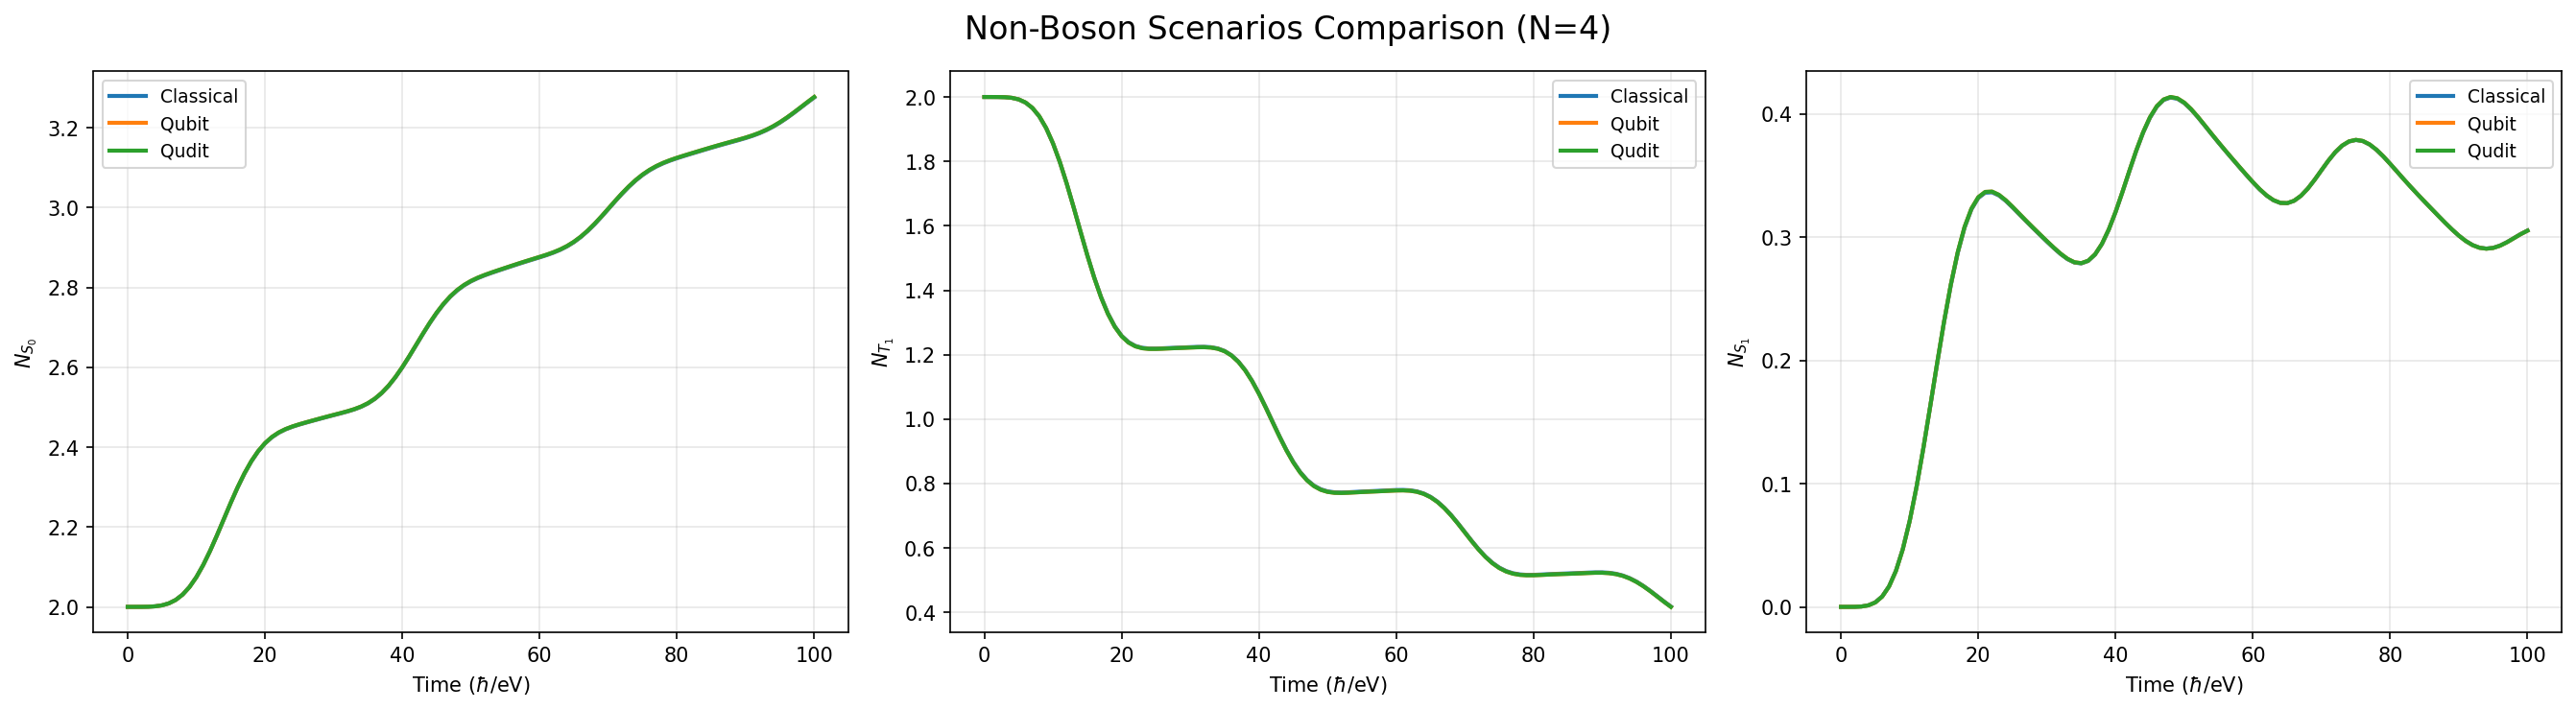

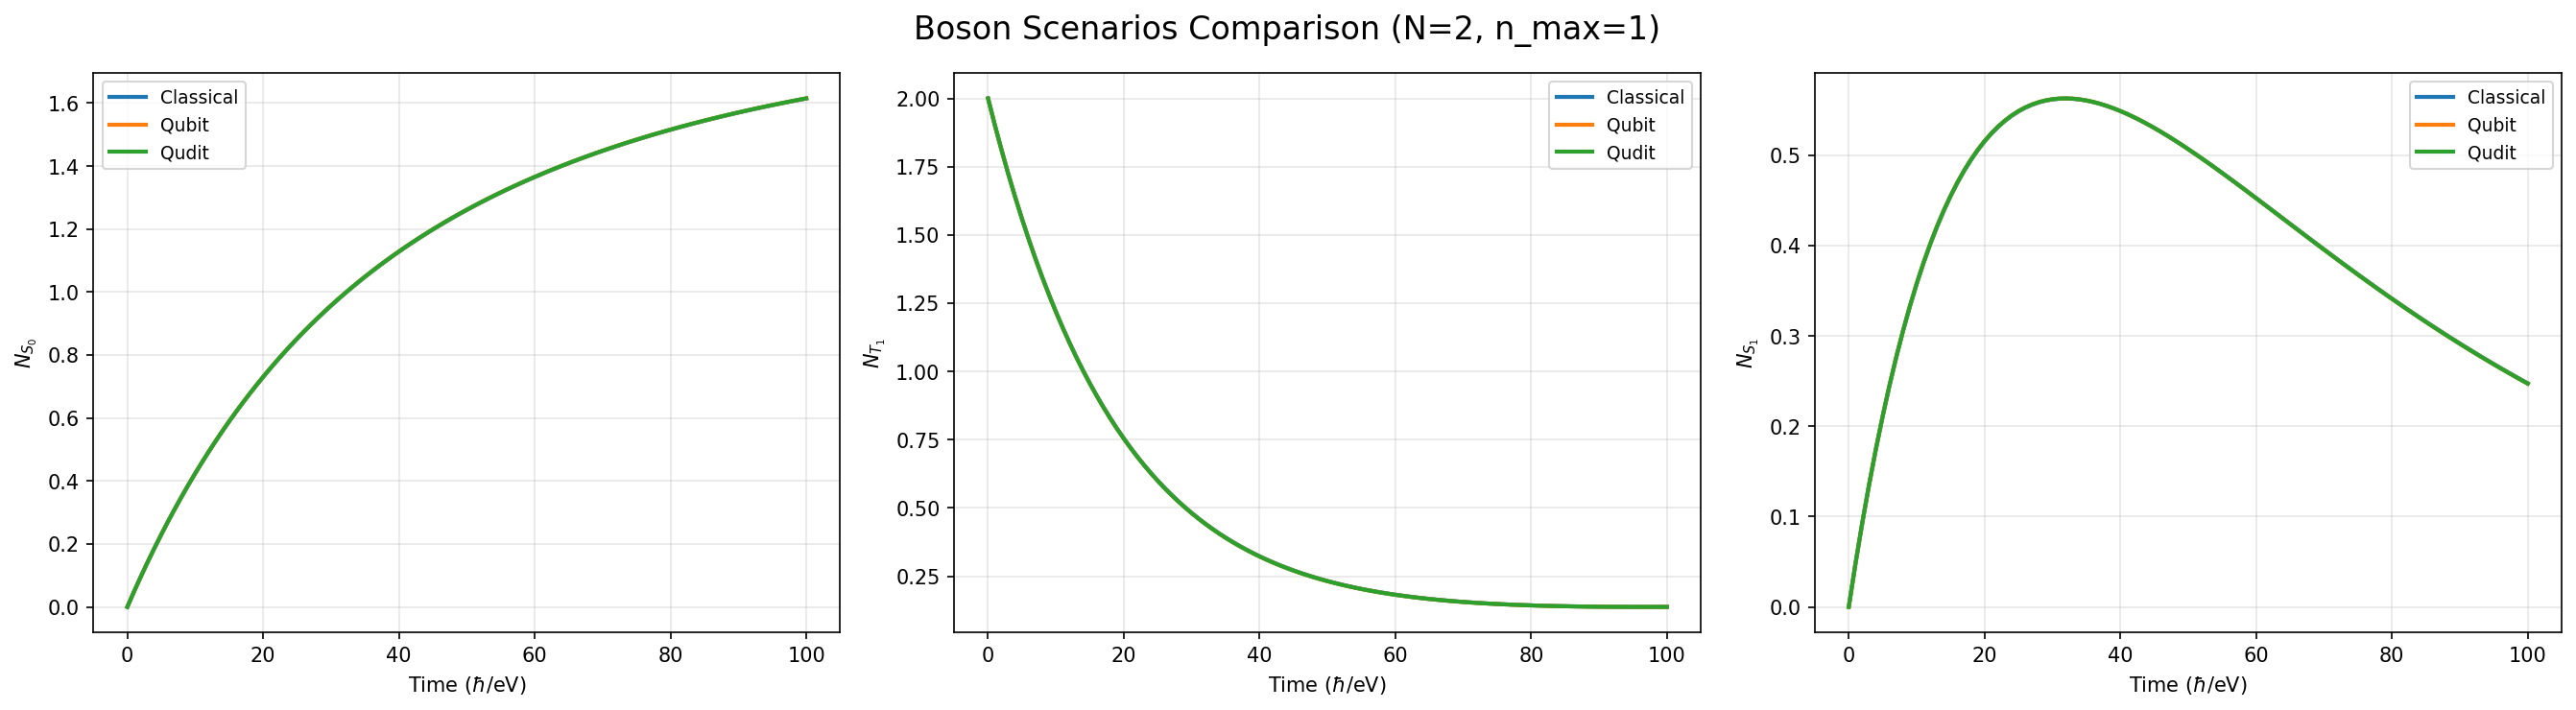

In [9]:
from gksl_visualization import compare_multiple_scenarios
from IPython.display import display, Image

# Non-boson comparison (all use same 81-dim Hilbert space)
results_nb = {
    'Classical': result1,
    'Qubit': result3,
    'Qudit': result5,
}
compare_multiple_scenarios(results_nb, title='Non-Boson Scenarios Comparison (N=4)',
                           save_path='circuit_images/comparison_non_boson.png')
display(Image(filename='circuit_images/comparison_non_boson.png'))

# Boson comparison (N=2, n_max=1)
results_b = {
    'Classical': result2,
    'Qubit': result4,
    'Qudit': result6,
}
compare_multiple_scenarios(results_b, title='Boson Scenarios Comparison (N=2, n_max=1)',
                           save_path='circuit_images/comparison_boson.png')
display(Image(filename='circuit_images/comparison_boson.png'))


## 9. ユニタリ vs GKSL-Lindblad 比較

全散逸率を0にした純ユニタリ発展（閉量子系）と、
散逸ありのGKSL-Lindblad発展（開量子系）を比較します。

Unitary: max entropy = 2.22e-16 (should be ~0)
GKSL: final entropy = 1.7048


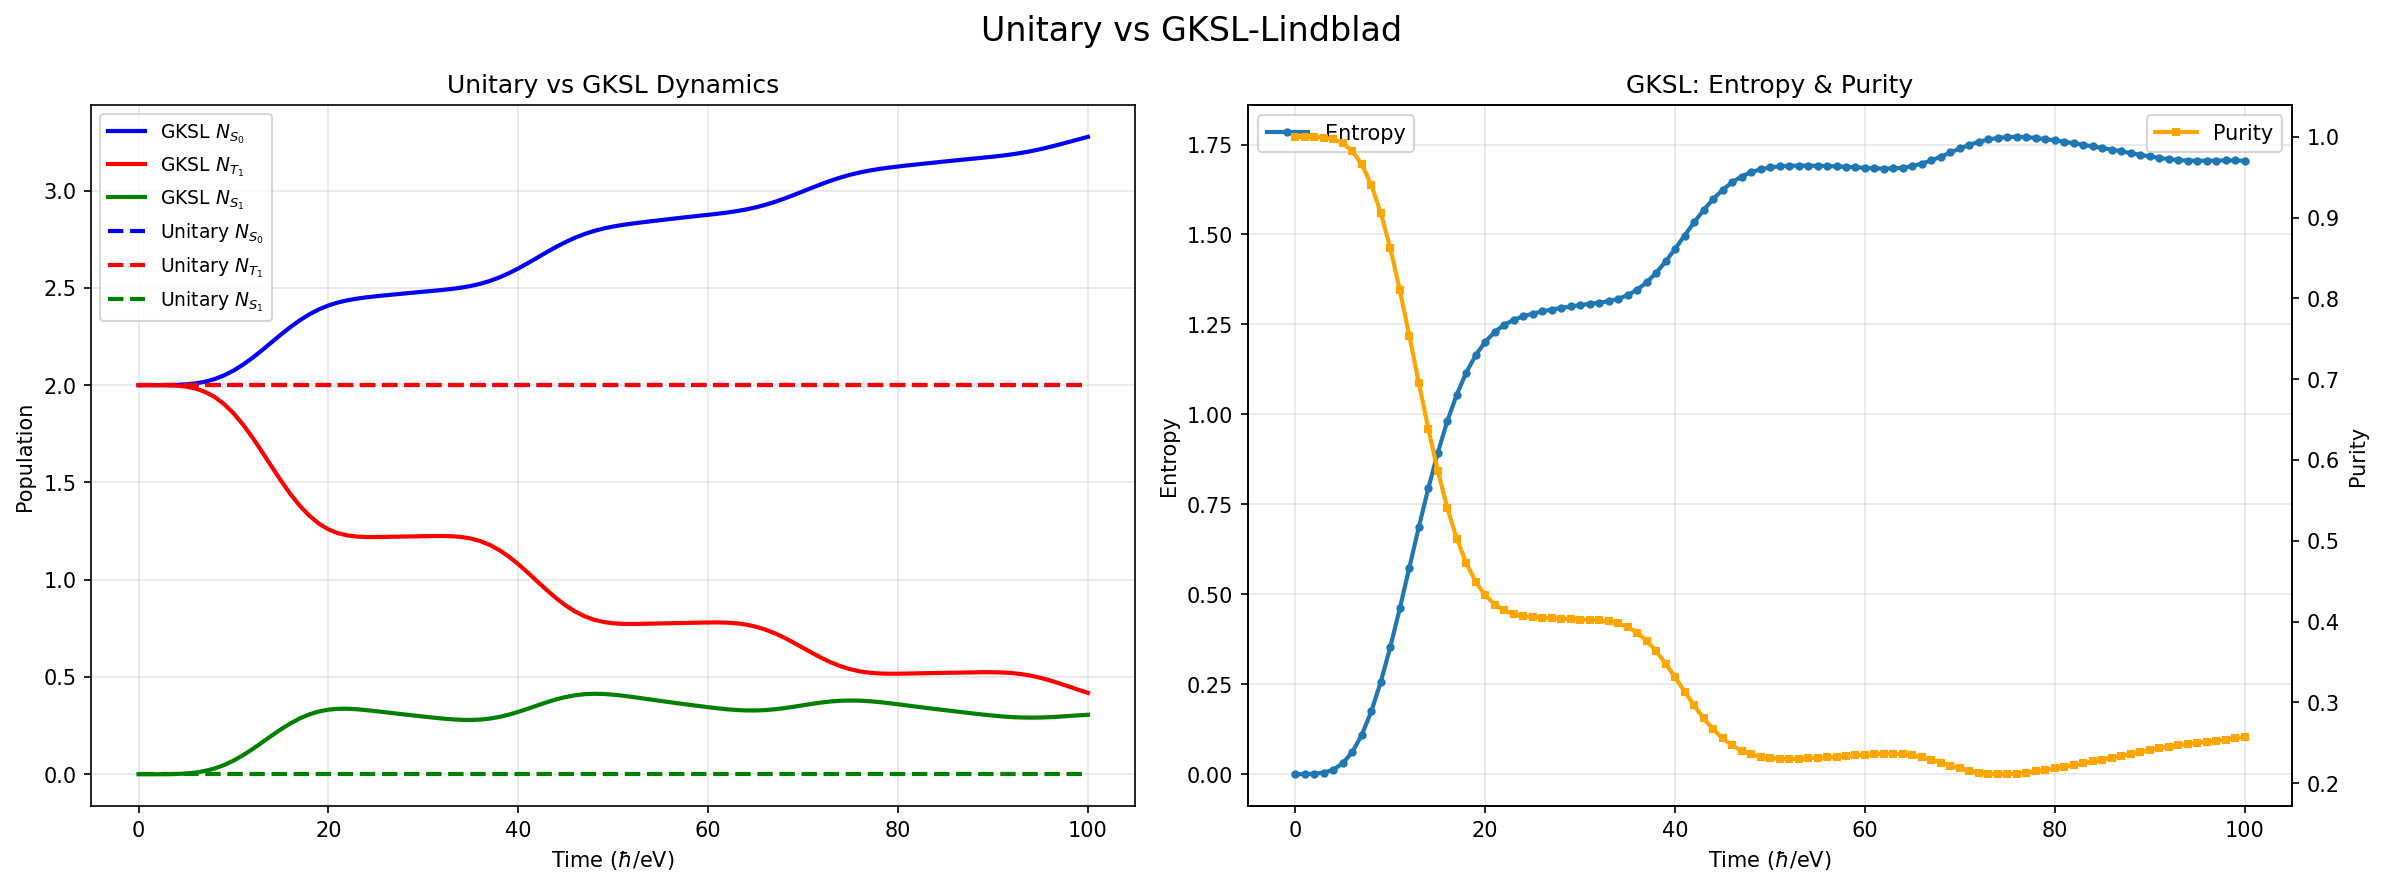

In [10]:
from gksl_visualization import plot_gksl_comparison
from IPython.display import display, Image

# Unitary limit (all dissipation rates = 0)
params_unitary = GKSLPhysicalParameters(
    gamma_TTA=0, Gamma_fl=0, Gamma_ph=0,
    k_IC=0, k_ISC_ST=0, k_ISC_TS=0,
)
sim_unitary = ClassicalGKSLSimulator(params_unitary)
result_unitary = sim_unitary.simulate(t_max=t_max, n_steps=n_steps, initial_state='edge_triplet')

print(f'Unitary: max entropy = {max(result_unitary["entropy"]):.2e} (should be ~0)')
print(f'GKSL: final entropy = {result1["entropy"][-1]:.4f}')

plot_gksl_comparison(result_unitary, result1, title='Unitary vs GKSL-Lindblad',
                     save_path='circuit_images/unitary_vs_gksl.png')
display(Image(filename='circuit_images/unitary_vs_gksl.png'))


## 9b. ユニタリTTA vs 散逸TTA の比較

### 背景

`quantum_dynamics_complete_comparison.ipynb` ではTTA過程をハミルトニアン項（コヒーレント・可逆的相互作用）として
モデル化しているのに対し、本ノートブックではLindblad散逸子（不可逆な散逸過程）としてモデル化しています。

この2つのモデルの**定性的な振る舞いの違い**を直接比較します。

### 比較対象

| ケース | ハミルトニアン | 散逸項 | TTA過程の性質 |
|--------|-------------|--------|-------------|
| A: ユニタリTTA | $H = H_0 + H_{\text{transfer}} + H_{\text{TTA}}$ | なし | コヒーレント振動（可逆） |
| B: 散逸TTA only | $H = H_0 + H_{\text{transfer}}$ | $L_{\text{TTA}}$ のみ | 不可逆な散逸遷移 |
| C: 全散逸GKSL | $H = H_0 + H_{\text{transfer}}$ | 全$L_\alpha$ | 全散逸チャネル |

### ハミルトニアンTTA（ケースA）

$$\hat{H}_{\text{TTA}} = J_{\text{TTA}} \sum_{\langle i,j \rangle} \left[ |S_0\rangle_i\langle T_1| \otimes |S_1\rangle_j\langle T_1| + |S_1\rangle_i\langle T_1| \otimes |S_0\rangle_j\langle T_1| + \text{h.c.} \right]$$

これは $|T_1, T_1\rangle \leftrightarrow |S_0, S_1\rangle + |S_1, S_0\rangle$ の**可逆的なコヒーレント振動**を引き起こします。

### Lindblad TTA（ケースB）

$$L_{\text{TTA}}^{(1)} = \sqrt{\gamma_{\text{TTA}}/2}\; |S_1\rangle_i\langle T_1| \otimes |S_0\rangle_j\langle T_1|, \quad L_{\text{TTA}}^{(2)} = \sqrt{\gamma_{\text{TTA}}/2}\; |S_0\rangle_i\langle T_1| \otimes |S_1\rangle_j\langle T_1|$$

これは $|T_1, T_1\rangle \rightarrow |S_0, S_1\rangle$ および $|T_1, T_1\rangle \rightarrow |S_1, S_0\rangle$ の**不可逆な散逸遷移**を引き起こします。

### 注意事項

- $J_{\text{TTA}}$（ハミルトニアン結合定数、エネルギーの次元）と $\gamma_{\text{TTA}}$（散逸率、逆時間の次元）は**物理的に異なる量**です
- ここでは便宜上 $J_{\text{TTA}} = \gamma_{\text{TTA}}$ と設定しますが、これは定性的な比較のためであり、物理的な等価性を意味しません
- 本比較の目的は、同じTTA過程がコヒーレント/デコヒーレントにモデル化された場合の**定性的な振る舞いの違い**を示すことです


=== Case A: Unitary TTA ===
H = H_0 + H_transfer + J_TTA * H_TTA, J_TTA = 0.05
  Final: N_T1=1.8946, N_S1=0.0527
  Max entropy: 5.93e-14 (should be ~0 for pure state)

=== Case B: Dissipative TTA only ===
H = H_0 + H_transfer, L_TTA only, gamma_TTA = 0.05
  Final: N_T1=0.3300, N_S1=0.8350
  Final entropy: 1.4029

=== Case C: Full GKSL (reference) ===
  Final: N_T1=0.4184, N_S1=0.3054
  Final entropy: 1.7048


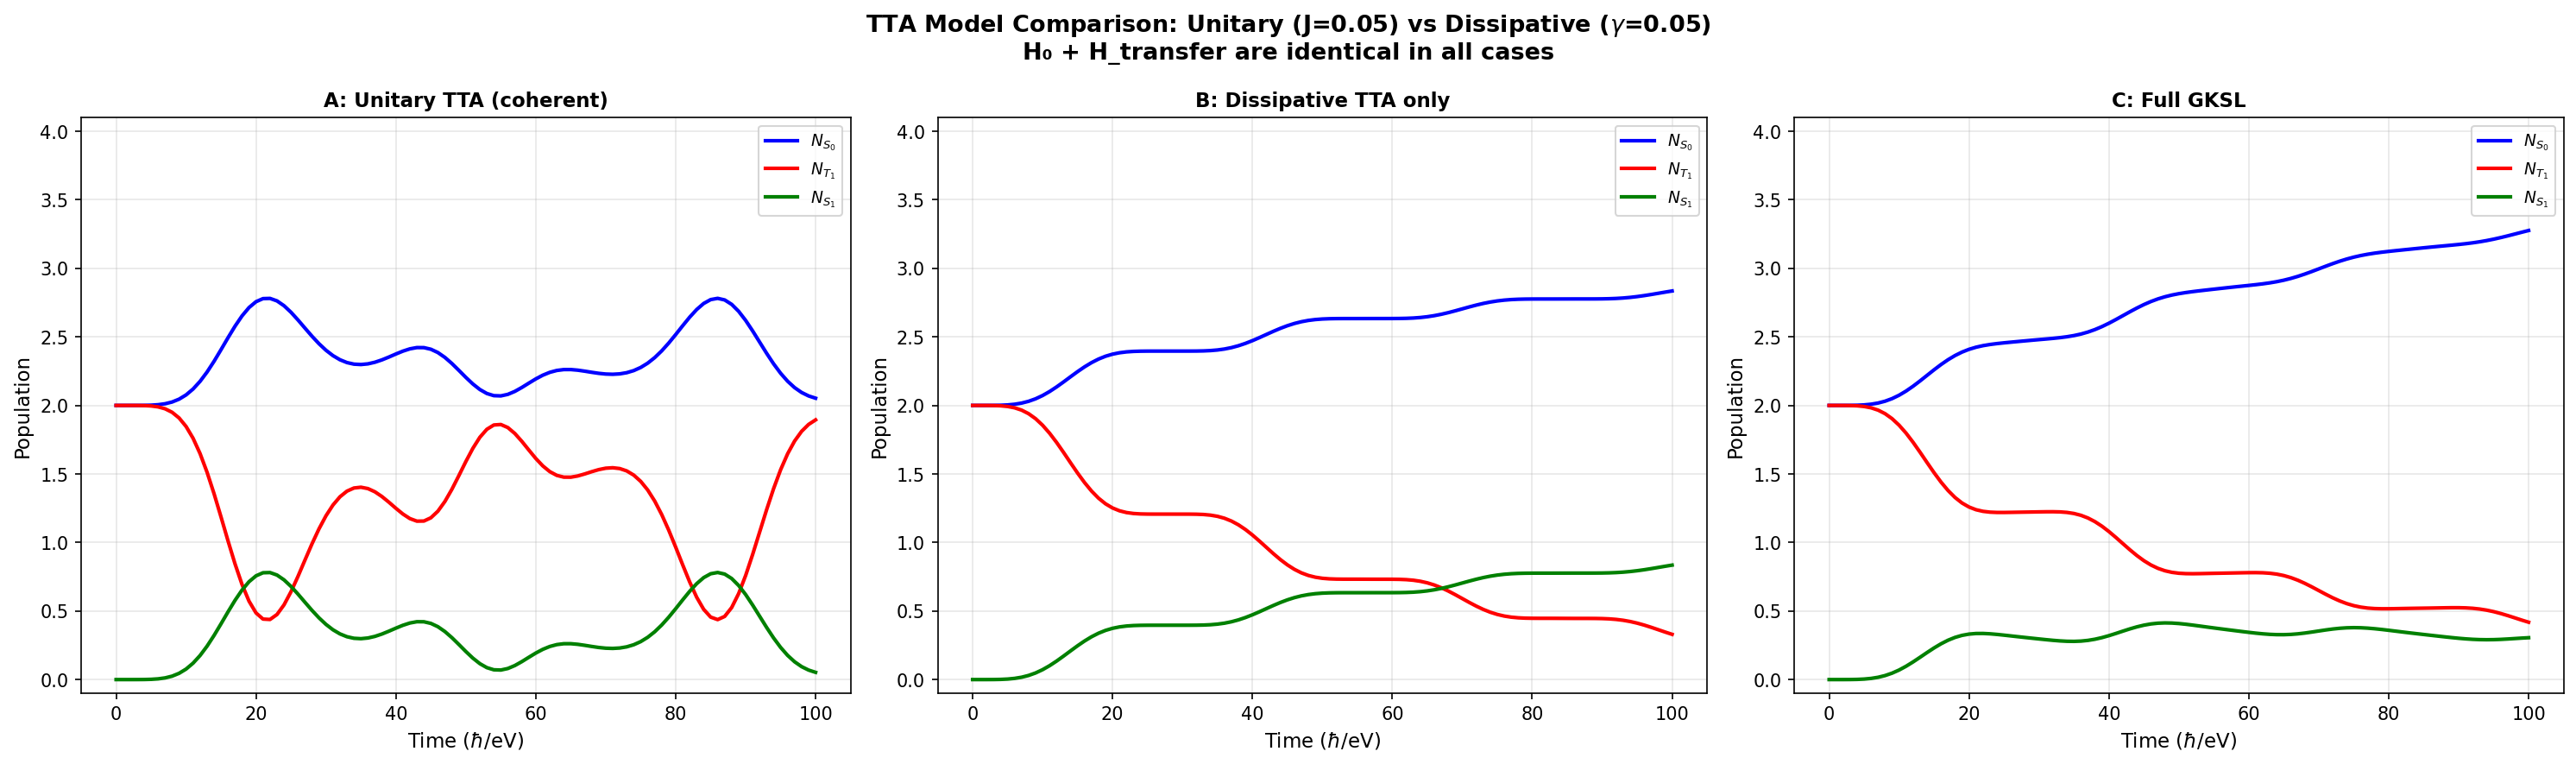

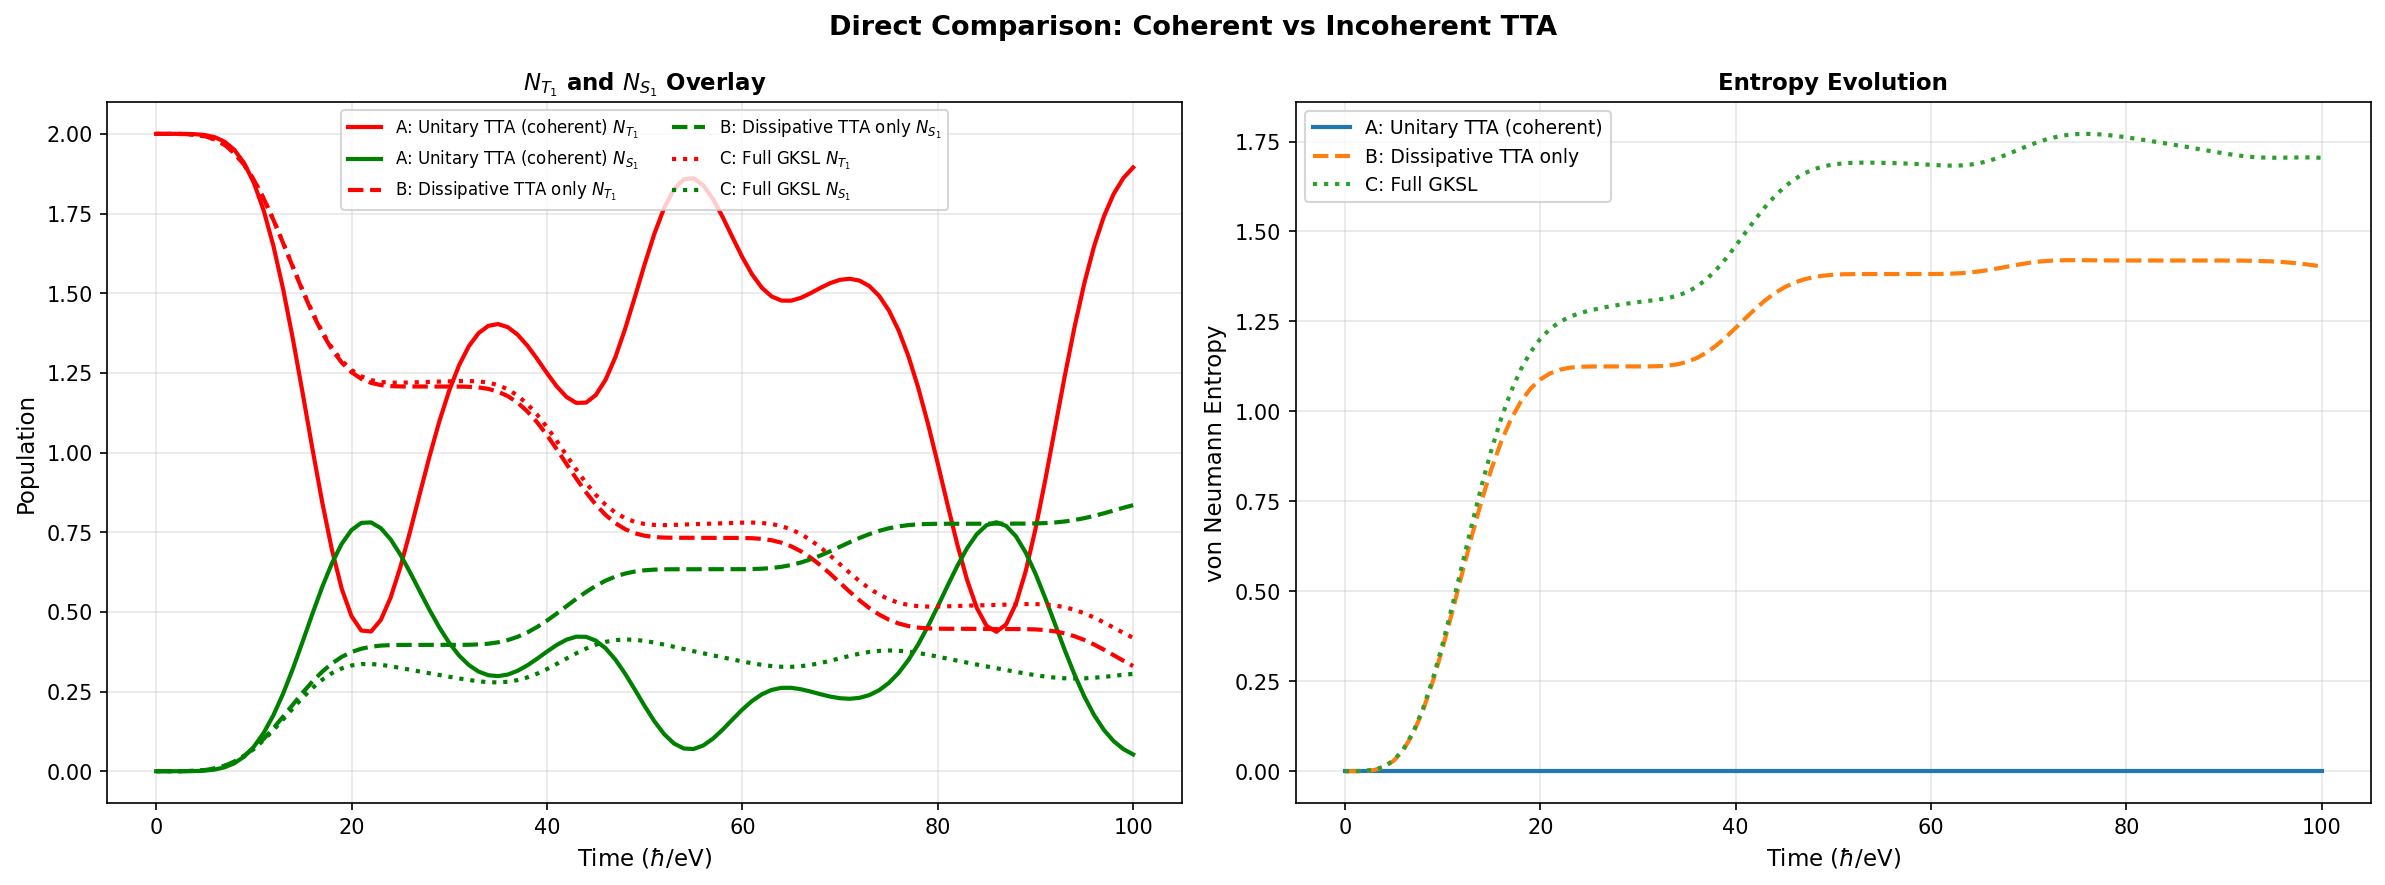


TTA Model Comparison Summary
Case                            N_T1(final)  N_S1(final)  Entropy(final)
--------------------------------------------------------------------------------
A: Unitary TTA (coherent)            1.8946       0.0527     -1.9984e-15
B: Dissipative TTA only              0.3300       0.8350      1.4029e+00
C: Full GKSL                         0.4184       0.3054      1.7048e+00

Key observations:
  - Case A (Unitary TTA): Coherent oscillation between |T1,T1> and |S0,S1>.
    Entropy remains 0 (pure state preserved). Population oscillates reversibly.
  - Case B (Dissipative TTA only): Irreversible decay of N_T1, monotonic increase of N_S1.
    Entropy increases (mixed state). No back-transfer from S1 to T1.
  - Case C (Full GKSL): Additional decay channels (fluorescence, IC, ISC) cause
    further population redistribution and entropy increase.


In [11]:
# ユニタリTTA vs 散逸TTA の比較

import numpy as np
from functools import reduce
from scipy.linalg import expm
from gksl_math_utils import (
    build_onsite_hamiltonian,
    build_transfer_hamiltonian,
    build_single_site_operator,
    compute_populations_from_density_matrix,
    compute_von_neumann_entropy,
    compute_purity,
)
from classical_gksl_simulator import ClassicalGKSLSimulator
from gksl_visualization import plot_population_dynamics
from IPython.display import display, Image
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def build_tta_hamiltonian(params):
    """Build Hamiltonian TTA coupling term H_TTA.

    H_TTA = J_TTA * sum_{<i,j>} [ |S0>_i<T1| x |S1>_j<T1|
                                 + |S1>_i<T1| x |S0>_j<T1| + h.c. ]

    Uses the same structure as the GKSL Lindblad TTA operators,
    but as a Hermitian Hamiltonian coupling instead of a dissipator.
    """
    N = params.N_molecules
    d = params.d
    dim = d ** N
    eye = np.eye(d, dtype=np.complex128)
    H_TTA = np.zeros((dim, dim), dtype=np.complex128)

    def _ket_bra(a, b):
        m = np.zeros((d, d), dtype=np.complex128)
        m[a, b] = 1.0
        return m

    for i, j in params.neighbors:
        # Term 1: |S0>_i<T1| x |S1>_j<T1| = |0>_i<1| x |2>_j<1|
        op1 = [eye] * N
        op1[i] = _ket_bra(0, 1)  # |S0><T1|
        op1[j] = _ket_bra(2, 1)  # |S1><T1|
        term1 = reduce(np.kron, op1)

        # Term 2: |S1>_i<T1| x |S0>_j<T1| = |2>_i<1| x |0>_j<1|
        op2 = [eye] * N
        op2[i] = _ket_bra(2, 1)  # |S1><T1|
        op2[j] = _ket_bra(0, 1)  # |S0><T1|
        term2 = reduce(np.kron, op2)

        H_TTA += term1 + term1.conj().T + term2 + term2.conj().T

    # Verify Hermiticity
    assert np.allclose(H_TTA, H_TTA.conj().T), "H_TTA is not Hermitian"
    return H_TTA


def simulate_unitary_tta(params, J_TTA, t_max, n_steps, initial_state='edge_triplet'):
    """Simulate unitary evolution with H = H_0 + H_transfer + J_TTA * H_TTA.

    Uses the same unit system as the GKSL simulator (hbar = 1),
    so the time evolution operator is exp(-i H t).
    """
    dim = params.d ** params.N_molecules
    H_0 = build_onsite_hamiltonian(params)
    H_transfer = build_transfer_hamiltonian(params)
    H_TTA = build_tta_hamiltonian(params)
    H_total = H_0 + H_transfer + J_TTA * H_TTA

    # Verify Hermiticity
    assert np.allclose(H_total, H_total.conj().T), "H_total is not Hermitian"

    # Prepare initial state
    psi = np.zeros(dim, dtype=np.complex128)
    if initial_state == 'edge_triplet':
        d = params.d
        N = params.N_molecules
        index = 1 * (d ** (N - 1)) + 1  # |1,0,...,0,1>
        psi[index] = 1.0
    else:
        raise ValueError(f"Unknown initial state: {initial_state}")

    rho_0 = np.outer(psi, psi.conj())

    times = np.linspace(0, t_max, n_steps + 1)
    populations = []
    entropy_list = []
    purity_list = []

    for t in times:
        # Exact unitary evolution: rho(t) = U(t) rho_0 U(t)^dagger
        U = expm(-1j * H_total * t)
        rho_t = U @ rho_0 @ U.conj().T
        pop = compute_populations_from_density_matrix(rho_t, params)
        populations.append(pop)
        entropy_list.append(compute_von_neumann_entropy(rho_t))
        purity_list.append(compute_purity(rho_t))

    return {
        'times': times,
        'populations': populations,
        'entropy': entropy_list,
        'purity': purity_list,
        'method': f'Unitary TTA (J_TTA={J_TTA})',
    }


# --- Run the comparison ---

# Use gamma_TTA as J_TTA for convenient (but NOT physically equivalent) comparison
J_TTA = params.gamma_TTA  # = 0.05

# Case A: Unitary TTA (coherent, reversible)
print('=== Case A: Unitary TTA ===')
print(f'H = H_0 + H_transfer + J_TTA * H_TTA, J_TTA = {J_TTA}')
result_unitary_tta = simulate_unitary_tta(
    params, J_TTA=J_TTA, t_max=t_max, n_steps=n_steps,
)
print(f'  Final: N_T1={result_unitary_tta["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result_unitary_tta["populations"][-1]["N_S1"]:.4f}')
print(f'  Max entropy: {max(result_unitary_tta["entropy"]):.2e} (should be ~0 for pure state)')

# Case B: Dissipative TTA only (incoherent, irreversible)
print('\n=== Case B: Dissipative TTA only ===')
print(f'H = H_0 + H_transfer, L_TTA only, gamma_TTA = {params.gamma_TTA}')
params_tta_only = GKSLPhysicalParameters(
    E_T=params.E_T, E_S=params.E_S, V=params.V,
    gamma_TTA=params.gamma_TTA,
    Gamma_fl=0, Gamma_ph=0,
    k_IC=0, k_ISC_ST=0, k_ISC_TS=0,
)
sim_tta_only = ClassicalGKSLSimulator(params_tta_only)
result_tta_only = sim_tta_only.simulate(
    t_max=t_max, n_steps=n_steps, initial_state='edge_triplet',
)
print(f'  Final: N_T1={result_tta_only["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result_tta_only["populations"][-1]["N_S1"]:.4f}')
print(f'  Final entropy: {result_tta_only["entropy"][-1]:.4f}')

# Case C: Full GKSL (all dissipation channels) - already computed as result1
print('\n=== Case C: Full GKSL (reference) ===')
print(f'  Final: N_T1={result1["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result1["populations"][-1]["N_S1"]:.4f}')
print(f'  Final entropy: {result1["entropy"][-1]:.4f}')

# --- Plot comparison ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

results_to_plot = [
    (result_unitary_tta, 'A: Unitary TTA (coherent)', '-'),
    (result_tta_only, 'B: Dissipative TTA only', '--'),
    (result1, 'C: Full GKSL', ':'),
]

colors = {'N_S0': 'blue', 'N_T1': 'red', 'N_S1': 'green'}
labels_pop = {'N_S0': r'$N_{S_0}$', 'N_T1': r'$N_{T_1}$', 'N_S1': r'$N_{S_1}$'}

for ax_idx, (result, case_title, linestyle) in enumerate(results_to_plot):
    ax = axes[ax_idx]
    times_r = result['times']
    for key in ['N_S0', 'N_T1', 'N_S1']:
        values = [p[key] for p in result['populations']]
        ax.plot(times_r, values, color=colors[key], linestyle='-',
                linewidth=2, label=labels_pop[key])
    ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
    ax.set_ylabel('Population', fontsize=11)
    ax.set_title(case_title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.1, 4.1)

fig.suptitle(
    f'TTA Model Comparison: Unitary (J={J_TTA}) vs Dissipative ($\\gamma$={params.gamma_TTA})\n'
    f'H₀ + H_transfer are identical in all cases',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
save_path = 'circuit_images/tta_unitary_vs_dissipative.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=save_path))

# --- Overlay plot for direct comparison ---
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Population overlay
for result, label, ls in results_to_plot:
    times_r = result['times']
    ax1.plot(times_r, [p['N_T1'] for p in result['populations']],
             color='red', linestyle=ls, linewidth=2, label=f'{label} $N_{{T_1}}$')
    ax1.plot(times_r, [p['N_S1'] for p in result['populations']],
             color='green', linestyle=ls, linewidth=2, label=f'{label} $N_{{S_1}}$')

ax1.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax1.set_ylabel('Population', fontsize=11)
ax1.set_title(r'$N_{T_1}$ and $N_{S_1}$ Overlay', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, ncol=2)
ax1.grid(True, alpha=0.3)

# Entropy comparison
for result, label, ls in results_to_plot:
    times_r = result['times']
    ax2.plot(times_r, result['entropy'], linestyle=ls, linewidth=2, label=label)

ax2.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax2.set_ylabel('von Neumann Entropy', fontsize=11)
ax2.set_title('Entropy Evolution', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig2.suptitle(
    'Direct Comparison: Coherent vs Incoherent TTA',
    fontsize=13, fontweight='bold',
)
plt.tight_layout()
save_path2 = 'circuit_images/tta_comparison_overlay.png'
fig2.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.close(fig2)
display(Image(filename=save_path2))

# --- Summary table ---
print('\n' + '=' * 80)
print('TTA Model Comparison Summary')
print('=' * 80)
print(f'{"Case":30s} {"N_T1(final)":>12s} {"N_S1(final)":>12s} {"Entropy(final)":>15s}')
print('-' * 80)
for result, label, _ in results_to_plot:
    pop_final = result['populations'][-1]
    ent_final = result['entropy'][-1]
    print(f'{label:30s} {pop_final["N_T1"]:12.4f} {pop_final["N_S1"]:12.4f} {ent_final:15.4e}')
print('=' * 80)
print()
print('Key observations:')
print('  - Case A (Unitary TTA): Coherent oscillation between |T1,T1> and |S0,S1>.')
print('    Entropy remains 0 (pure state preserved). Population oscillates reversibly.')
print('  - Case B (Dissipative TTA only): Irreversible decay of N_T1, monotonic increase of N_S1.')
print('    Entropy increases (mixed state). No back-transfer from S1 to T1.')
print('  - Case C (Full GKSL): Additional decay channels (fluorescence, IC, ISC) cause')
print('    further population redistribution and entropy increase.')


## 10. 検証と考察

=== Trace conservation |Tr[ρ]-1| ===
  Classical NB: 5.33e-15
  Classical B: 5.77e-15
  Qubit NB: 2.04e-14
  Qubit B: 1.01e-14
  Qudit NB: 2.02e-14
  Qudit B: 9.99e-15

=== Particle conservation |N_total - N_molecules| ===
  Classical NB: 2.22e-14
  Qubit NB: 8.35e-14
  Qudit NB: 8.17e-14

=== Computation time ===
  Classical NB: 22.14s
  Classical B: 0.27s
  Qubit NB: 30.57s
  Qubit B: 2.82s
  Qudit NB: 9.36s
  Qudit B: 3.11s


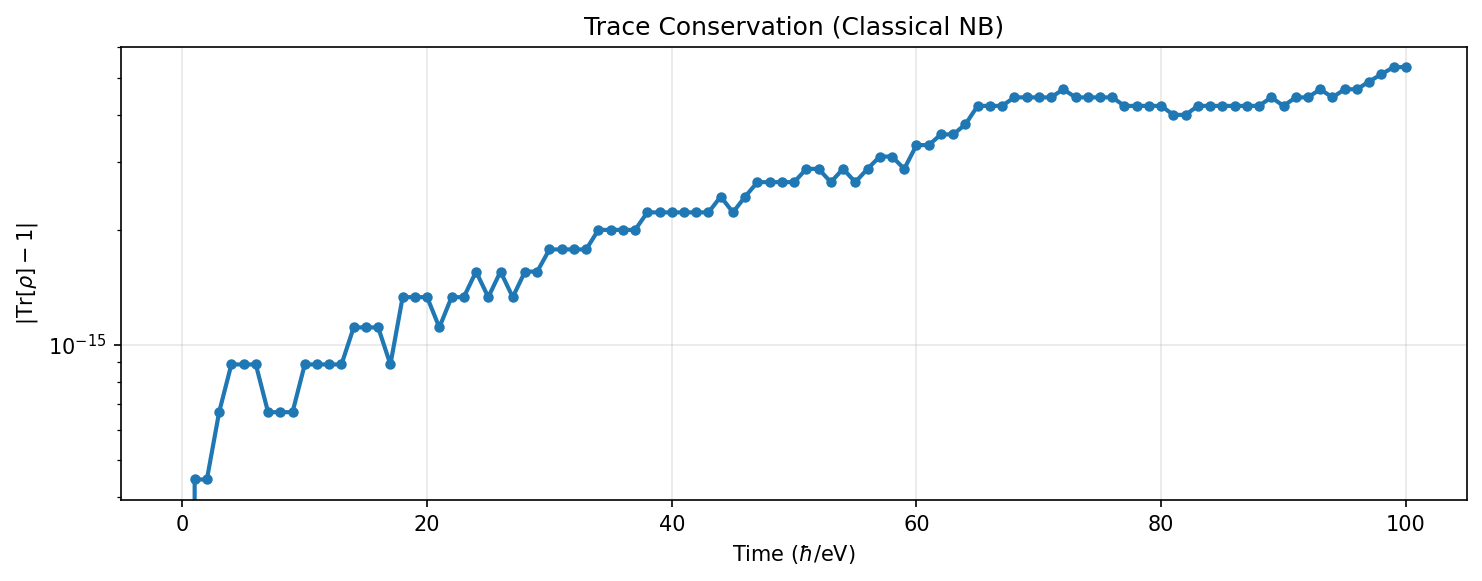

In [12]:
from gksl_visualization import plot_trace_conservation
from IPython.display import display, Image

# Trace conservation check for all scenarios
print('=== Trace conservation |Tr[ρ]-1| ===')
for name, result in [('Classical NB', result1), ('Classical B', result2),
                     ('Qubit NB', result3), ('Qubit B', result4),
                     ('Qudit NB', result5), ('Qudit B', result6)]:
    max_dev = max(abs(t - 1.0) for t in result['trace'])
    print(f'  {name}: {max_dev:.2e}')

print()
print('=== Particle conservation |N_total - N_molecules| ===')
for name, result in [('Classical NB', result1), ('Qubit NB', result3),
                     ('Qudit NB', result5)]:
    N_mol = 4
    max_dev = max(abs(p['N_S0']+p['N_T1']+p['N_S1']-N_mol) for p in result['populations'])
    print(f'  {name}: {max_dev:.2e}')

print()
print('=== Computation time ===')
for name, result in [('Classical NB', result1), ('Classical B', result2),
                     ('Qubit NB', result3), ('Qubit B', result4),
                     ('Qudit NB', result5), ('Qudit B', result6)]:
    print(f'  {name}: {result["elapsed_time"]:.2f}s')

# Trace conservation plot for classical reference
plot_trace_conservation(result1, title='Trace Conservation (Classical NB)',
                        save_path='circuit_images/trace_conservation.png')
display(Image(filename='circuit_images/trace_conservation.png'))


## 11. Stinespring忠実度の評価

古典ODE結果（理想値）とStinespring+Trotter結果の量子忠実度を計算します。

$$F(\hat{\rho}, \hat{\sigma}) = \left(\mathrm{Tr}\sqrt{\sqrt{\hat{\rho}}\hat{\sigma}\sqrt{\hat{\rho}}}\right)^2$$

In [13]:
def quantum_fidelity(rho, sigma):
    """Compute quantum state fidelity via eigendecomposition."""
    evals, evecs = np.linalg.eigh(rho)
    evals = np.maximum(evals, 0.0)
    sqrt_rho = evecs @ np.diag(np.sqrt(evals)) @ evecs.conj().T
    M = sqrt_rho @ sigma @ sqrt_rho
    M = (M + M.conj().T) / 2
    evals_M = np.linalg.eigvalsh(M)
    evals_M = np.maximum(evals_M, 0.0)
    return float(min(np.real(np.sum(np.sqrt(evals_M))) ** 2, 1.0))

# Compare classical vs quantum final density matrices (non-boson)
F_qudit = quantum_fidelity(result1['rho_final'], result5['rho_final'])
F_qubit = quantum_fidelity(result1['rho_final'], result3['rho_final'])

print(f'Fidelity (Classical vs Qudit): F = {F_qudit:.6f}')
print(f'Fidelity (Classical vs Qubit): F = {F_qubit:.6f}')
print(f'Fidelity (Qubit vs Qudit):     F = {quantum_fidelity(result3["rho_final"], result5["rho_final"]):.6f}')

Fidelity (Classical vs Qudit): F = 0.999999
Fidelity (Classical vs Qubit): F = 0.999999
Fidelity (Qubit vs Qudit):     F = 1.000000


## 11b. Stinespring+Trotter 収束特性の分析

複数回の検証イテレーションにより確認された収束特性を定量的に示します。

### 理論的背景

本シミュレーターは以下の3段階の近似を含みます：

1. **Strang対称分割** (Hamiltonian-Dissipator):
   $$e^{(\mathcal{L}_H + \mathcal{L}_D)\Delta t} = e^{\mathcal{L}_H \Delta t/2} \cdot e^{\mathcal{L}_D \Delta t} \cdot e^{\mathcal{L}_H \Delta t/2} + O(\Delta t^3)$$
   → 各ステップ $O(\Delta t^3)$、全体 $O(\Delta t^2)$

2. **回文順序積** (Lindblad チャネル間の分割):
   $$e^{\mathcal{L}_D \Delta t} = \prod_{\alpha=1}^{n} e^{\mathcal{L}_{D_\alpha} \Delta t/2} \cdot \prod_{\alpha=n}^{1} e^{\mathcal{L}_{D_\alpha} \Delta t/2} + O(\Delta t^3)$$
   → Lie-Trotter 交換子誤差の2次消去、各ステップ $O(\Delta t^3)$

3. **Stinespring dilation 近似** (量子回路化のための近似):
   $$\mathcal{E}_\alpha(\rho) = \text{Tr}_{\text{anc}}[U_\alpha (\rho \otimes |0\rangle\langle 0|) U_\alpha^\dagger]$$
   $$= \rho + \Delta t \left(L_\alpha \rho L_\alpha^\dagger - \frac{1}{2}\{L_\alpha^\dagger L_\alpha, \rho\}\right) + O(\Delta t^2)$$
   → 各ステップ $O(\Delta t^2)$、**全体 $O(\Delta t)$** ← 支配的誤差項

### 結論

Stinespring dilation の $O(\Delta t)$ 近似誤差が支配的であるため、
シミュレーター全体の収束次数は **$O(\Delta t)$（1次）** となります。
これはバグではなく、Stinespring dilation の数学的性質です。

以下のコードで、`ClassicalGKSLSimulator`（厳密 $\exp(\mathcal{L}t)$）を基準として
`QuditGKSLSimulator`（Stinespring+Trotter）の収束次数を実測します。

In [14]:
# Convergence analysis: trace distance vs n_steps
from classical_gksl_simulator import ClassicalGKSLSimulator
from qudit_gksl_simulator import QuditGKSLSimulator

def trace_distance(rho, sigma):
    """Compute trace distance T(rho, sigma) = 0.5 * ||rho - sigma||_1."""
    delta = rho - sigma
    delta = (delta + delta.conj().T) / 2
    eigenvalues = np.linalg.eigvalsh(delta)
    return float(0.5 * np.sum(np.abs(eigenvalues)))

# Exact reference: ClassicalGKSLSimulator (matrix exponential, no Trotter/Stinespring)
sim_exact = ClassicalGKSLSimulator(params)
result_exact = sim_exact.simulate(t_max=t_max, n_steps=1000, initial_state='edge_triplet')
rho_exact = result_exact['rho_final']

# Stinespring+Trotter with varying n_steps
n_steps_list = [10, 20, 50, 100, 200]
convergence_data = []

for ns in n_steps_list:
    dt = t_max / ns
    sim_st = QuditGKSLSimulator(params)
    result_st = sim_st.simulate(t_max=t_max, n_steps=ns, initial_state='edge_triplet')
    rho_st = result_st['rho_final']
    
    td = trace_distance(rho_exact, rho_st)
    fid = quantum_fidelity(rho_exact, rho_st)
    convergence_data.append({'n_steps': ns, 'dt': dt, 'trace_dist': td, 'fidelity': fid})

# Compute convergence rates
print('=== Stinespring+Trotter Convergence Analysis ===')
print(f'Reference: ClassicalGKSLSimulator (exp(L*t), n_steps=1000)')
print(f't_max = {t_max}, Hilbert space dim = {params.get_hilbert_space_dim()}')
print()
print(f'{"n_steps":>8} {"dt":>8} {"T(ST,exact)":>14} {"Fidelity":>12} {"Rate(T)":>10}')
print('-' * 60)

for i, d in enumerate(convergence_data):
    if i > 0:
        # Rate = log(T_prev/T_curr) / log(dt_prev/dt_curr)
        ratio_T = convergence_data[i-1]['trace_dist'] / d['trace_dist']
        ratio_dt = convergence_data[i-1]['dt'] / d['dt']
        rate = np.log(ratio_T) / np.log(ratio_dt) if ratio_dt > 1 and ratio_T > 0 else float('nan')
        print(f'{d["n_steps"]:>8} {d["dt"]:>8.4f} {d["trace_dist"]:>14.6e} {d["fidelity"]:>12.8f} {rate:>10.2f}')
    else:
        print(f'{d["n_steps"]:>8} {d["dt"]:>8.4f} {d["trace_dist"]:>14.6e} {d["fidelity"]:>12.8f} {"---":>10}')

print()
print('Rate(T) ≈ 1.0 confirms O(dt) convergence (Stinespring dilation).')
print('This is the mathematically expected behavior, not a bug.')

=== Stinespring+Trotter Convergence Analysis ===
Reference: ClassicalGKSLSimulator (exp(L*t), n_steps=1000)
t_max = 100.0, Hilbert space dim = 81

 n_steps       dt    T(ST,exact)     Fidelity    Rate(T)
------------------------------------------------------------
      10  10.0000   1.294305e-02   0.99966585        ---
      20   5.0000   4.081287e-03   0.99996978       1.67
      50   2.0000   1.492513e-03   0.99999631       1.10
     100   1.0000   7.319238e-04   0.99999916       1.03
     200   0.5000   3.626913e-04   0.99999981       1.01

Rate(T) ≈ 1.0 confirms O(dt) convergence (Stinespring dilation).
This is the mathematically expected behavior, not a bug.


### 精度ガイダンス（$t_{\max}=100.0$ の場合）

検証結果に基づく `n_steps` 選択の指針（`t_max=100.0`, Hilbert空間次元=81）：

| n_steps | dt | T(ST, exact) | 精度レベル | 推奨用途 |
|--------:|-------:|--------------:|:-----------|:---------|
| 10 | 10.0 | ~1.3e-02 | 低精度 | 定性的挙動確認 |
| 20 | 5.0 | ~4e-03 | 中精度 | 概略的な比較 |
| 50 | 2.0 | ~1.5e-03 | 高精度 | 人口動態比較 |
| 100 | 1.0 | ~7e-04 | 非常に高精度 | 定量的解析（本ノートブック使用値） |
| 200 | 0.5 | ~3.6e-04 | 極めて高精度 | 高精度比較 |

**注意**: 上記の誤差は Stinespring+Trotter 近似誤差であり、量子コンピュータ上での実行時には
ゲートノイズ（脱分極ノイズ等）がこの誤差を大幅に上回ります
（シナリオ 5c で $p_{depol}=0.001$ の場合、忠実度低下は Trotter 誤差の約1000倍）。

**$t_{\max}$ 依存性**: Stinespring 近似の全体誤差は $T \propto t_{\max} \cdot \Delta t$ にスケーリングするため、
$t_{\max}$ が大きいほど同じ `n_steps` でも誤差が大きくなります。
上記テーブルの値は本ノートブックの設定（$t_{\max}=100.0$）に対する実測値です。

### 収束次数の解釈

- **Rate(T) ≈ 1.0**: Stinespring dilation の理論的に正しい $O(\Delta t)$ 収束
- Strang 分割は $O(\Delta t^2)$ だが、Stinespring 誤差が支配的
- $O(\Delta t)$ でも `n_steps=100` で `T < 1×10⁻³`（$t_{\max}=100.0$ の場合）と十分な精度が得られる
- Richardson 外挿による高次化は可能だが、量子回路の複雑化とトレードオフ

## 12b. ショットベースシミュレーション（量子軌道法）

シナリオ3, 5のQubit/Quditシミュレーションは密度行列レベル（Statevector）のシミュレーションです。
ここでは同じStinespring + Trotter分解を**ショットベース**で実行します。

### 量子軌道法（Quantum Trajectory Method）

密度行列 $\hat{\rho}$ の代わりに純粋状態 $|\psi\rangle$ を発展させます：

1. 各トロッターステップで、ハミルトニアンユニタリを適用
2. 各Lindbladチャネルについて、Stinespringユニタリ適用後にアンシラを**測定**（Born則に従い確率的に分岐）
3. 全ステップ終了後、システムを計算基底で**測定**
4. 上記を $N_{\text{shots}}$ 回繰り返し、統計を収集

無限ショット極限で密度行列シミュレーションと一致します：
$$\hat{\rho} = \lim_{N\to\infty} \frac{1}{N} \sum_{k=1}^{N} |\psi_k\rangle\langle\psi_k|$$

### 実行するシナリオ

| シナリオ | 手法 | ノイズ | シミュレータ |
|----------|------|--------|------------|
| 5b | Qudit Shot-based | なし | QuditGKSLShotSimulator |
| 5c | Qudit Shot-based | 脱分極のみ（ペアゲートのみ） | QuditGKSLNoisyShotSimulator |
| 3b | Qubit Shot-based | なし | QubitGKSLShotSimulator |
| 3c | Qubit Shot-based | 脱分極のみ（ペアゲートのみ） | QubitGKSLNoisyShotSimulator |

### シナリオ5b: Qudit ショットベース（ノイズ無し）

理想的なゲート操作でのショットベースシミュレーション。
有限ショット数による統計的揺らぎのみが密度行列結果との差異要因です。

Elapsed time: 191.91s
Shots: 1000
System qutrits: 4
Ancilla qudits: 26
Total qudits: 30
Estimated gates/step: 66
Total estimated gates: 6600
Final populations: N_S0=3.2400, N_T1=0.4600, N_S1=0.3000
Trace conservation: max|Tr-1| = 1.15e-14
Measurement counts (top 5): {0: 426, 18: 134, 6: 125, 12: 111, 4: 38}


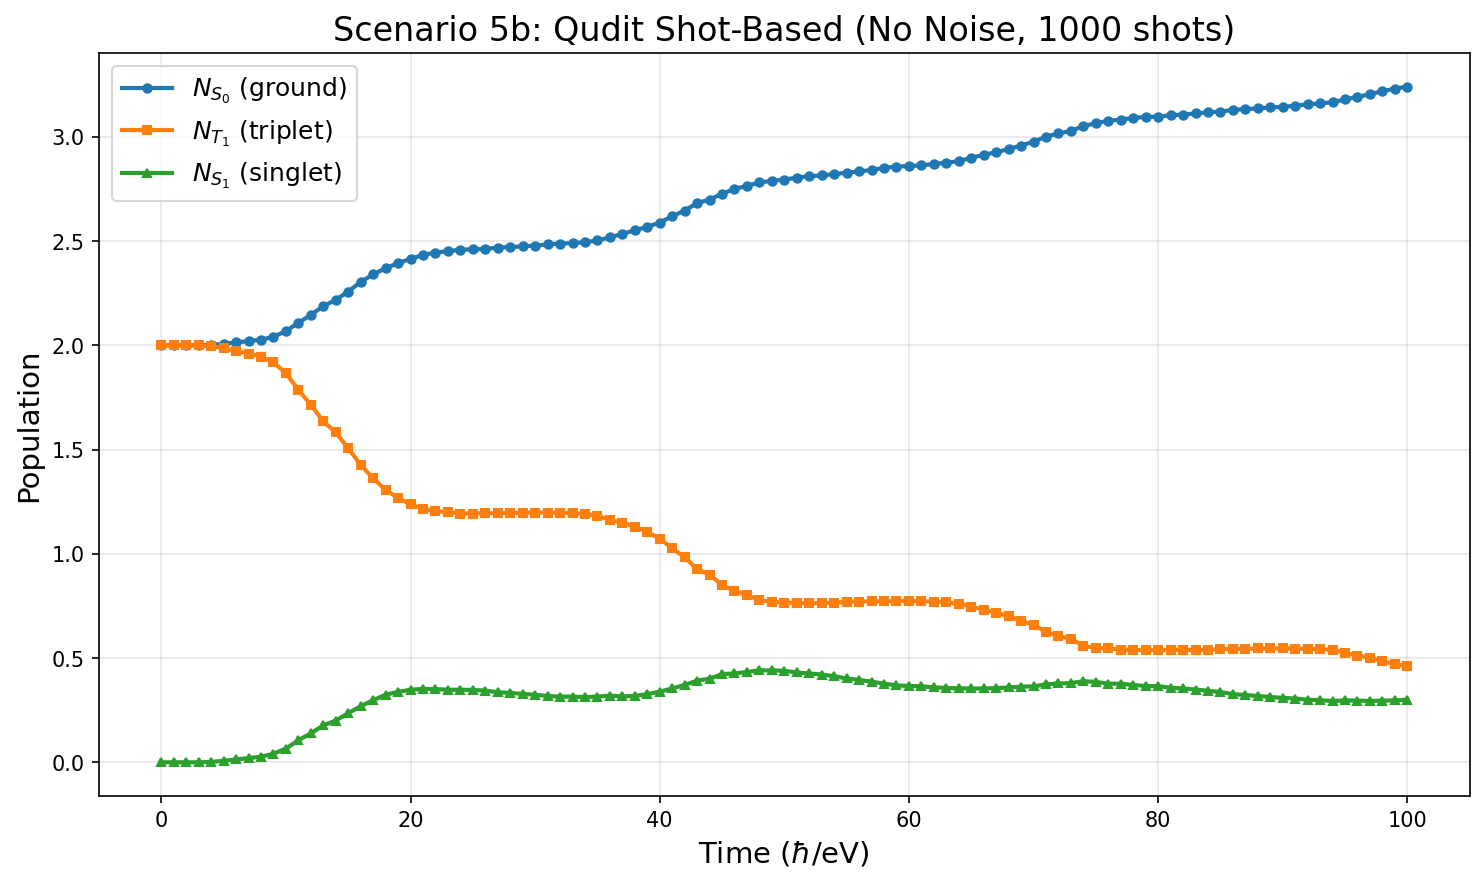

In [15]:
from qudit_gksl_shot_simulator import QuditGKSLShotSimulator
from IPython.display import display, Image

n_shots = 1000

sim5b = QuditGKSLShotSimulator(params)
result5b = sim5b.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result5b["elapsed_time"]:.2f}s')
print(f'Shots: {result5b["n_shots"]}')
print(f'System qutrits: {result5b["n_system_qudits"]}')
print(f'Ancilla qudits: {result5b["n_ancilla_qudits"]}')
print(f'Total qudits: {result5b["n_total_qudits"]}')
print(f'Estimated gates/step: {result5b["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result5b["total_estimated_gates"]}')
print(f'Final populations: N_S0={result5b["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result5b["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result5b["populations"][-1]["N_S1"]:.4f}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result5b["trace"]):.2e}')
print(f'Measurement counts (top 5): '
      f'{dict(sorted(result5b["counts"].items(), key=lambda x: -x[1])[:5])}')

plot_population_dynamics(result5b, title=f'Scenario 5b: Qudit Shot-Based (No Noise, {n_shots} shots)',
                         save_path='circuit_images/scenario5b_population.png')
display(Image(filename='circuit_images/scenario5b_population.png'))


### シナリオ5c: Qudit ショットベース（ノイズ有り）

各2-quditペアゲート（ハミルトニアンNN結合）の後にのみ、確率的な脱分極ノイズ ($p_{depol}=0.001$) を適用。
Weyl-Heisenberg演算子 $X^a Z^b$ の確率的適用による純粋状態レベルのノイズモデル。
位相緩和ノイズは使用しない（$p_{dephasing}=0.0$）。
単一サイトのLindbladチャネルにはノイズを適用しない（`depol_pair_only=True`）。

Elapsed time: 193.54s
Noise: p_depol=0.001, p_dephasing=0.0
Final populations: N_S0=2.6132, N_T1=0.7746, N_S1=0.6122


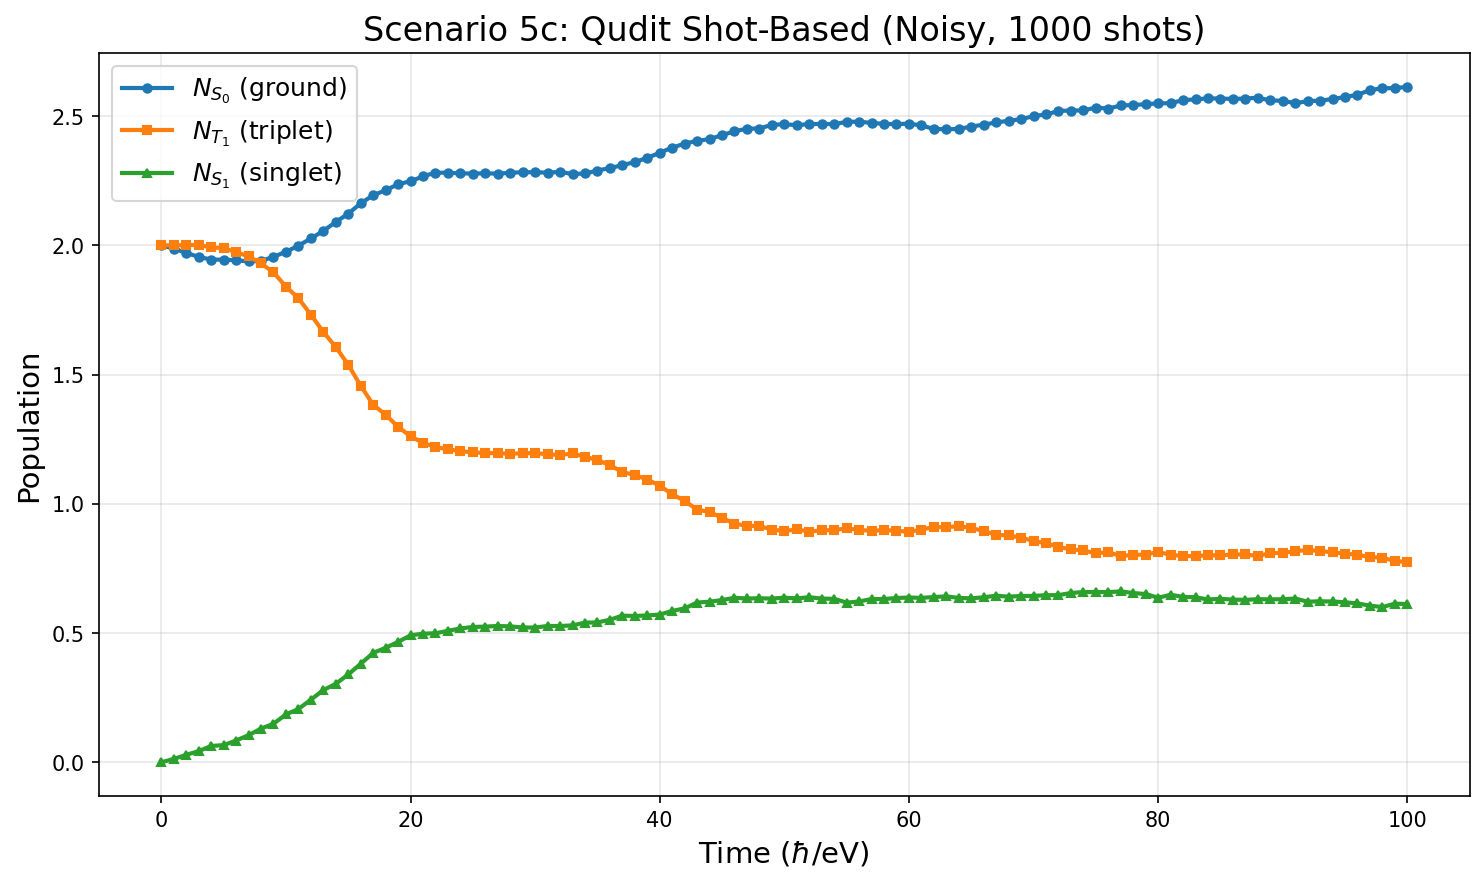

In [16]:
from qudit_gksl_shot_simulator import QuditGKSLNoisyShotSimulator
from IPython.display import display, Image

sim5c = QuditGKSLNoisyShotSimulator(params, p_depol=0.001, p_dephasing=0.0, depol_pair_only=True)
result5c = sim5c.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result5c["elapsed_time"]:.2f}s')
print(f'Noise: p_depol={result5c["noise_params"]["p_depol"]}, '
      f'p_dephasing={result5c["noise_params"]["p_dephasing"]}')
print(f'Final populations: N_S0={result5c["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result5c["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result5c["populations"][-1]["N_S1"]:.4f}')

plot_population_dynamics(result5c, title=f'Scenario 5c: Qudit Shot-Based (Noisy, {n_shots} shots)',
                         save_path='circuit_images/scenario5c_population.png')
display(Image(filename='circuit_images/scenario5c_population.png'))


### シナリオ3b: Qubit ショットベース（ノイズ無し）

2-qubitエンコーディングでのショットベースシミュレーション（理想ゲート）。

Elapsed time: 235.06s
Shots: 1000
System qubits: 8
Ancilla qubits: 26
Total qubits: 34
Estimated gates/step: 388
Total estimated gates: 38800
Final populations: N_S0=3.2400, N_T1=0.4600, N_S1=0.3000
Trace conservation: max|Tr-1| = 1.15e-14
Forbidden count: 0 / 1000
Measurement counts (top 5): {0: 426, 18: 134, 6: 125, 12: 111, 4: 38}


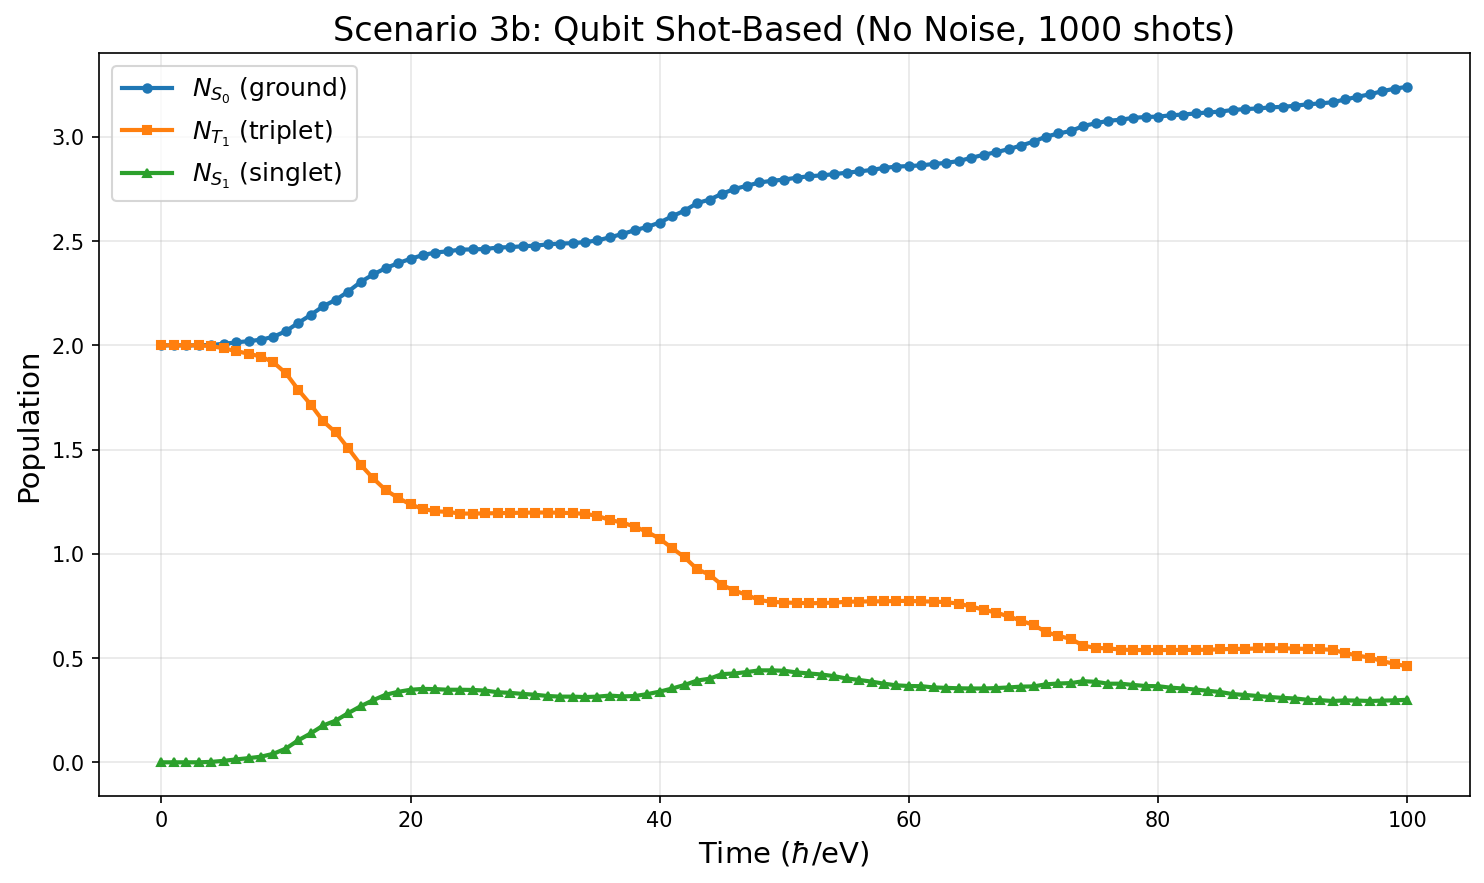

In [17]:
from qubit_gksl_shot_simulator import QubitGKSLShotSimulator
from IPython.display import display, Image

sim3b = QubitGKSLShotSimulator(params)
result3b = sim3b.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result3b["elapsed_time"]:.2f}s')
print(f'Shots: {result3b["n_shots"]}')
print(f'System qubits: {result3b["n_sys_qubits"]}')
print(f'Ancilla qubits: {result3b["n_ancilla"]}')
print(f'Total qubits: {result3b["n_total_qubits"]}')
print(f'Estimated gates/step: {result3b["estimated_gates_per_step"]}')
print(f'Total estimated gates: {result3b["total_estimated_gates"]}')
print(f'Final populations: N_S0={result3b["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result3b["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result3b["populations"][-1]["N_S1"]:.4f}')
print(f'Trace conservation: max|Tr-1| = {max(abs(t-1) for t in result3b["trace"]):.2e}')
print(f'Forbidden count: {result3b["forbidden_count"]} / {result3b["n_shots"]}')
print(f'Measurement counts (top 5): '
      f'{dict(sorted(result3b["counts"].items(), key=lambda x: -x[1])[:5])}')

plot_population_dynamics(result3b, title=f'Scenario 3b: Qubit Shot-Based (No Noise, {n_shots} shots)',
                         save_path='circuit_images/scenario3b_population.png')
display(Image(filename='circuit_images/scenario3b_population.png'))


### シナリオ3c: Qubit ショットベース（ノイズ有り）

各2-qubitペアゲート（ハミルトニアンNN結合）の後にのみ、確率的な脱分極ノイズ ($p_{depol}=0.001$) を適用。
位相緩和ノイズは使用しない（$p_{dephasing}=0.0$）。
単一サイトのLindbladチャネルにはノイズを適用しない（`depol_pair_only=True`）。

**CXゲートオーバーヘッド**: 実際のqubitハードウェアでは、各ペア相互作用を
多数のCX(CNOT)ゲートに分解する必要がある。各CXゲートが独立にp_depol=0.001の
脱分極ノイズを受けるため、ペアあたりの有効エラー率は:

$$p_{eff} = 1 - (1 - p_{depol})^{N_{CX}}$$

となり、qutritの単一ネイティブゲート（$p_{eff} = p_{depol}$）に比べて大幅に悪化する。

**GKSLモデルにおけるCXゲート数の選択**: GKSLモデルのハミルトニアンは
$H = H_0 + H_{transfer}$ のみを含み、TTAプロセスはLindblad演算子で実装される。
したがって、ハミルトニアンのCXゲート数は $H_{transfer}$ の分解から得られる
$N_{CX}^{transfer}$ を使用する。Lindbladペアチャネル（Stinespring拡張）の
CXゲート数は別途推定が必要だが、現時点では同じ $N_{CX}^{transfer}$ を近似値として使用する。


CXゲート数推定結果:
  H_transfer: 46 CXゲート
  H_TTA: 86 CXゲート (参考値: GKSLではLindblad実装)
  使用値: 46 CXゲート/ペア (H_transferのみ、GKSLハミルトニアンに基づく)
Elapsed time: 249.46s
Noise: p_depol=0.0010, p_depol_pair_eff=0.0450, cx_per_pair_gate=46.0
p_dephasing=0.0
Final populations: N_S0=0.4440, N_T1=0.4287, N_S1=0.4297
Tr(rho_final): 0.325596 (1.0 = no leakage)
Forbidden state count (final measurement): 669/1000
Max trace deficit (leakage): 0.7038 (70.4%)


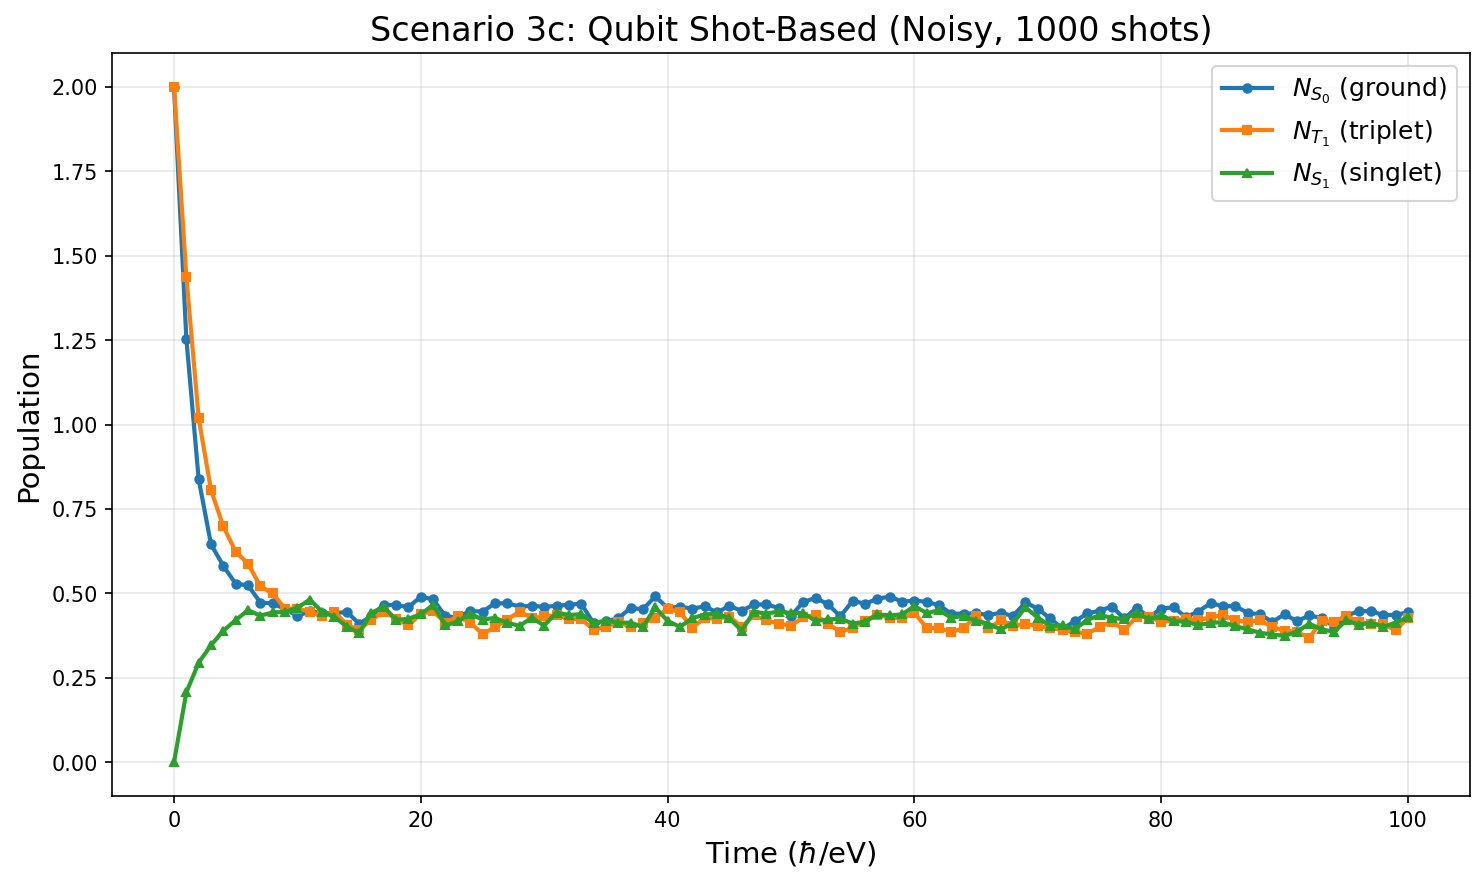

In [18]:
from qubit_gksl_shot_simulator import QubitGKSLNoisyShotSimulator
from qubit_noisy_simulator import QubitMolecularDynamicsSimulatorNoisy
from IPython.display import display, Image

# CXゲート数の推定（Qiskitトランスパイラによる分解）
cx_info = QubitMolecularDynamicsSimulatorNoisy.estimate_cx_per_pair_gate(
    V=params.V, J=params.gamma_TTA, dt=t_max/n_steps_quantum, hbar=params.hbar
)
print(f"CXゲート数推定結果:")
print(f"  H_transfer: {cx_info['cx_transfer']} CXゲート")
print(f"  H_TTA: {cx_info['cx_tta']} CXゲート (参考値: GKSLではLindblad実装)")

# GKSLモデルのハミルトニアンは H_0 + H_transfer のみ（H_TTAなし）。
# TTAはLindblad演算子で実装されるため、ハミルトニアンのCXオーバーヘッドは
# H_transferの分解結果のみを使用する。
cx_per_pair = cx_info['cx_transfer']
print(f"  使用値: {cx_per_pair} CXゲート/ペア (H_transferのみ、GKSLハミルトニアンに基づく)")

sim3c = QubitGKSLNoisyShotSimulator(
    params, p_depol=0.001, p_dephasing=0.0, depol_pair_only=True,
    cx_per_pair_gate=cx_per_pair
)
result3c = sim3c.simulate(
    t_max=t_max, n_steps=n_steps_quantum,
    initial_state='edge_triplet', n_shots=n_shots, seed=42,
)

print(f'Elapsed time: {result3c["elapsed_time"]:.2f}s')
print(f'Noise: p_depol={result3c["noise_params"]["p_depol"]:.4f}, '
      f'p_depol_pair_eff={result3c["noise_params"]["p_depol_pair_eff"]:.4f}, '
      f'cx_per_pair_gate={result3c["noise_params"]["cx_per_pair_gate"]:.1f}')
print(f'p_dephasing={result3c["noise_params"]["p_dephasing"]}')
print(f'Final populations: N_S0={result3c["populations"][-1]["N_S0"]:.4f}, '
      f'N_T1={result3c["populations"][-1]["N_T1"]:.4f}, '
      f'N_S1={result3c["populations"][-1]["N_S1"]:.4f}')

# Forbidden-state leakage diagnostics (unique to qubit encoding)
tr_final = float(np.real(np.trace(result3c['rho_final'])))
max_trace_deficit = max(1.0 - t for t in result3c['trace'] if t < 1.0) if any(t < 1.0 for t in result3c['trace']) else 0.0
print(f'Tr(rho_final): {tr_final:.6f} (1.0 = no leakage)')
print(f'Forbidden state count (final measurement): {result3c["forbidden_count"]}/{n_shots}')
print(f'Max trace deficit (leakage): {max_trace_deficit:.4f} ({max_trace_deficit*100:.1f}%)')

plot_population_dynamics(result3c, title=f'Scenario 3c: Qubit Shot-Based (Noisy, {n_shots} shots)',
                         save_path='circuit_images/scenario3c_population.png')
display(Image(filename='circuit_images/scenario3c_population.png'))


### ショットベース vs 密度行列シミュレーションの比較

密度行列（Statevector）結果とショットベース結果の人口動態を比較します。
ショットベース（ノイズ無し）は無限ショット極限で密度行列結果に収束します。
ノイズ有りの結果はハードウェアノイズの影響で乖離します。

**ノイズモデルの統一**: 脱分極ノイズのみ（$p_{depol}=0.001$）を2-qudit/2-qubitペアゲート（ハミルトニアンNN結合）にのみ適用。
位相緩和（dephasing）は使用しない。単一サイトLindbladチャネルにはノイズを適用しない（`depol_pair_only=True`）。
これにより `quantum_dynamics_complete_comparison.ipynb` のノイズモデルと統一された条件での比較が可能。

**注意: Qubit noisy（シナリオ3c）の禁止状態リーケージ**

Qubitエンコーディング（2-qubit/分子: |00⟩=S0, |01⟩=T1, |10⟩=S1, |11⟩=禁止）では、
2-qubitパウリノイズが物理状態→禁止状態 |11⟩ へのリーケージを引き起こします。
これは実際のqubit量子コンピュータで発生する現象を正しくモデル化しています。

- **Qudit noisy（5c）**: Weyl-Heisenberg演算子はd=3空間内で完結、Tr(ρ)=1が厳密保存
- **Qubit noisy（3c）**: パウリ演算子はd=4空間で作用、Tr(ρ)<1（リーケージ分だけ減少）

忠実度比較では、サブノーマライズされた密度行列をノーマライズしてから計算します
（物理部分空間に留まった場合の条件付き状態に対する忠実度）。

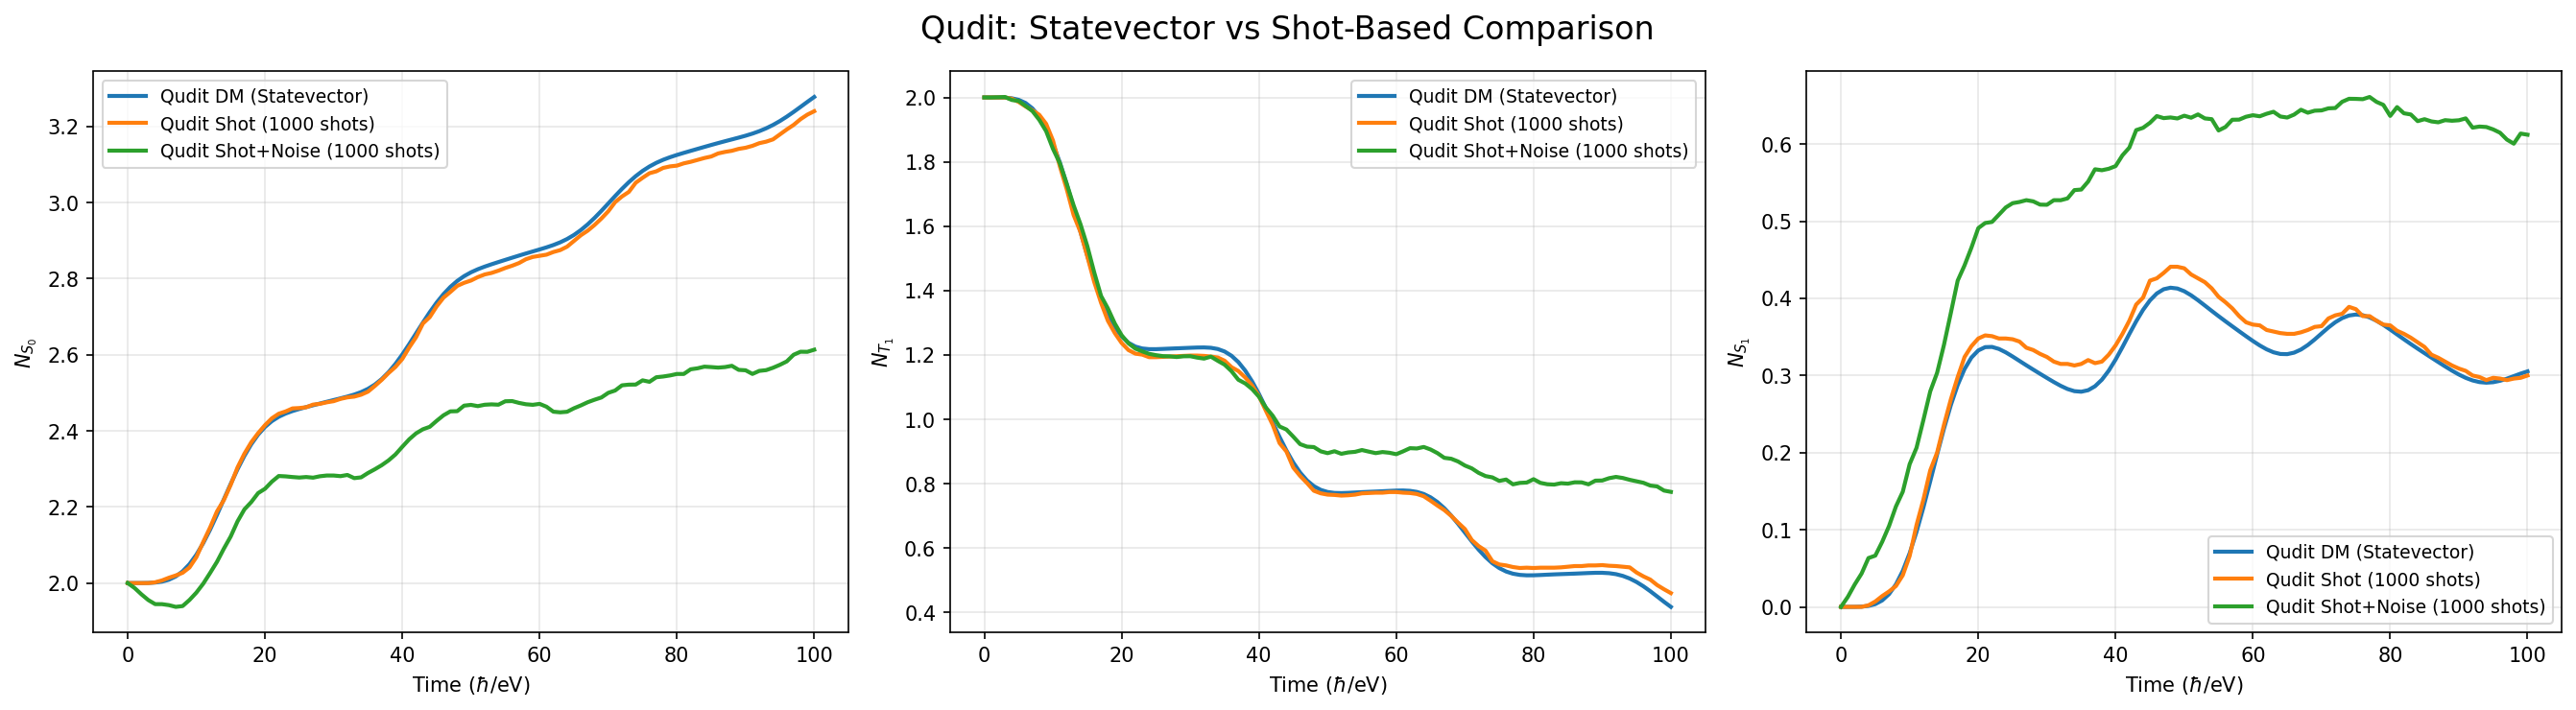

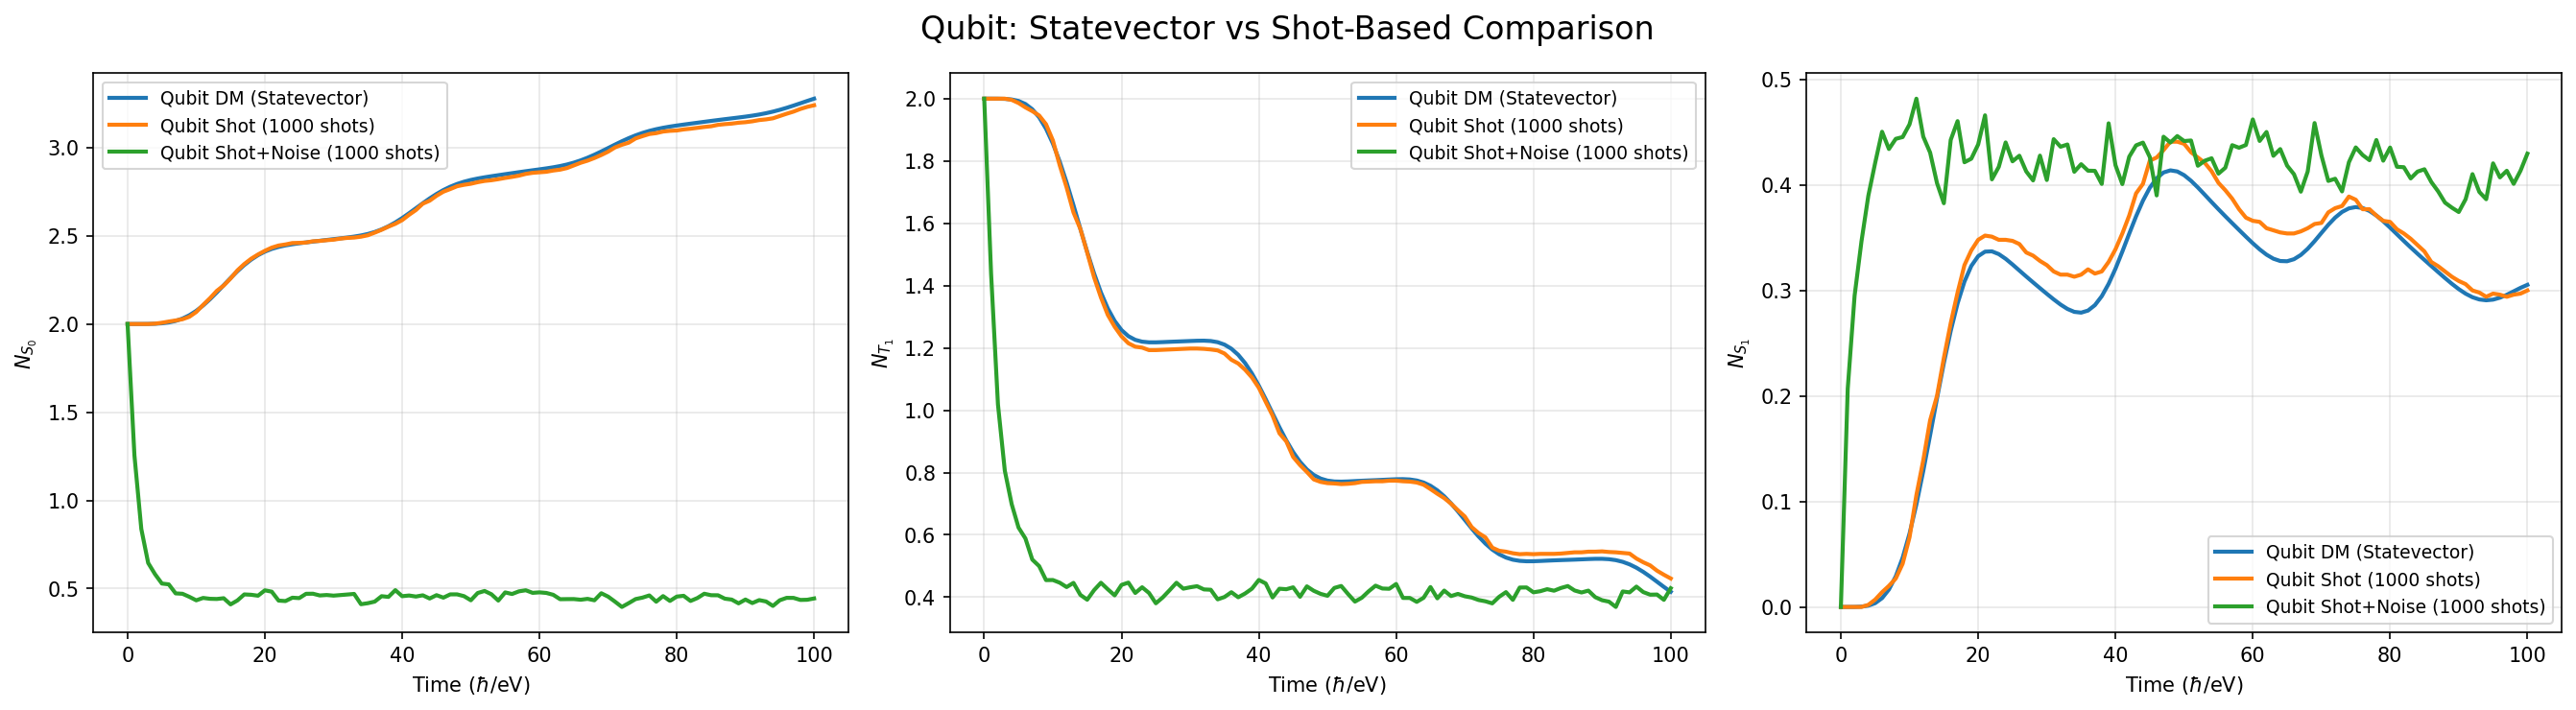

=== Statevector vs Shot-Based Fidelity ===
  Qudit DM vs Qudit Shot (no noise): F = 0.998056
  Qubit DM vs Qubit Shot (no noise): F = 0.998056

=== Noisy Fidelity (raw vs normalized) ===
  Qudit noisy: Tr(rho)=1.000000, F_raw=0.534629, F_norm=0.534629
  Qubit noisy: Tr(rho)=0.325596, F_raw=0.032488, F_norm=0.099780

  Note: For qubit noisy, F_raw correctly includes the forbidden-state leakage penalty (Tr<1).
  F_norm normalizes the sub-normalized matrix first, giving the conditional fidelity
  (fidelity conditioned on remaining in the physical subspace, removing the leakage penalty).


In [19]:
from gksl_visualization import compare_multiple_scenarios
from IPython.display import display, Image

# Qudit comparison: Statevector vs Shot-based (no noise) vs Shot-based (noisy)
results_qudit_shot = {
    'Qudit DM (Statevector)': result5,
    f'Qudit Shot ({n_shots} shots)': result5b,
    f'Qudit Shot+Noise ({n_shots} shots)': result5c,
}
compare_multiple_scenarios(
    results_qudit_shot,
    title='Qudit: Statevector vs Shot-Based Comparison',
    save_path='circuit_images/comparison_qudit_shot.png',
)
display(Image(filename='circuit_images/comparison_qudit_shot.png'))

# Qubit comparison: Statevector vs Shot-based (no noise) vs Shot-based (noisy)
results_qubit_shot = {
    'Qubit DM (Statevector)': result3,
    f'Qubit Shot ({n_shots} shots)': result3b,
    f'Qubit Shot+Noise ({n_shots} shots)': result3c,
}
compare_multiple_scenarios(
    results_qubit_shot,
    title='Qubit: Statevector vs Shot-Based Comparison',
    save_path='circuit_images/comparison_qubit_shot.png',
)
display(Image(filename='circuit_images/comparison_qubit_shot.png'))

# Helper: normalize density matrix for fidelity computation
def _normalize_rho(rho):
    tr = float(np.real(np.trace(rho)))
    return rho / tr if tr > 1e-10 else rho

# Fidelity between statevector and shot-based results
F_qudit_shot = quantum_fidelity(result5['rho_final'], result5b['rho_final'])
F_qubit_shot = quantum_fidelity(result3['rho_final'], result3b['rho_final'])

# For noisy scenarios, compute both raw and normalized fidelity
# Raw: directly compare (affected by trace deficit for qubit noisy)
# Normalized: normalize sub-normalized matrices first (conditional fidelity)
F_qudit_noisy_raw = quantum_fidelity(result5['rho_final'], result5c['rho_final'])
F_qubit_noisy_raw = quantum_fidelity(result3['rho_final'], result3c['rho_final'])

rho5_norm = _normalize_rho(result5['rho_final'])
rho5c_norm = _normalize_rho(result5c['rho_final'])
rho3_norm = _normalize_rho(result3['rho_final'])
rho3c_norm = _normalize_rho(result3c['rho_final'])
F_qudit_noisy_norm = quantum_fidelity(rho5_norm, rho5c_norm)
F_qubit_noisy_norm = quantum_fidelity(rho3_norm, rho3c_norm)

tr_qudit_noisy = float(np.real(np.trace(result5c['rho_final'])))
tr_qubit_noisy = float(np.real(np.trace(result3c['rho_final'])))

print('=== Statevector vs Shot-Based Fidelity ===')
print(f'  Qudit DM vs Qudit Shot (no noise): F = {F_qudit_shot:.6f}')
print(f'  Qubit DM vs Qubit Shot (no noise): F = {F_qubit_shot:.6f}')
print()
print('=== Noisy Fidelity (raw vs normalized) ===')
print(f'  Qudit noisy: Tr(rho)={tr_qudit_noisy:.6f}, F_raw={F_qudit_noisy_raw:.6f}, F_norm={F_qudit_noisy_norm:.6f}')
print(f'  Qubit noisy: Tr(rho)={tr_qubit_noisy:.6f}, F_raw={F_qubit_noisy_raw:.6f}, F_norm={F_qubit_noisy_norm:.6f}')
print()
print('  Note: For qubit noisy, F_raw correctly includes the forbidden-state leakage penalty (Tr<1).')
print('  F_norm normalizes the sub-normalized matrix first, giving the conditional fidelity')
print('  (fidelity conditioned on remaining in the physical subspace, removing the leakage penalty).')

### 9c. ユニタリTTA vs 散逸TTA の比較（ショットベースシミュレーション付き）

セクション9bでは密度行列レベルの厳密なシミュレーションでユニタリTTAと散逸TTAを比較しました。
ここでは、ショットベースシミュレーション（ノイズ無し・ノイズ有り）の結果を追加して、
量子回路実装レベルでの比較を行います。

#### 比較対象

| ケース | 手法 | ノイズ | データソース |
|--------|------|--------|-------------|
| A: ユニタリTTA | 厳密密度行列 | - | `simulate_unitary_tta()` (9b) |
| C: 全散逸GKSL (DM) | 古典GKSL密度行列 | - | `ClassicalGKSLSimulator` (シナリオ1) |
| C: Qudit DM | Stinespring密度行列 | なし | `QuditGKSLSimulator` (シナリオ5) |
| C: Qudit Shot | Stinespring+Trotter | なし | `QuditGKSLShotSimulator` (5b) |
| C: Qudit Shot+Noise | Stinespring+Trotter | 脱分極のみ（ペアゲートのみ） | `QuditGKSLNoisyShotSimulator` (5c) |
| C: Qubit DM | Stinespring密度行列 | なし | `QubitGKSLSimulator` (シナリオ3) |
| C: Qubit Shot | Stinespring+Trotter | なし | `QubitGKSLShotSimulator` (3b) |
| C: Qubit Shot+Noise | Stinespring+Trotter | 脱分極のみ（ペアゲートのみ） | `QubitGKSLNoisyShotSimulator` (3c) |

#### 目的

1. ユニタリTTA（コヒーレント振動）と散逸GKSL（不可逆減衰）の定性的な違いを、ショットベースシミュレーションでも確認
2. ショットノイズ（有限ショット数）の影響を定量化
3. ハードウェアノイズ（脱分極のみ、ペアゲートのみ）の追加的影響を評価
4. Qudit vs Qubit実装の違いを明確化

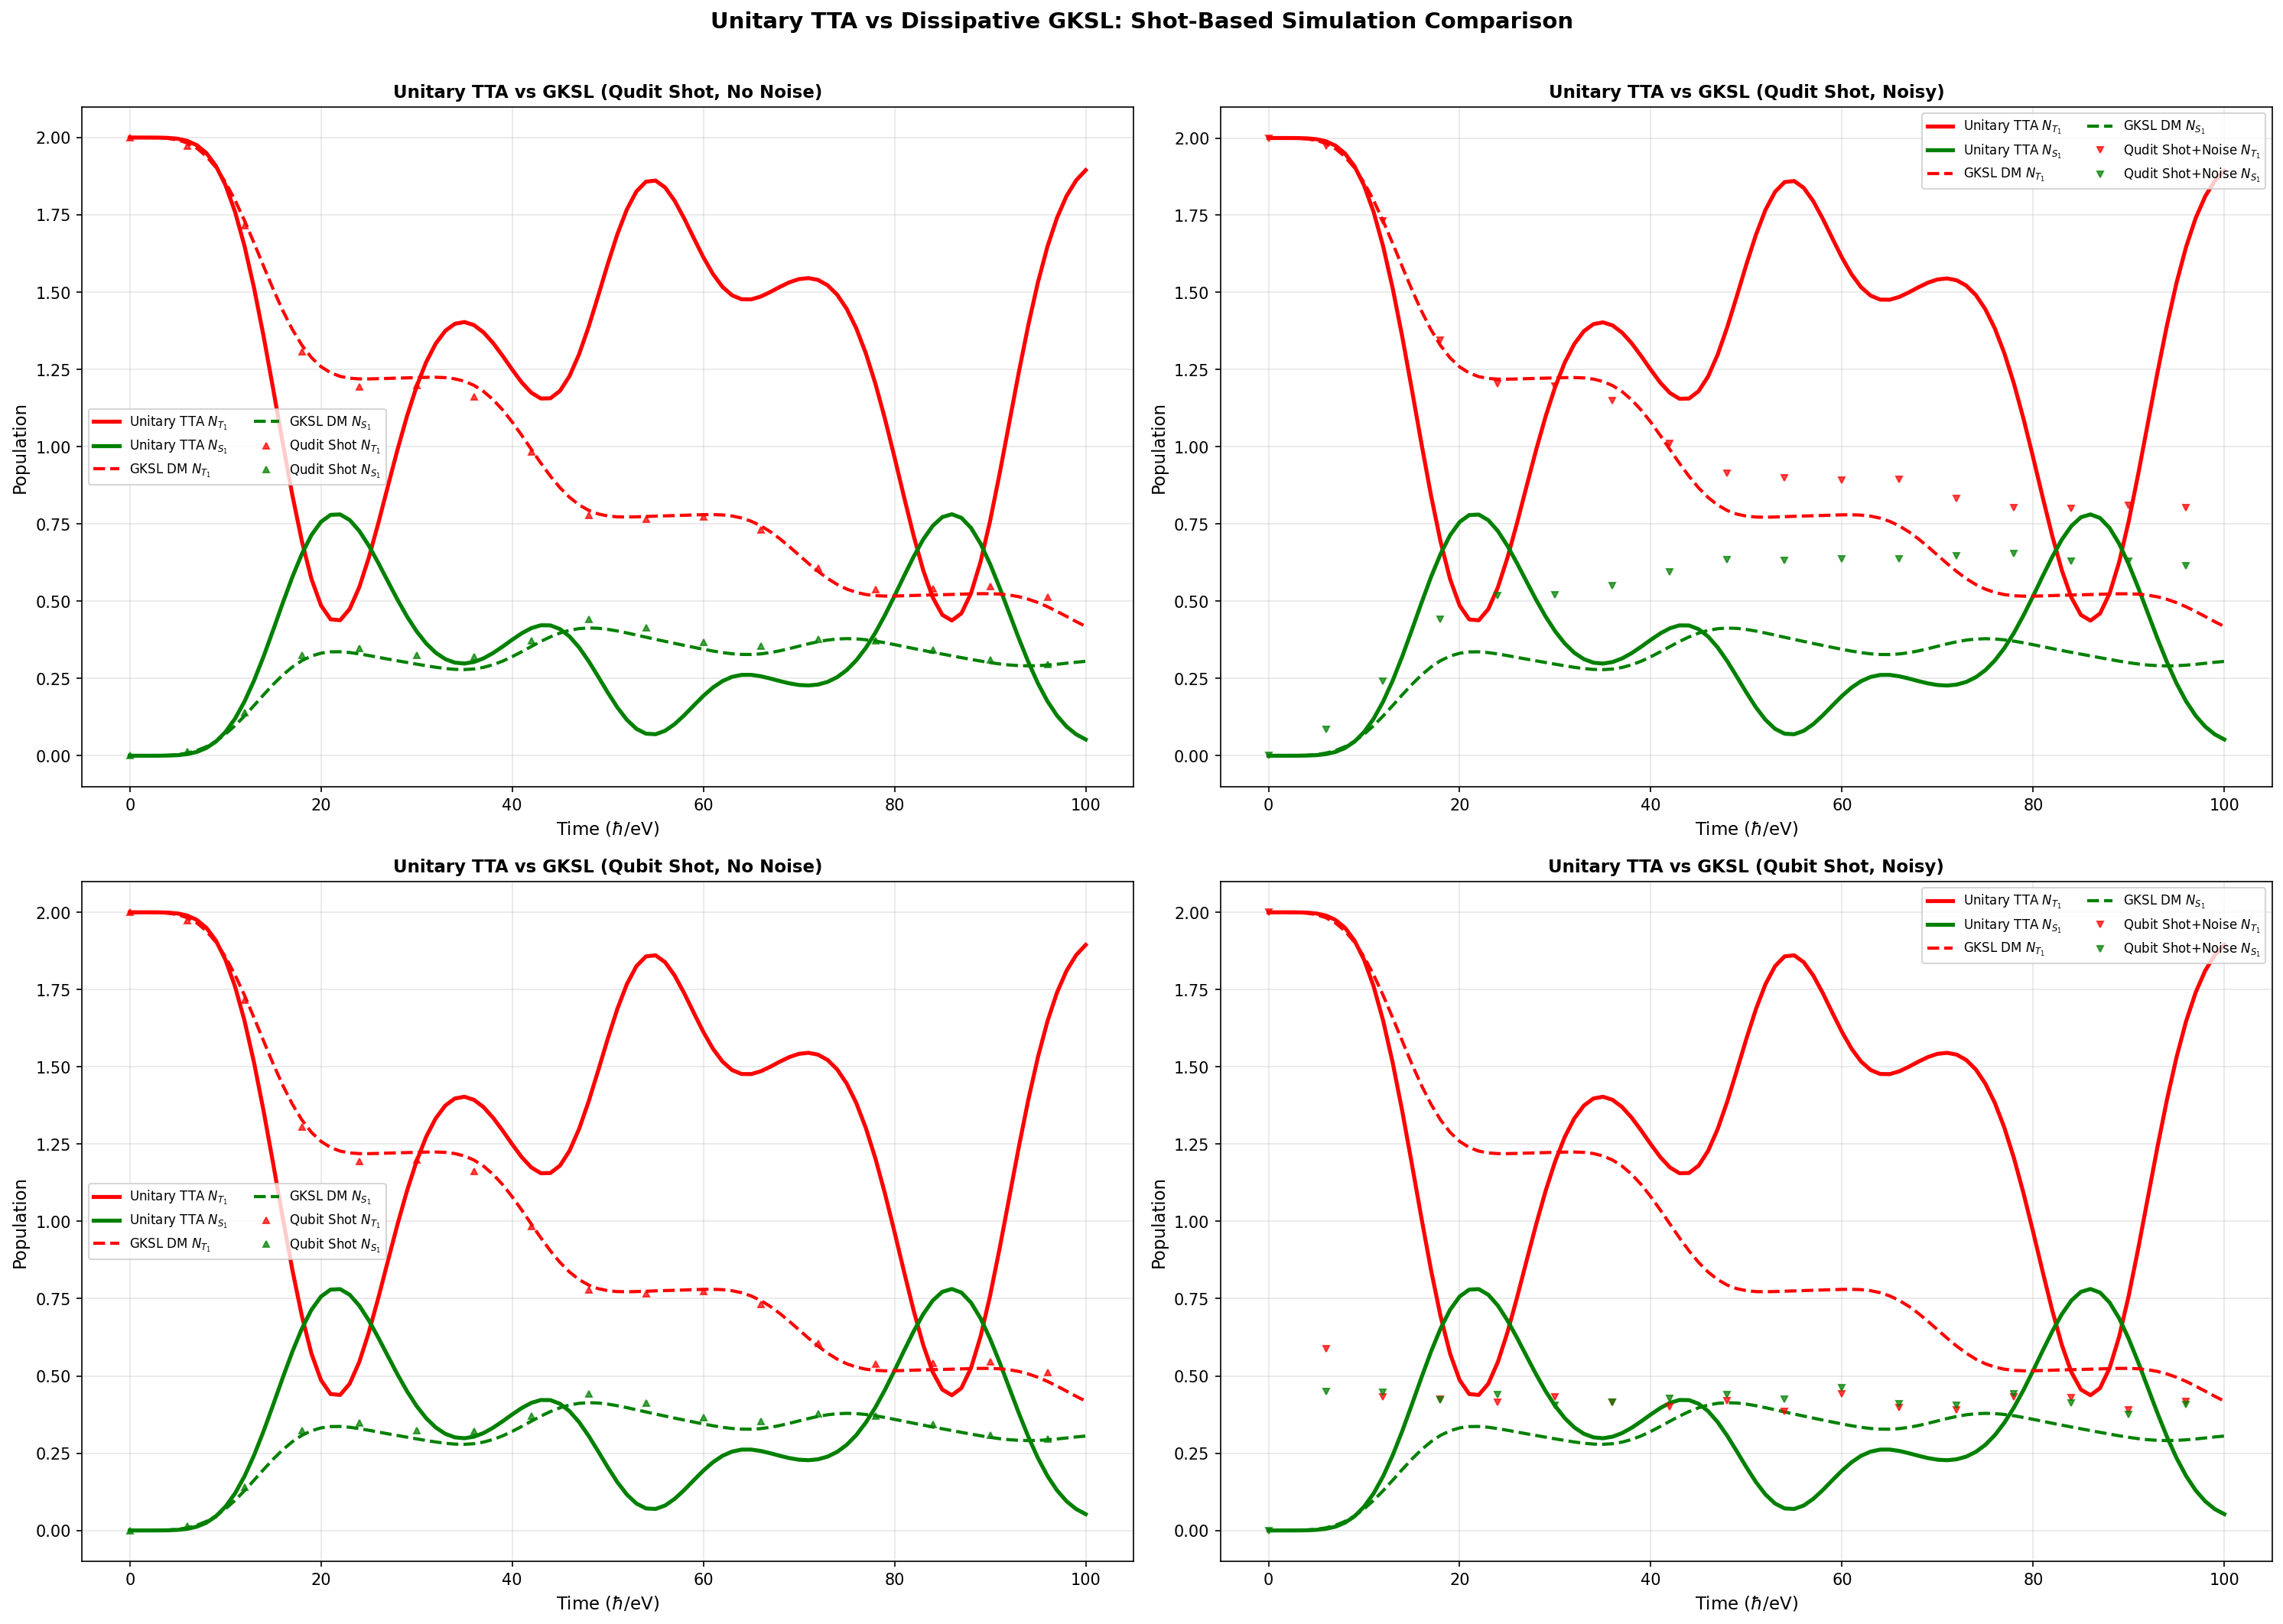

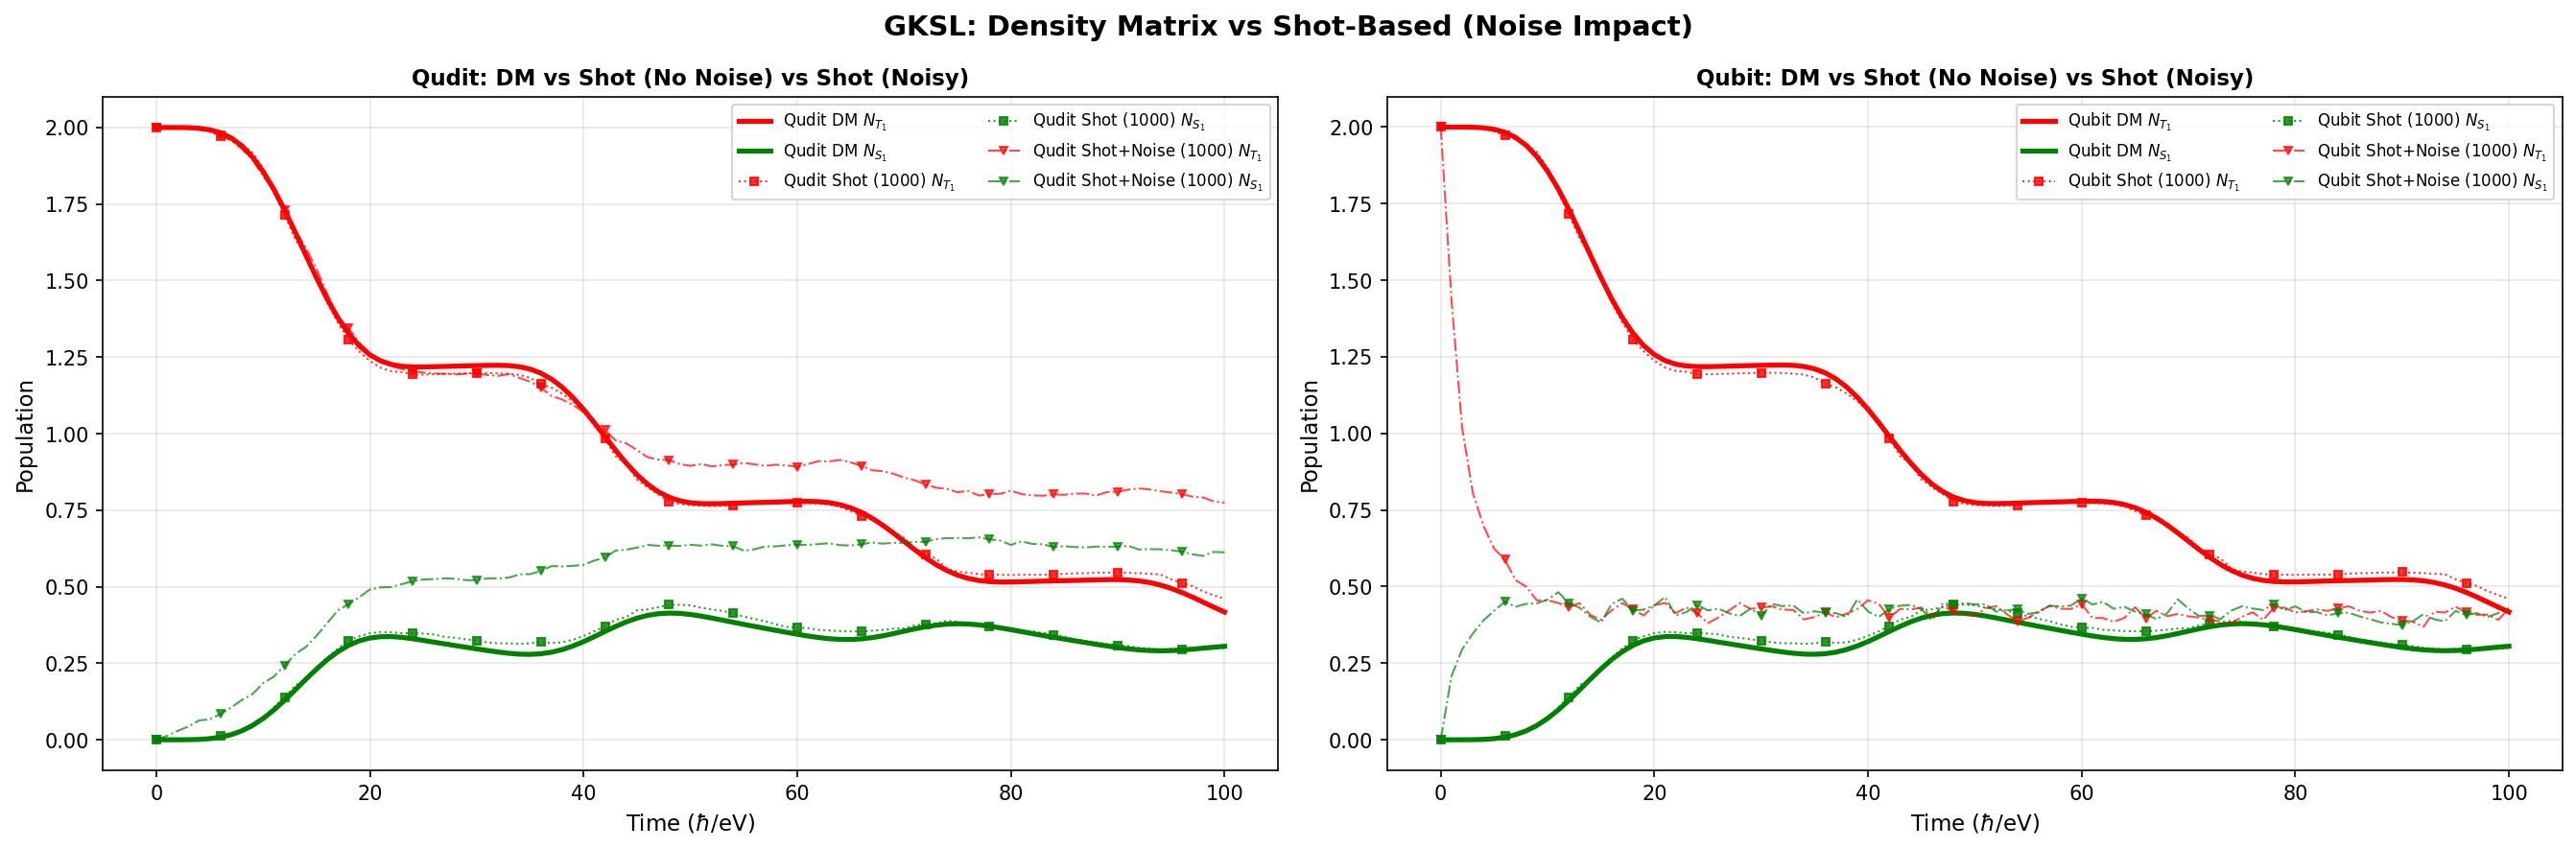


Shot-Based Comparison Summary: Unitary TTA vs Dissipative GKSL
                                     N_T1(final)  N_S1(final)  N_S0(final)
----------------------------------------------------------------------------------------------------
A: Unitary TTA (exact)                    1.8946       0.0527       2.0527
C: GKSL DM (Classical)                    0.4184       0.3054       3.2762
C: Qudit DM (Stinespring)                 0.4172       0.3053       3.2774
C: Qudit Shot (1000)                      0.4600       0.3000       3.2400
C: Qudit Shot+Noise (1000)                0.7746       0.6122       2.6132
C: Qubit DM (Stinespring)                 0.4172       0.3053       3.2774
C: Qubit Shot (1000)                      0.4600       0.3000       3.2400
C: Qubit Shot+Noise (1000)                0.4287       0.4297       0.4440

Key observations:
  1. Unitary TTA shows coherent oscillation (constant entropy), while GKSL shows irreversible decay.
  2. Shot-based (no noise) results close

In [20]:
# ユニタリTTA vs 散逸TTA: ショットベース比較

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image

os.makedirs("circuit_images", exist_ok=True)

# === Plot 1: Qudit — DM vs Shot (No Noise) vs Shot (Noisy) ===
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# --- Top-left: Unitary TTA vs Full GKSL (DM) vs Qudit Shot (No Noise) ---
ax = axes[0, 0]
times_u = result_unitary_tta['times']
ax.plot(times_u, [p['N_T1'] for p in result_unitary_tta['populations']],
        'r-', linewidth=2.5, label='Unitary TTA $N_{T_1}$')
ax.plot(times_u, [p['N_S1'] for p in result_unitary_tta['populations']],
        'g-', linewidth=2.5, label='Unitary TTA $N_{S_1}$')

times_c = result1['times']
ax.plot(times_c, [p['N_T1'] for p in result1['populations']],
        'r--', linewidth=2, label='GKSL DM $N_{T_1}$')
ax.plot(times_c, [p['N_S1'] for p in result1['populations']],
        'g--', linewidth=2, label='GKSL DM $N_{S_1}$')

times_5b = result5b['times']
me = max(1, len(times_5b) // 15)
ax.plot(times_5b, [p['N_T1'] for p in result5b['populations']],
        'r^', markersize=4, markevery=me, linestyle='none', label='Qudit Shot $N_{T_1}$', alpha=0.7)
ax.plot(times_5b, [p['N_S1'] for p in result5b['populations']],
        'g^', markersize=4, markevery=me, linestyle='none', label='Qudit Shot $N_{S_1}$', alpha=0.7)

ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Unitary TTA vs GKSL (Qudit Shot, No Noise)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# --- Top-right: Unitary TTA vs Full GKSL (DM) vs Qudit Shot (Noisy) ---
ax = axes[0, 1]
ax.plot(times_u, [p['N_T1'] for p in result_unitary_tta['populations']],
        'r-', linewidth=2.5, label='Unitary TTA $N_{T_1}$')
ax.plot(times_u, [p['N_S1'] for p in result_unitary_tta['populations']],
        'g-', linewidth=2.5, label='Unitary TTA $N_{S_1}$')

ax.plot(times_c, [p['N_T1'] for p in result1['populations']],
        'r--', linewidth=2, label='GKSL DM $N_{T_1}$')
ax.plot(times_c, [p['N_S1'] for p in result1['populations']],
        'g--', linewidth=2, label='GKSL DM $N_{S_1}$')

times_5c = result5c['times']
me5c = max(1, len(times_5c) // 15)
ax.plot(times_5c, [p['N_T1'] for p in result5c['populations']],
        'rv', markersize=4, markevery=me5c, linestyle='none', label='Qudit Shot+Noise $N_{T_1}$', alpha=0.7)
ax.plot(times_5c, [p['N_S1'] for p in result5c['populations']],
        'gv', markersize=4, markevery=me5c, linestyle='none', label='Qudit Shot+Noise $N_{S_1}$', alpha=0.7)

ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Unitary TTA vs GKSL (Qudit Shot, Noisy)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# --- Bottom-left: Unitary TTA vs Full GKSL (DM) vs Qubit Shot (No Noise) ---
ax = axes[1, 0]
ax.plot(times_u, [p['N_T1'] for p in result_unitary_tta['populations']],
        'r-', linewidth=2.5, label='Unitary TTA $N_{T_1}$')
ax.plot(times_u, [p['N_S1'] for p in result_unitary_tta['populations']],
        'g-', linewidth=2.5, label='Unitary TTA $N_{S_1}$')

ax.plot(times_c, [p['N_T1'] for p in result1['populations']],
        'r--', linewidth=2, label='GKSL DM $N_{T_1}$')
ax.plot(times_c, [p['N_S1'] for p in result1['populations']],
        'g--', linewidth=2, label='GKSL DM $N_{S_1}$')

times_3b = result3b['times']
me3b = max(1, len(times_3b) // 15)
ax.plot(times_3b, [p['N_T1'] for p in result3b['populations']],
        'r^', markersize=4, markevery=me3b, linestyle='none', label='Qubit Shot $N_{T_1}$', alpha=0.7)
ax.plot(times_3b, [p['N_S1'] for p in result3b['populations']],
        'g^', markersize=4, markevery=me3b, linestyle='none', label='Qubit Shot $N_{S_1}$', alpha=0.7)

ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Unitary TTA vs GKSL (Qubit Shot, No Noise)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# --- Bottom-right: Unitary TTA vs Full GKSL (DM) vs Qubit Shot (Noisy) ---
ax = axes[1, 1]
ax.plot(times_u, [p['N_T1'] for p in result_unitary_tta['populations']],
        'r-', linewidth=2.5, label='Unitary TTA $N_{T_1}$')
ax.plot(times_u, [p['N_S1'] for p in result_unitary_tta['populations']],
        'g-', linewidth=2.5, label='Unitary TTA $N_{S_1}$')

ax.plot(times_c, [p['N_T1'] for p in result1['populations']],
        'r--', linewidth=2, label='GKSL DM $N_{T_1}$')
ax.plot(times_c, [p['N_S1'] for p in result1['populations']],
        'g--', linewidth=2, label='GKSL DM $N_{S_1}$')

times_3c = result3c['times']
me3c = max(1, len(times_3c) // 15)
ax.plot(times_3c, [p['N_T1'] for p in result3c['populations']],
        'rv', markersize=4, markevery=me3c, linestyle='none', label='Qubit Shot+Noise $N_{T_1}$', alpha=0.7)
ax.plot(times_3c, [p['N_S1'] for p in result3c['populations']],
        'gv', markersize=4, markevery=me3c, linestyle='none', label='Qubit Shot+Noise $N_{S_1}$', alpha=0.7)

ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Unitary TTA vs GKSL (Qubit Shot, Noisy)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

fig.suptitle(
    'Unitary TTA vs Dissipative GKSL: Shot-Based Simulation Comparison',
    fontsize=14, fontweight='bold', y=1.01,
)
plt.tight_layout()
save_path = 'circuit_images/tta_vs_gksl_shot_comparison.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=save_path))

# === Plot 2: Noise impact on GKSL results ===
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))

# Qudit: No noise vs Noisy
ax = axes2[0]
ax.plot(result5['times'], [p['N_T1'] for p in result5['populations']],
        'r-', linewidth=2.5, label='Qudit DM $N_{T_1}$')
ax.plot(result5['times'], [p['N_S1'] for p in result5['populations']],
        'g-', linewidth=2.5, label='Qudit DM $N_{S_1}$')

me5b = max(1, len(result5b['times']) // 15)
ax.plot(result5b['times'], [p['N_T1'] for p in result5b['populations']],
        'rs', markersize=4, markevery=me5b, linestyle=':', linewidth=1,
        label=f'Qudit Shot ({n_shots}) $N_{{T_1}}$', alpha=0.8)
ax.plot(result5b['times'], [p['N_S1'] for p in result5b['populations']],
        'gs', markersize=4, markevery=me5b, linestyle=':', linewidth=1,
        label=f'Qudit Shot ({n_shots}) $N_{{S_1}}$', alpha=0.8)

me5c = max(1, len(result5c['times']) // 15)
ax.plot(result5c['times'], [p['N_T1'] for p in result5c['populations']],
        'rv', markersize=4, markevery=me5c, linestyle='-.', linewidth=1,
        label=f'Qudit Shot+Noise ({n_shots}) $N_{{T_1}}$', alpha=0.7)
ax.plot(result5c['times'], [p['N_S1'] for p in result5c['populations']],
        'gv', markersize=4, markevery=me5c, linestyle='-.', linewidth=1,
        label=f'Qudit Shot+Noise ({n_shots}) $N_{{S_1}}$', alpha=0.7)

ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Qudit: DM vs Shot (No Noise) vs Shot (Noisy)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Qubit: No noise vs Noisy
ax = axes2[1]
ax.plot(result3['times'], [p['N_T1'] for p in result3['populations']],
        'r-', linewidth=2.5, label='Qubit DM $N_{T_1}$')
ax.plot(result3['times'], [p['N_S1'] for p in result3['populations']],
        'g-', linewidth=2.5, label='Qubit DM $N_{S_1}$')

me3b = max(1, len(result3b['times']) // 15)
ax.plot(result3b['times'], [p['N_T1'] for p in result3b['populations']],
        'rs', markersize=4, markevery=me3b, linestyle=':', linewidth=1,
        label=f'Qubit Shot ({n_shots}) $N_{{T_1}}$', alpha=0.8)
ax.plot(result3b['times'], [p['N_S1'] for p in result3b['populations']],
        'gs', markersize=4, markevery=me3b, linestyle=':', linewidth=1,
        label=f'Qubit Shot ({n_shots}) $N_{{S_1}}$', alpha=0.8)

me3c = max(1, len(result3c['times']) // 15)
ax.plot(result3c['times'], [p['N_T1'] for p in result3c['populations']],
        'rv', markersize=4, markevery=me3c, linestyle='-.', linewidth=1,
        label=f'Qubit Shot+Noise ({n_shots}) $N_{{T_1}}$', alpha=0.7)
ax.plot(result3c['times'], [p['N_S1'] for p in result3c['populations']],
        'gv', markersize=4, markevery=me3c, linestyle='-.', linewidth=1,
        label=f'Qubit Shot+Noise ({n_shots}) $N_{{S_1}}$', alpha=0.7)

ax.set_xlabel(r'Time ($\hbar$/eV)', fontsize=11)
ax.set_ylabel('Population', fontsize=11)
ax.set_title('Qubit: DM vs Shot (No Noise) vs Shot (Noisy)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

fig2.suptitle(
    'GKSL: Density Matrix vs Shot-Based (Noise Impact)',
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
save_path2 = 'circuit_images/gksl_noise_impact_shot_comparison.png'
fig2.savefig(save_path2, dpi=150, bbox_inches='tight')
plt.close(fig2)
display(Image(filename=save_path2))

# === Summary table ===
print('\n' + '=' * 100)
print('Shot-Based Comparison Summary: Unitary TTA vs Dissipative GKSL')
print('=' * 100)
print(f'{"":<35s} {"N_T1(final)":>12s} {"N_S1(final)":>12s} {"N_S0(final)":>12s}')
print('-' * 100)

summary_data = [
    ('A: Unitary TTA (exact)', result_unitary_tta),
    ('C: GKSL DM (Classical)', result1),
    ('C: Qudit DM (Stinespring)', result5),
    (f'C: Qudit Shot ({n_shots})', result5b),
    (f'C: Qudit Shot+Noise ({n_shots})', result5c),
    ('C: Qubit DM (Stinespring)', result3),
    (f'C: Qubit Shot ({n_shots})', result3b),
    (f'C: Qubit Shot+Noise ({n_shots})', result3c),
]

for label, result in summary_data:
    pop = result['populations'][-1]
    print(f'{label:<35s} {pop["N_T1"]:12.4f} {pop["N_S1"]:12.4f} {pop["N_S0"]:12.4f}')

print('=' * 100)
print()
print('Key observations:')
print('  1. Unitary TTA shows coherent oscillation (constant entropy), while GKSL shows irreversible decay.')
print('  2. Shot-based (no noise) results closely follow density matrix results (shot noise only).')
print('  3. Shot-based (noisy) results show additional decoherence from hardware noise.')
print('  4. Qudit implementation uses fewer gates than Qubit, resulting in smaller noise accumulation.')
print('  5. Qubit noisy results may show forbidden-state leakage (Tr(rho) < 1).')


## 13. まとめ

### 各シナリオの特徴

| シナリオ | Hilbert空間次元 | 量子資源 | シミュレーション方式 | 特徴 |
|----------|---------------|---------|---------------------|------|
| 1: Classical NB | 81 | - | 密度行列ODE | 基準実装（厳密ODE積分） |
| 2: Classical B | 36 (N=2,n=1) | - | 密度行列ODE | 電子-フォノン結合モデル |
| 3: Qubit NB | 81 | 34 qubits | **密度行列（Statevector）** | Stinespring+Trotter、部分トレース |
| 3b: Qubit Shot NB | 81 | 34 qubits | **ショットベース** | 量子軌道法、アンシラ測定 |
| 3c: Qubit Shot Noisy | 81 | 34 qubits | **ショットベース+ノイズ** | 確率的脱分極のみ（ペアゲートのみ） |
| 4: Qubit B | 拡張 | 42 qubits | 密度行列（Statevector） | ボソンモード含む |
| 5: Qudit NB | 81 | 4 qutrits + 26 ancilla qudit(d=3) | **密度行列（Statevector）** | ネイティブd=3、部分トレース |
| 5b: Qudit Shot NB | 81 | 4 qutrits + 26 ancilla qudit(d=3) | **ショットベース** | 量子軌道法、アンシラ測定 |
| 5c: Qudit Shot Noisy | 81 | 4 qutrits + 26 ancilla qudit(d=3) | **ショットベース+ノイズ** | 確率的Weyl-Heisenberg脱分極のみ（ペアゲートのみ） |
| 6: Qudit B | 拡張 | 8 qutrits + 26 ancilla qudit(d=3) | 密度行列（Statevector） | qutritフォノンモード |

### Statevector vs ショットベースの違い

- **Statevector（密度行列）シミュレーション**: 密度行列 $\hat{\rho}$ を直接発展。Stinespring操作後にアンシラを部分トレースで除去。決定論的。
- **ショットベース（量子軌道）シミュレーション**: 純粋状態 $|\psi\rangle$ を発展。Stinespring操作後にアンシラをBorn則で**確率的に測定**。$N_{shots}$ 回繰り返し統計収集。有限ショット数による統計的揺らぎあり。

### ノイズモデル（ショットベース）

- **脱分極ノイズのみ**: 各2-qudit/qubitペアゲート（ハミルトニアンNN結合）の後にのみ確率 $p_{depol}=0.001$ でWeyl-Heisenberg演算子 $X^a Z^b$ を確率的適用
- **位相緩和**: 使用しない（$p_{dephasing}=0.0$）
- **単一サイトLindbladチャネル**: ノイズ適用なし（`depol_pair_only=True`）
- **統一条件**: `quantum_dynamics_complete_comparison.ipynb` のノイズモデルと同一条件（脱分極のみ、ペアゲートのみ）

### 収束特性（複数回の検証イテレーションで確認済み）

- **Stinespring+Trotter 全体**: $O(\Delta t)$ 収束（Stinespring dilation が支配的）
- **Strang H-D 分割のみ**: $O(\Delta t^2)$ 収束
- **回文順序 Lindblad 積**: Lie-Trotter 交換子誤差の2次消去
- **密度行列品質**: トレース保存（機械精度）、エルミート性（機械精度）、正定値性（数値ゼロ）
- $O(\Delta t)$ は Stinespring dilation の数学的性質であり、バグではない

### 設計原則

- **ヒューリスティック・フォールバックの不使用**: 密度行列の強制正規化、固有値クリッピング等は一切不使用
- **厳密な物理的検証**: トレース保存、正定値性、粒子数保存を各ステップで検証
- **全エラーは例外として送出**: PhysicsViolationError, NumericalInstabilityError等